# Import packages

[1 Preprocess](#Preprocess)

[2 Panel Regression Analysis](#Panel-Regression-Analysis)

----[2.1 Distribution Histogram](#Distribution-Histogram)

----[2.2 Fixed Effect Panel Regression](#Fixed-Effect-Panel-Regression)

----[2.3 Fixed Effect Panel Regression(after filtered)](#Fixed-Effect-Panel-Regression-2)

----[3 Time Series Analysis Result](#Time-Series-Analysis-Result)

[4 NMR Map](#NMR-Map)

[5 Disaster Map (Only for display, used maps are created by ArcGIS)](#Disaster-Map)

[6 XGBoost Results](#XGBoost)

----[6.1 Summary Plot of XGBoost](#Summary-Plot-of-XGBoost)

----[6.2 Dependence Plot of XGBoost](#Dependence-Plot-of-XGBoost)

----[6.3 Summary Plot of XGBoost for Disaster Variables Only](#Summary-Plot-of-XGBoost-for-Disaster-Variables-Only)

[7 Hierarchical Regression](#Hierarchical-Regression)

----[7.1 Hierarchical Regression of All Variables](#Hierarchical-Regression-of-All-Variables)

----[7.2 Hierarchical Regression of Flood](#Hierarchical-Regression-of-Flood)

----[7.3 Hierarchical Regression of Hurricane](#Hierarchical-Regression-of-Hurricane)

----[7.4 Hierarchical Regression of Tornado](#Hierarchical-Regression-of-Tornado)

----[7.5 Hierarchical Regression of Wildfire](#Hierarchical-Regression-of-Wildfire)

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import contextily as cx
import xgboost as xgb
import shap
import statsmodels.api as sm
import matplotlib.colors as mcolors
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import RobustScaler
from linearmodels.panel import PanelOLS,compare
from linearmodels import RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Preprocess

### Add SHELDUS, Census, PEP, SVI, and NRI (FEMA Disaster Index) data

In [2]:
data_path = r"F:/LongMig2025/data/"
SHELDUS = pd.read_csv(data_path + "SHELDUS/ORIGINAL.csv")
state   = gpd.read_file(data_path + "Census/usstate/cb_2018_us_state_500k.shp").to_crs('ESRI:102003')
county  = gpd.read_file(data_path + "Census/maincounty/us_conu_county.shp").to_crs('ESRI:102003')
df_pep_2010 = pd.read_csv(data_path + "PEP/co-est2010-alldata.csv", encoding='latin-1')
df_pep_2020 = pd.read_csv(data_path + "PEP/co-est2020-alldata.csv", encoding='latin-1')
SVI_10  = pd.read_csv(data_path + "SVI/SVI_2010_US_county.csv")

SVI_10['FIPS'] = SVI_10['FIPS'].astype("str").str.rjust(5,"0")
state   = state[~state["NAME"].isin(["Alaska","Hawaii","Puerto Rico",
                                   "American Samoa","United States Virgin Islands",
                                   "Guam","Commonwealth of the Northern Mariana Islands"])]
NRI     = pd.read_csv(data_path + "NRI/NRI_Table_Counties/NRI_Table_Counties.csv")

### Add Employment data, Population Density data, JanuaryTemp, JulyTemp, and House Price data

In [3]:
# Employment = pd.read_csv(data_path + "Unemployment.csv")
PopDensity = pd.read_csv(data_path + "POPDen/2010/PopDensity2010.csv")
# HPI        = pd.read_csv(data_path + "HPI/hpi_master.csv")
house_price= pd.read_csv(data_path + "Zillow/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
# GDP        = pd.read_csv(data_path + "GDP/CAGDP1_ALL_AREAS_2001_2023.csv",  encoding='latin1')
TJan    = pd.read_csv(data_path + "PRISM/Tmean_Jan_All.csv")
TJuly   = pd.read_csv(data_path + "PRISM/Tmean_July_All.csv")
HAI     = pd.read_csv(data_path + "LAI/HAI_W.csv")
# LAI     = pd.read_csv(data_path + "LAI/LAI.csv")

### Process of PEP data

In [4]:
df_pep_2010["state"] = df_pep_2010["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2010["county"] = df_pep_2010["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2010["FIPS"] = df_pep_2010["state"] + df_pep_2010["county"]

df_pep_2020["state"] = df_pep_2020["STATE"].astype('int64').astype('str').str.rjust(2, "0")
df_pep_2020["county"] = df_pep_2020["COUNTY"].astype('int64').astype('str').str.rjust(3, "0")
df_pep_2020["FIPS"] = df_pep_2020["state"] + df_pep_2020["county"]

In [5]:
df_pep_0120 = pd.merge(df_pep_2010,df_pep_2020,on="FIPS")

### Process of Pop Density

In [6]:
PopDensity_CONUS = PopDensity[~(PopDensity["STATE"] == 2)]
PopDensity_CONUS = PopDensity_CONUS[~(PopDensity_CONUS["STATE"] == 15)]
PopDensity_CONUS["FIPS"] = PopDensity_CONUS['GEOID10'].astype(str).str.rjust(5,"0")
PopDensity_CONUS_sel = PopDensity_CONUS[["FIPS","POPDENS10"]]

### Process of House Price

In [7]:
house_price['StateCodeFIPS'] = house_price['StateCodeFIPS'].astype(str).str.zfill(2)
house_price['MunicipalCodeFIPS'] = house_price['MunicipalCodeFIPS'].astype(str).str.zfill(3)
house_price['FIPS'] = house_price['StateCodeFIPS'] + house_price['MunicipalCodeFIPS']

monthly_columns = [col for col in house_price.columns if '-' in col and len(col.split('-')[0]) == 4]

monthly_data = house_price[['FIPS'] + monthly_columns].copy()
monthly_data = monthly_data.melt(id_vars=['FIPS'], var_name='date', value_name='price')
monthly_data['date'] = pd.to_datetime(monthly_data['date'])
monthly_data['year'] = monthly_data['date'].dt.year

annual_prices = monthly_data.groupby(['FIPS', 'year'])['price'].mean().reset_index()

annual_prices_pivot = annual_prices.pivot(index='FIPS', columns='year', values='price').reset_index()

def calculate_ratio(row):
    available_years = row[annual_price_columns].dropna()
    if len(available_years) > 1:
        first_year = available_years.index[0]
        last_year = available_years.index[-1]
        return ((available_years[last_year] - available_years[first_year]) / available_years[first_year]) * 100
    return None 

def calculate_average(row):
    available_years = row[annual_price_columns].dropna()
    if len(available_years) > 0:
        return available_years.mean()
    return None  # Return None if no data is available

annual_price_columns = [col for col in annual_prices_pivot.columns if isinstance(col, int)]

annual_prices_pivot['ratio_HP'] = annual_prices_pivot.apply(calculate_ratio, axis=1)
annual_prices_pivot['average_HP'] = annual_prices_pivot.apply(calculate_average, axis=1)

annual_prices_pivot_cleaned = annual_prices_pivot.dropna(subset=annual_price_columns, how='all')

non_conus_fips_prefixes = ['02', '15', '60', '66', '69', '72', '78']  # Alaska, Hawaii, and island territories

annual_prices_pivot_cleaned['FIPS'] = annual_prices_pivot_cleaned['FIPS'].astype(str)
conus_annual_prices = annual_prices_pivot_cleaned[
    ~annual_prices_pivot_cleaned['FIPS'].str[:2].isin(non_conus_fips_prefixes)
]

### Process of Amenity data

In [8]:
TJan["FIPS"]  = TJan["FIPS"].astype(str).str.rjust(5,"0")
TJuly["FIPS"] = TJuly["FIPS"].astype(str).str.rjust(5,"0")
TJan_sel  = TJan[["FIPS","MEAN"]].rename(columns={"MEAN":"TJAN"})
TJuly_sel = TJuly[["FIPS","MEAN"]].rename(columns={"MEAN":"TJULY"})
T_sel = pd.merge(TJan_sel,TJuly_sel,on="FIPS")

### Process of Location Affordability Index (LAI)

In [9]:
HAI["FIPS"]  = HAI["FIPS"].astype(str).str.rjust(5,"0")
HAI = HAI.rename(columns={
    "Weight_HAI":"W_HT_HAI"
#     "MEAN_hh_type1_h":"W_HT_LAI"
})
HAI = HAI[["FIPS","W_HT_HAI"]]
non_conus_fips_prefixes = ['02', '15', '60', '66', '69', '72', '78']  # Alaska, Hawaii, and island territories
HAI = HAI[
    ~HAI['FIPS'].str[:2].isin(non_conus_fips_prefixes)
]

### Process of SHELDUS

In [10]:
SHELDUS['County FIPS'] = SHELDUS['County FIPS'].str.replace("'", "")
SHELDUS_0020 = SHELDUS[(SHELDUS["Year"]<2021) & (SHELDUS["Year"]>2000)]
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2000) & (SHELDUS_0020['Month'] <= 6))]
SHELDUS_0020 = SHELDUS_0020[~((SHELDUS_0020['Year'] == 2020) & (SHELDUS_0020['Month'] >= 7))]
SHELDUS_0020["StateID"] = SHELDUS_0020["County FIPS"].astype(str).str[:2]
SHELDUS_0020 = SHELDUS_0020[~SHELDUS_0020["StateID"].isin(non_conus_fips_prefixes)]
SHELDUS_0020_dis = SHELDUS_0020.groupby(["Hazard"]).agg({"PropertyDmg(ADJ 2020)":"sum","Fatalities":"sum","Injuries":"sum"}).reset_index()
SHELDUS_0020_dis.sort_values(by="PropertyDmg(ADJ 2020)",ascending=False)

,Hazard,PropertyDmg(ADJ 2020),Fatalities,Injuries
4,Flooding,2.056574e+11,1648.020,1387.000
8,Hurricane/Tropical Storm,1.759030e+11,1215.980,1300.010
12,Tornado,3.784049e+10,1504.000,19077.000
15,Wildfire,3.218132e+10,296.000,1619.960
6,Hail,2.999533e+10,3.000,620.000
16,Wind,1.825596e+10,973.315,3993.930
17,Winter Weather,1.136860e+10,648.995,2833.035
11,Severe Storm/Thunder Storm,5.431994e+09,303.500,2387.000
3,Earthquake,4.256910e+09,7.990,223.000
9,Landslide,3.151915e+09,183.960,300.010


In [11]:
SHELDUS_0020_sel = SHELDUS_0020[SHELDUS_0020["Hazard"].isin(['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado'])].reset_index(drop=True)
SHELDUS_0020_sel_use = SHELDUS_0020_sel[['County FIPS', 'Hazard', 'Year',"Month",'PropertyDmg(ADJ 2020)','Fatalities','Injuries']]

def calculate_period(row):
    year = row['Year']
    month = row['Month']
    # If month is from July to December, the period is the current year
    if month >= 7:
        return year +1
    # If month is from January to June, the period is the previous year
    else:
        return year

# Apply the function to the dataframe
SHELDUS_0020_sel_use['Period'] = SHELDUS_0020_sel_use.apply(calculate_period, axis=1)
SHELDUS_0020_sel_use["Count"]  = 1
SHELDUS_0020_sel_use_group = SHELDUS_0020_sel_use.groupby(["County FIPS","Hazard","Period"]).agg({"PropertyDmg(ADJ 2020)":"sum",
                                                                                                 'Fatalities':"sum",
                                                                                                  'Injuries':"sum",
                                                                                                  "Count":"sum"}).reset_index()

C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\2092878197.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_sel_use['Period'] = SHELDUS_0020_sel_use.apply(calculate_period, axis=1)
C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\2092878197.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_0020_sel_use["Count"]  = 1


# Panel Regression Analysis

### Create the panel dataframe

In [12]:
correct_pop_columns = ["FIPS","POPESTIMATE2000","POPESTIMATE2001","POPESTIMATE2002","POPESTIMATE2003","POPESTIMATE2004",
                       "POPESTIMATE2005","POPESTIMATE2006","POPESTIMATE2007","POPESTIMATE2008","POPESTIMATE2009",
                       "POPESTIMATE2010_x","POPESTIMATE2011","POPESTIMATE2012","POPESTIMATE2013","POPESTIMATE2014",
                       "POPESTIMATE2015","POPESTIMATE2016","POPESTIMATE2017","POPESTIMATE2018","POPESTIMATE2019","POPESTIMATE2020"]
correct_pop_columns_rev = ["FIPS","POP2000","POP2001","POP2002","POP2003","POP2004",
                       "POP2005","POP2006","POP2007","POP2008","POP2009",
                       "POP2010","POP2011","POP2012","POP2013","POP2014",
                       "POP2015","POP2016","POP2017","POP2018","POP2019","POP2020"]
df_pep_0120_pop_use = df_pep_0120[correct_pop_columns]
df_pep_0120_pop_use.columns = correct_pop_columns_rev

In [13]:
years = range(2000, 2021)
year_cols = [f'POP{year}' for year in years]
df2_long = pd.melt(df_pep_0120_pop_use, id_vars=['FIPS'], value_vars=year_cols, var_name='Year', value_name='Population')
df2_long['Year'] = df2_long['Year'].str.extract('(\d+)').astype(int)  # Convert Year to integer

# Merge the dataframes
SHELDUS_0020_sel_use_group['County FIPS'] = SHELDUS_0020_sel_use_group['County FIPS'].astype(str)  # Ensure FIPS codes are strings if they have leading zeros
SHELDUS_0020_sel_use_group['Year'] = SHELDUS_0020_sel_use_group['Period'].astype(int)  # Ensure Year is integer
# merged_df = pd.merge(SHELDUS_0020_sel_use_group, df2_long, left_on=['County FIPS', 'Year'], right_on=['FIPS', 'Year'], how='left')

# Result
# merged_df["PropertyDmgPerCapita"] = merged_df["PropertyDmg(ADJ 2020)"] / merged_df["Population"]

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\2987025524.py:4: SyntaxWarning: invalid escape sequence '\d'
  df2_long['Year'] = df2_long['Year'].str.extract('(\d+)').astype(int)  # Convert Year to integer


In [14]:
disaster_list = ['Flooding', 'Hurricane/Tropical Storm', 'Tornado', 'Wildfire']
df_disaster_year = list()
for each in disaster_list:
    df_temp_used = SHELDUS_0020_sel_use_group[SHELDUS_0020_sel_use_group["Hazard"]==each]
    df_temp_used_merge = pd.merge(df2_long,df_temp_used,left_on=["FIPS","Year"],right_on=["County FIPS","Year"],how = "outer")
    df_temp_used_merge = df_temp_used_merge[["FIPS","Year","Population","PropertyDmg(ADJ 2020)","Fatalities","Injuries","Count"]]
    df_temp_used_merge["PropertyDmgPerCapita"] = df_temp_used_merge["PropertyDmg(ADJ 2020)"]/df_temp_used_merge["Population"]
    df_temp_used_merge["Existance"] = np.where(
    df_temp_used_merge['Count'] > 0,
    1,
    0
)
    df_temp_used_merge = df_temp_used_merge.fillna(0)
    df_disaster_year.append(df_temp_used_merge)

### Next step is to create the yearly panel data for each disaster

In [15]:
df_flood_year = df_disaster_year[0]
df_hurricane_year = df_disaster_year[1]
df_tornado_year = df_disaster_year[2]
df_wildfire_year = df_disaster_year[3]

In [16]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [17]:
correct_nmr_columns = ["FIPS","RNETMIG2001","RNETMIG2002","RNETMIG2003","RNETMIG2004",
                       "RNETMIG2005","RNETMIG2006","RNETMIG2007","RNETMIG2008","RNETMIG2009",
                       "RNETMIG2010","RNETMIG2011","RNETMIG2012","RNETMIG2013","RNETMIG2014",
                       "RNETMIG2015","RNETMIG2016","RNETMIG2017","RNETMIG2018","RNETMIG2019","RNETMIG2020"]
correct_nmr_columns_rev = ["FIPS","NMR2001","NMR2002","NMR2003","NMR2004",
                       "NMR2005","NMR2006","NMR2007","NMR2008","NMR2009",
                       "NMR2010","NMR2011","NMR2012","NMR2013","NMR2014",
                       "NMR2015","NMR2016","NMR2017","NMR2018","NMR2019","NMR2020"]

df_pep_0120_nmr_use = df_pep_0120[correct_nmr_columns]
df_pep_0120_nmr_use.columns = correct_nmr_columns_rev


In [18]:
years = range(2001, 2021)
year_cols = [f'NMR{year}' for year in years]
dfnmr_long = pd.melt(df_pep_0120_nmr_use, id_vars=['FIPS'], value_vars=year_cols, var_name='Year', value_name='NMR')
dfnmr_long['Year'] = dfnmr_long['Year'].str.extract('(\d+)').astype(int)

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\910903619.py:4: SyntaxWarning: invalid escape sequence '\d'
  dfnmr_long['Year'] = dfnmr_long['Year'].str.extract('(\d+)').astype(int)


In [19]:
dfnmr_long.sort_values(by=['FIPS', 'Year'], inplace=True)

In [20]:
df_year_nmr_flood     = pd.merge(dfnmr_long,df_flood_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_hurricane = pd.merge(dfnmr_long,df_hurricane_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_tornado   = pd.merge(dfnmr_long,df_tornado_year,on=["FIPS",'Year'],how="inner")
df_year_nmr_wildfire  = pd.merge(dfnmr_long,df_wildfire_year,on=["FIPS",'Year'],how="inner")

### Calculate the skewness, and if skewness is greater than 1, I will use log transformation.

In [21]:
df_year_nmr_flood[['NMR', "PropertyDmgPerCapita", 'Fatalities', 'Injuries', 'Count']].skew()

NMR                     -12.895059
PropertyDmgPerCapita    176.905189
Fatalities               43.952604
Injuries                107.660838
Count                     2.658680
dtype: float64

In [22]:
df_year_nmr_hurricane[['NMR', "PropertyDmgPerCapita", 'Fatalities', 'Injuries', 'Count']].skew()

NMR                     -12.895059
PropertyDmgPerCapita    148.890172
Fatalities              226.210038
Injuries                231.281220
Count                     6.674797
dtype: float64

In [23]:
df_year_nmr_tornado[['NMR', "PropertyDmgPerCapita", 'Fatalities', 'Injuries', 'Count']].skew()

NMR                     -12.895059
PropertyDmgPerCapita    172.227052
Fatalities              145.952537
Injuries                 96.292043
Count                     2.804499
dtype: float64

In [24]:
df_year_nmr_wildfire[['NMR', "PropertyDmgPerCapita", 'Fatalities', 'Injuries', 'Count']].skew()

NMR                     -12.895059
PropertyDmgPerCapita    161.063625
Fatalities              101.271291
Injuries                104.777538
Count                     9.832882
dtype: float64

## Distribution Histogram

### Original Distribution histogram (No transformation, 10 bins)


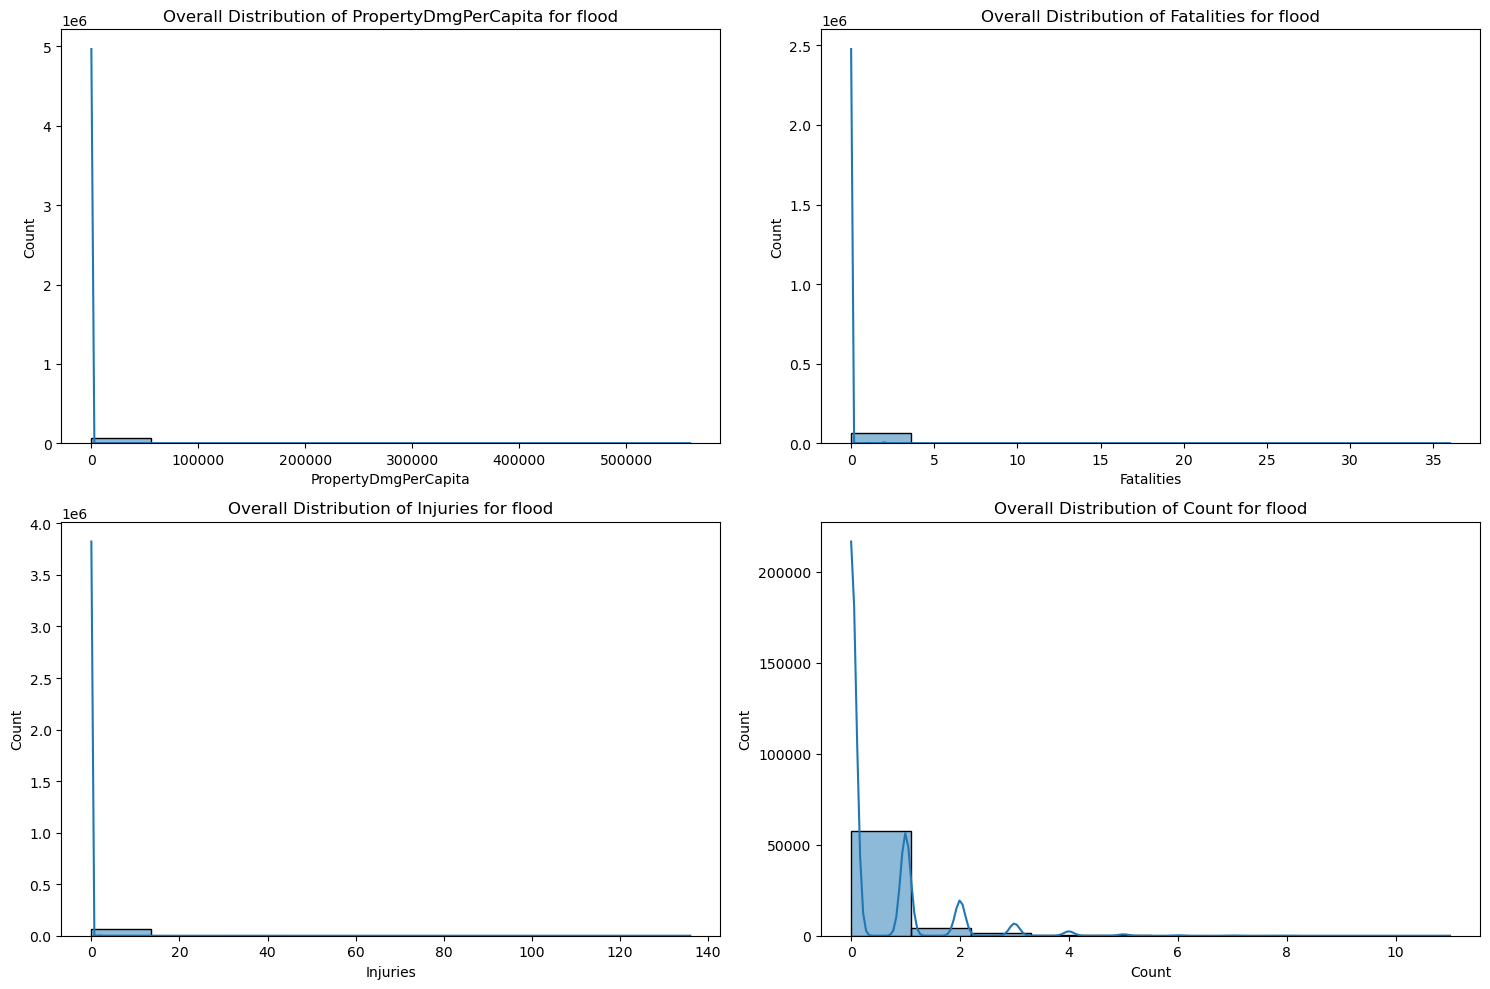

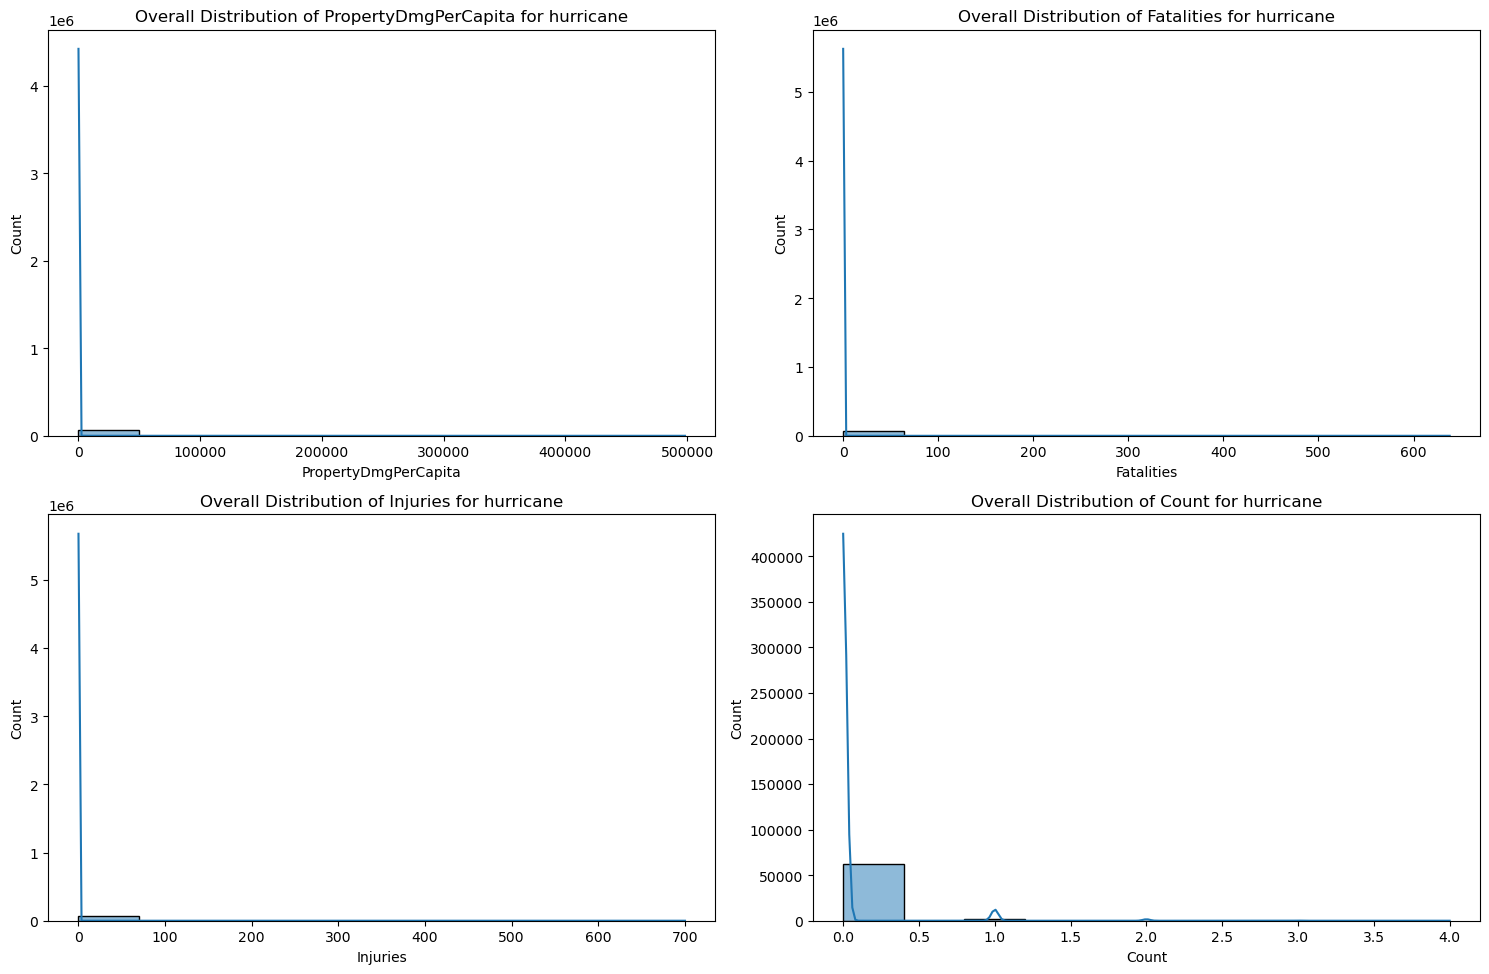

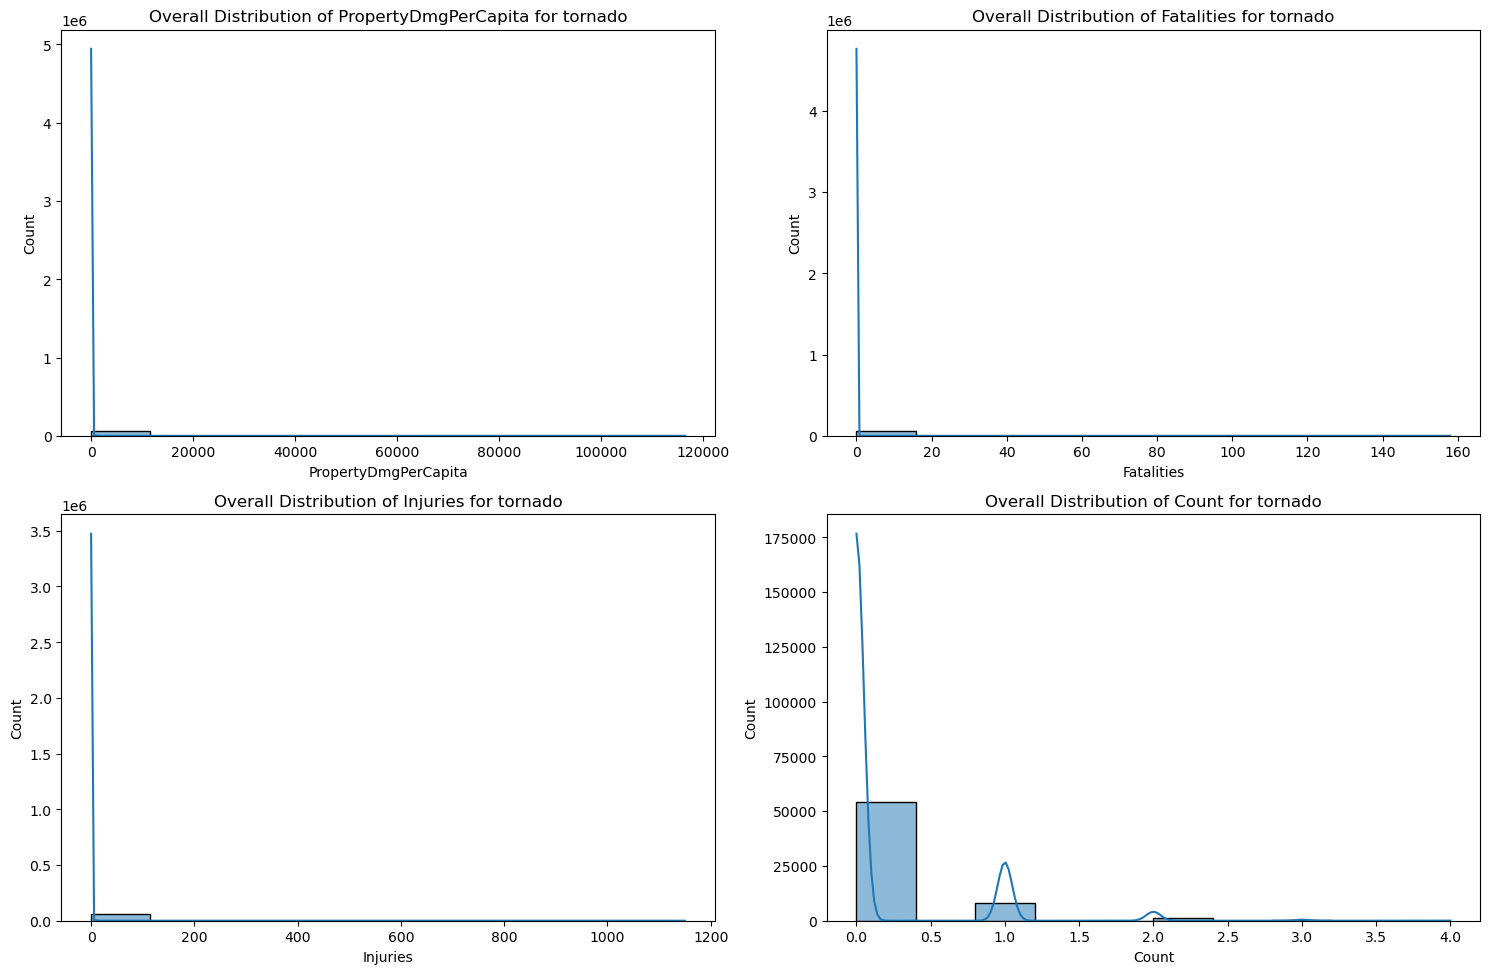

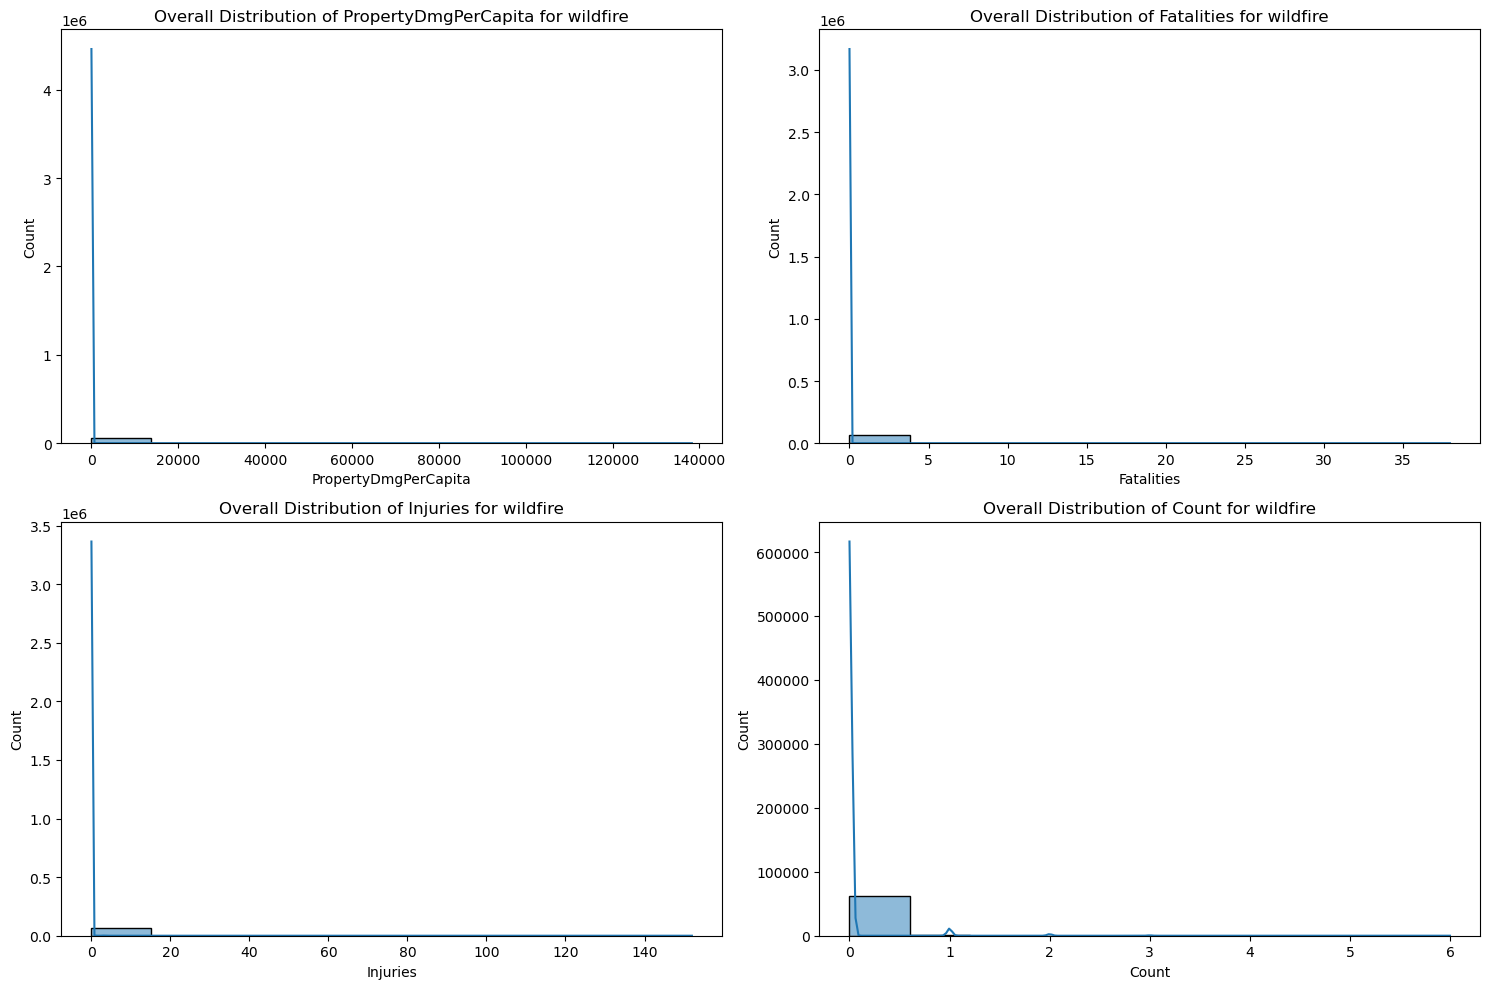

In [25]:
cols_to_plot = ['PropertyDmgPerCapita', 'Fatalities', 'Injuries', 'Count']
disaster_list = [df_year_nmr_flood,df_year_nmr_hurricane,df_year_nmr_tornado,df_year_nmr_wildfire]
name_list = ["flood","hurricane","tornado","wildfire"]
for i in range(len(disaster_list)):
    plt.figure(figsize=(15, 10))
    for j, col in enumerate(cols_to_plot):
        plt.subplot(2, 2, j + 1)
        sns.histplot(data=disaster_list[i], x=col, kde=True, bins=10)
        plt.title(f'Overall Distribution of {col} for {name_list[i]}')
    plt.tight_layout()
    plt.show()


### Original Distribution histogram (No transformation, 50 bins)


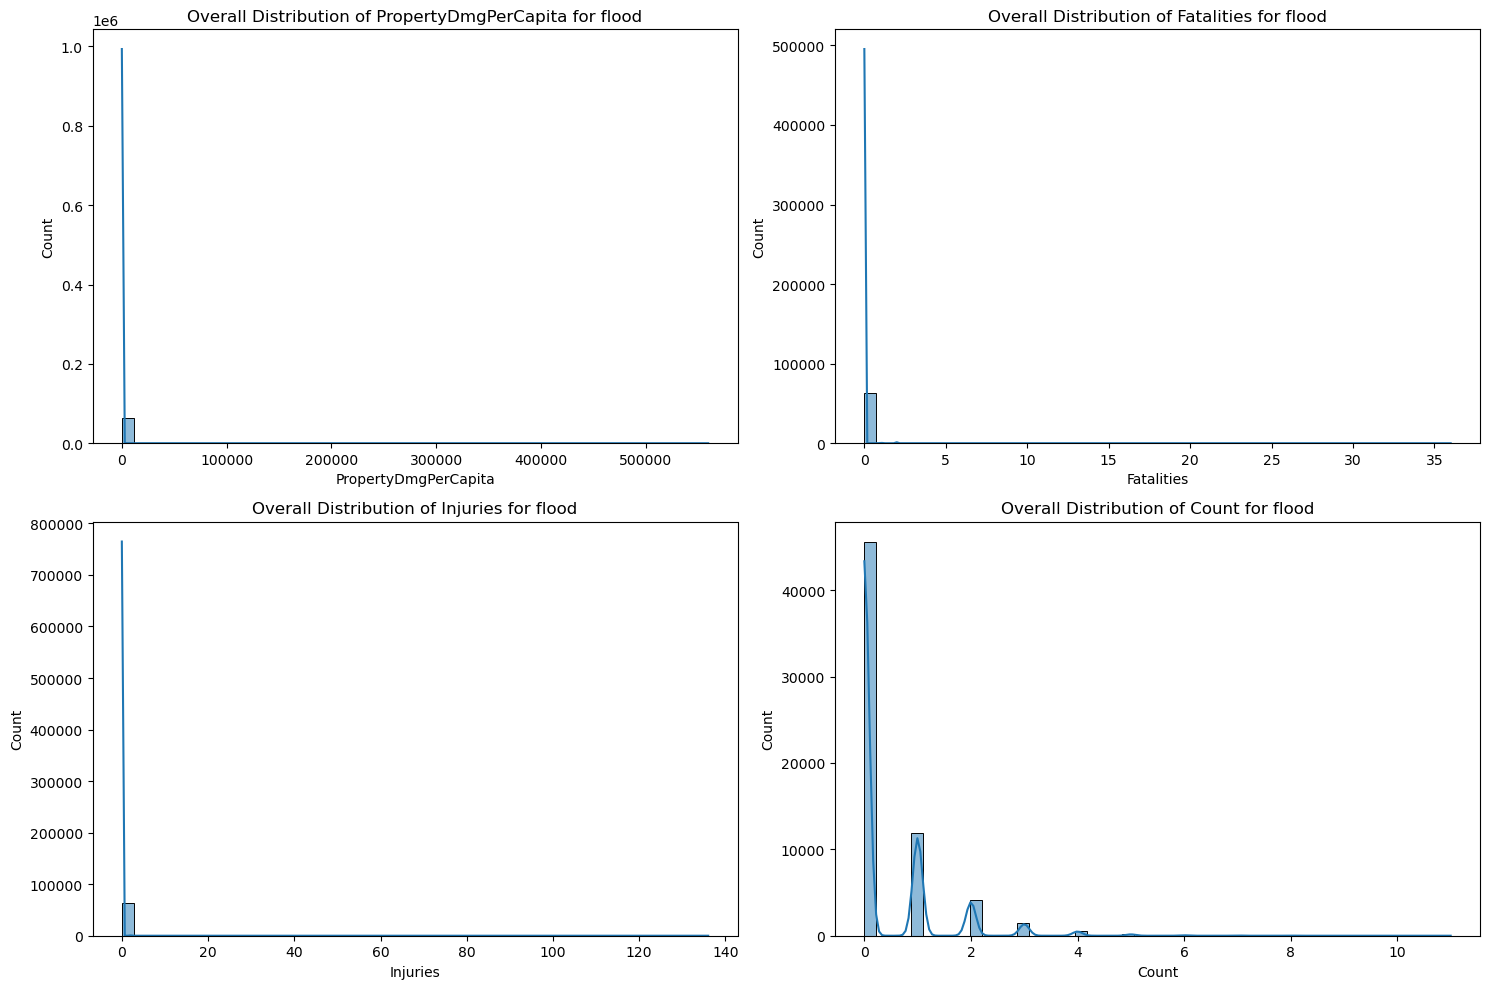

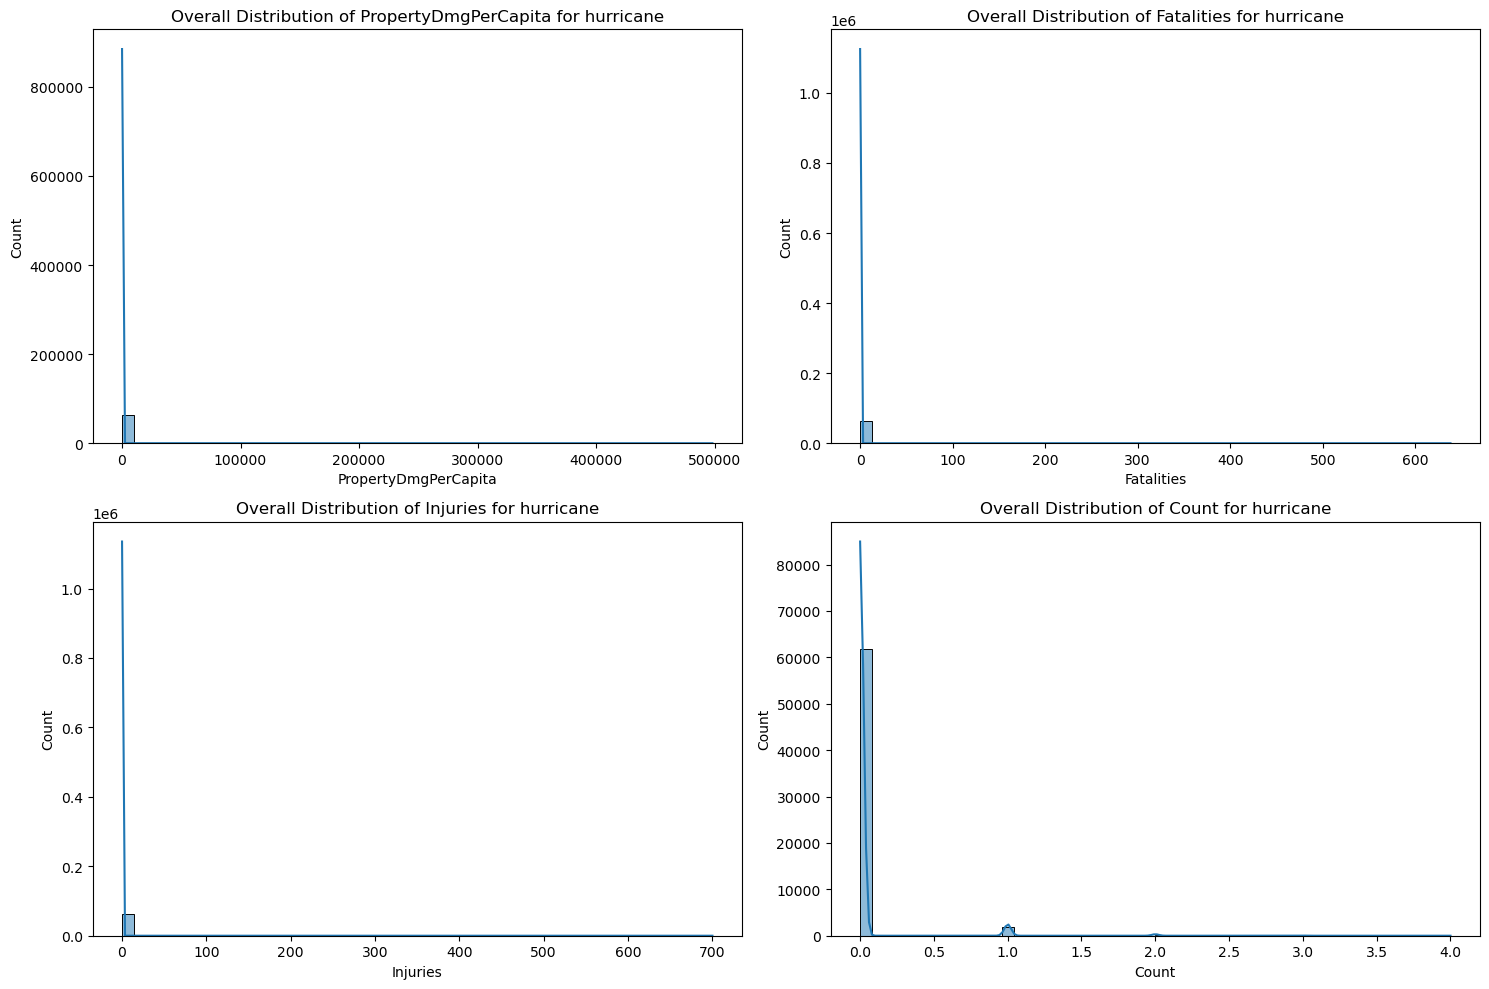

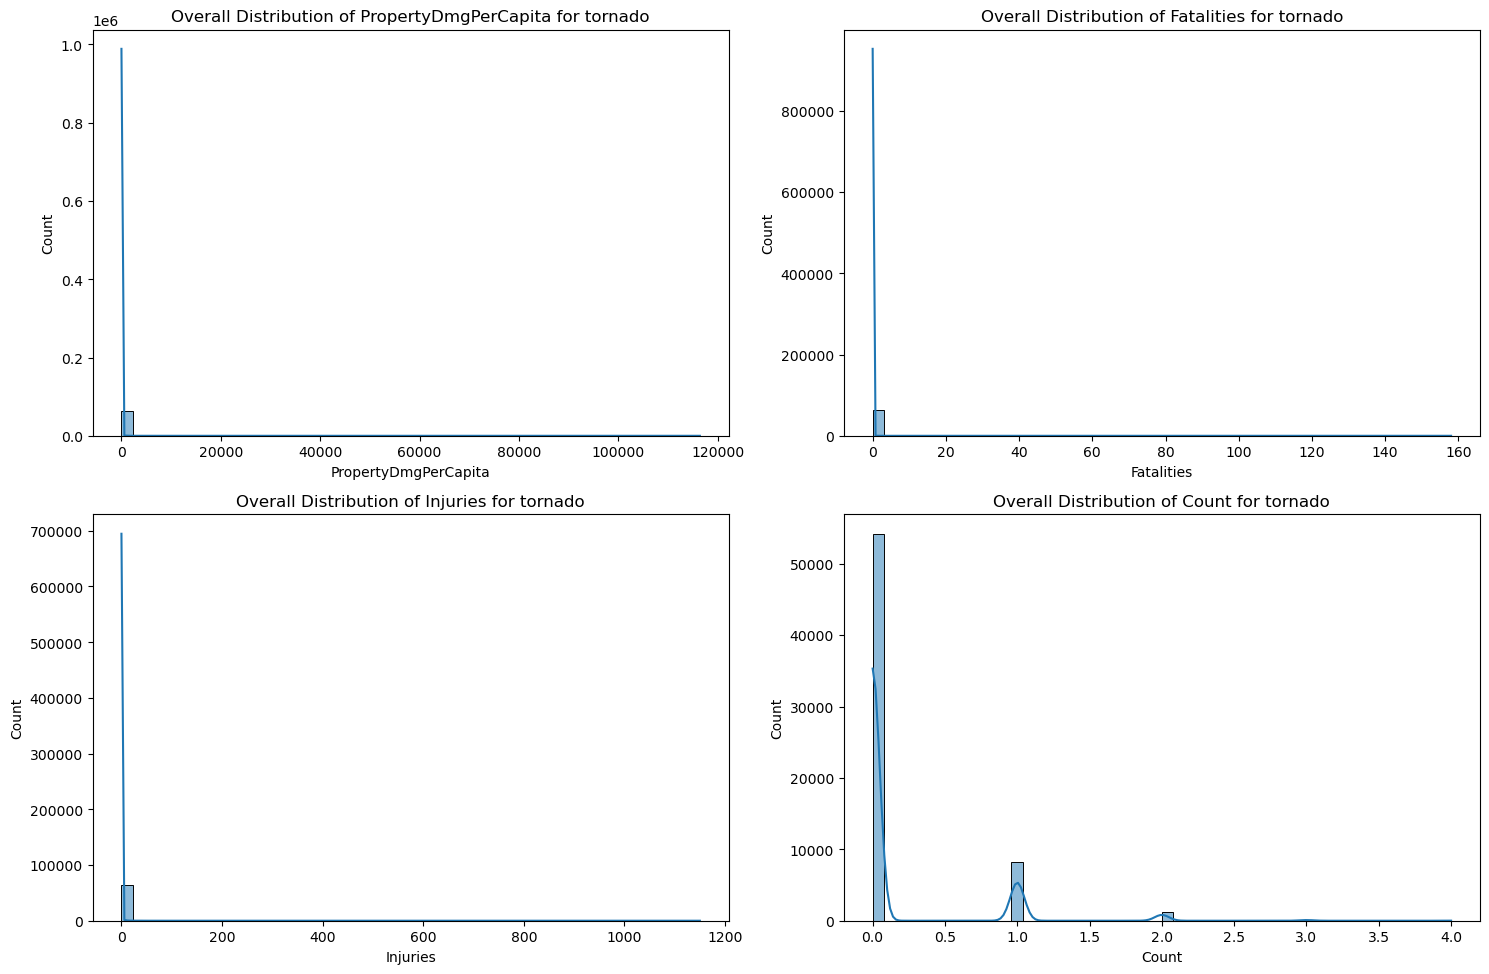

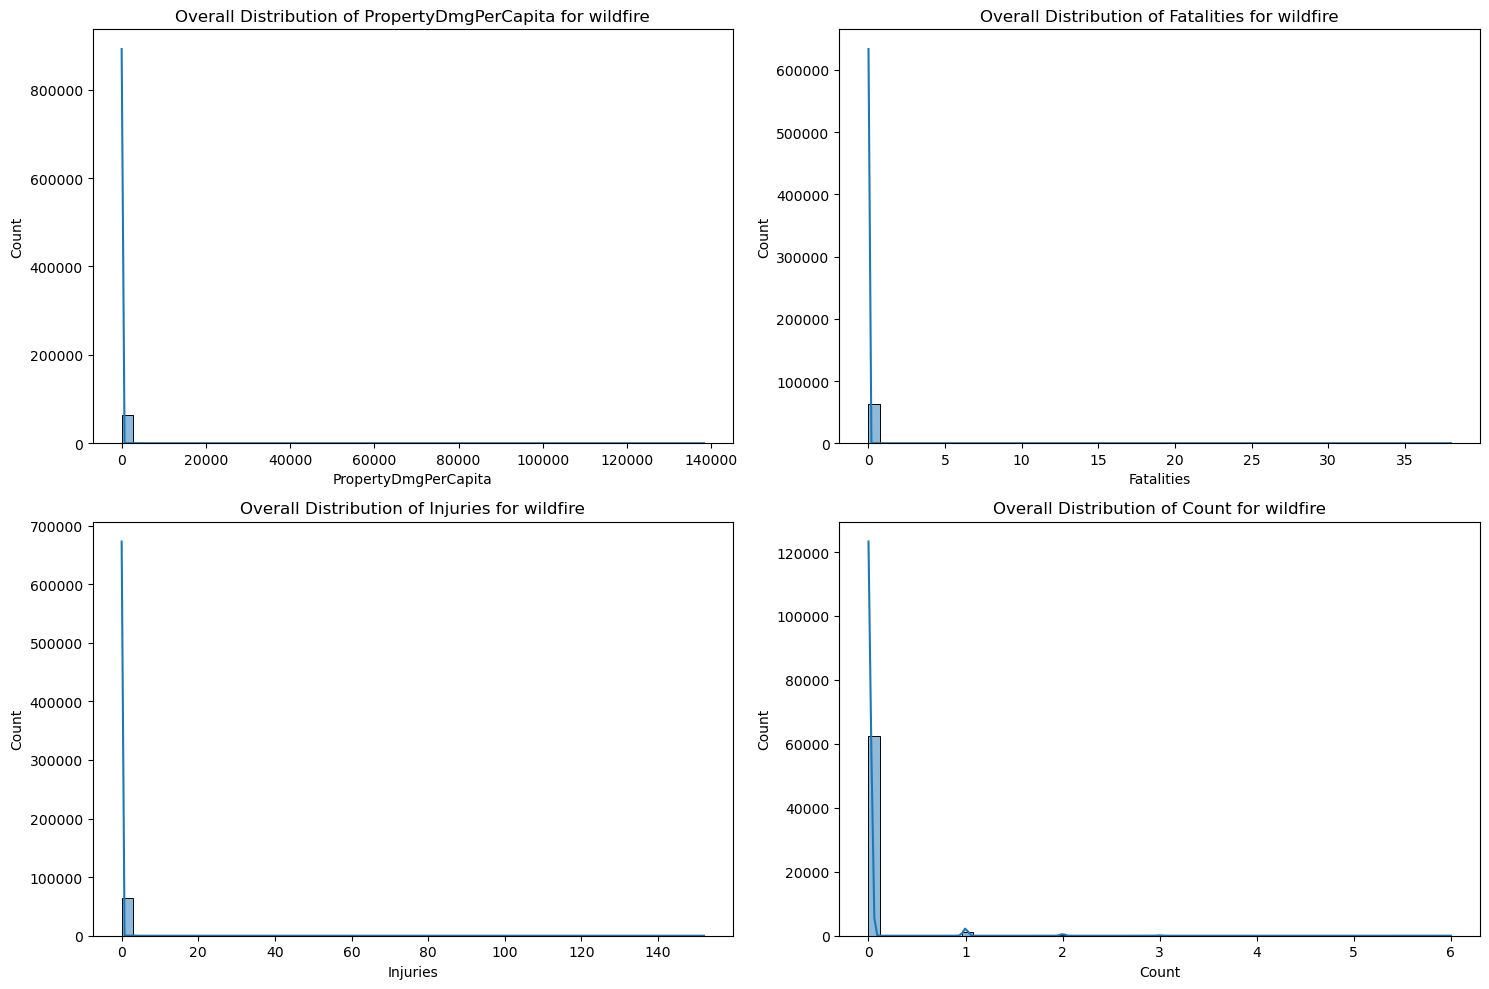

In [26]:
cols_to_plot = ['PropertyDmgPerCapita', 'Fatalities', 'Injuries', 'Count']
disaster_list = [df_year_nmr_flood,df_year_nmr_hurricane,df_year_nmr_tornado,df_year_nmr_wildfire]
name_list = ["flood","hurricane","tornado","wildfire"]
for i in range(len(disaster_list)):
    plt.figure(figsize=(15, 10))
    for j, col in enumerate(cols_to_plot):
        plt.subplot(2, 2, j + 1)
        sns.histplot(data=disaster_list[i], x=col, kde=True, bins=50)
        plt.title(f'Overall Distribution of {col} for {name_list[i]}')
    plt.tight_layout()
    plt.show()


### Log transformation for damage, fatalities, injuries, and count

In [27]:
df_year_nmr_flood['NMR_trans'] = np.cbrt(df_year_nmr_flood['NMR'])
df_year_nmr_flood['Dmg_log'] = np.log1p(df_year_nmr_flood['PropertyDmgPerCapita'])
df_year_nmr_flood['Fatalities_log'] = np.log1p(df_year_nmr_flood['Fatalities'])
df_year_nmr_flood['Injuries_log'] = np.log1p(df_year_nmr_flood['Injuries'])
df_year_nmr_flood['Count_log'] = np.log1p(df_year_nmr_flood['Count'])
df_year_nmr_flood['NMR_trans1'] = np.log1p(df_year_nmr_flood['NMR'])
df_year_nmr_hurricane['NMR_trans'] = np.cbrt(df_year_nmr_hurricane['NMR'])
df_year_nmr_hurricane['Dmg_log'] = np.log1p(df_year_nmr_hurricane['PropertyDmgPerCapita'])
df_year_nmr_hurricane['Fatalities_log'] = np.log1p(df_year_nmr_hurricane['Fatalities'])
df_year_nmr_hurricane['Injuries_log'] = np.log1p(df_year_nmr_hurricane['Injuries'])
df_year_nmr_hurricane['Count_log'] = np.log1p(df_year_nmr_hurricane['Count'])
df_year_nmr_hurricane['NMR_trans1'] = np.log1p(df_year_nmr_hurricane['NMR'])
df_year_nmr_tornado['NMR_trans'] = np.cbrt(df_year_nmr_tornado['NMR'])
df_year_nmr_tornado['Dmg_log'] = np.log1p(df_year_nmr_tornado['PropertyDmgPerCapita'])
df_year_nmr_tornado['Fatalities_log'] = np.log1p(df_year_nmr_tornado['Fatalities'])
df_year_nmr_tornado['Injuries_log'] = np.log1p(df_year_nmr_tornado['Injuries'])
df_year_nmr_tornado['Count_log'] = np.log1p(df_year_nmr_tornado['Count'])
df_year_nmr_tornado['NMR_trans1'] = np.log1p(df_year_nmr_tornado['NMR'])
df_year_nmr_wildfire['NMR_trans'] = np.cbrt(df_year_nmr_wildfire['NMR'])
df_year_nmr_wildfire['Dmg_log'] = np.log1p(df_year_nmr_wildfire['PropertyDmgPerCapita'])
df_year_nmr_wildfire['Fatalities_log'] = np.log1p(df_year_nmr_wildfire['Fatalities'])
df_year_nmr_wildfire['Injuries_log'] = np.log1p(df_year_nmr_wildfire['Injuries'])
df_year_nmr_wildfire['Count_log'] = np.log1p(df_year_nmr_wildfire['Count'])
df_year_nmr_wildfire['NMR_trans1'] = np.log1p(df_year_nmr_wildfire['NMR'])

C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Distribution after transformation (10bins)

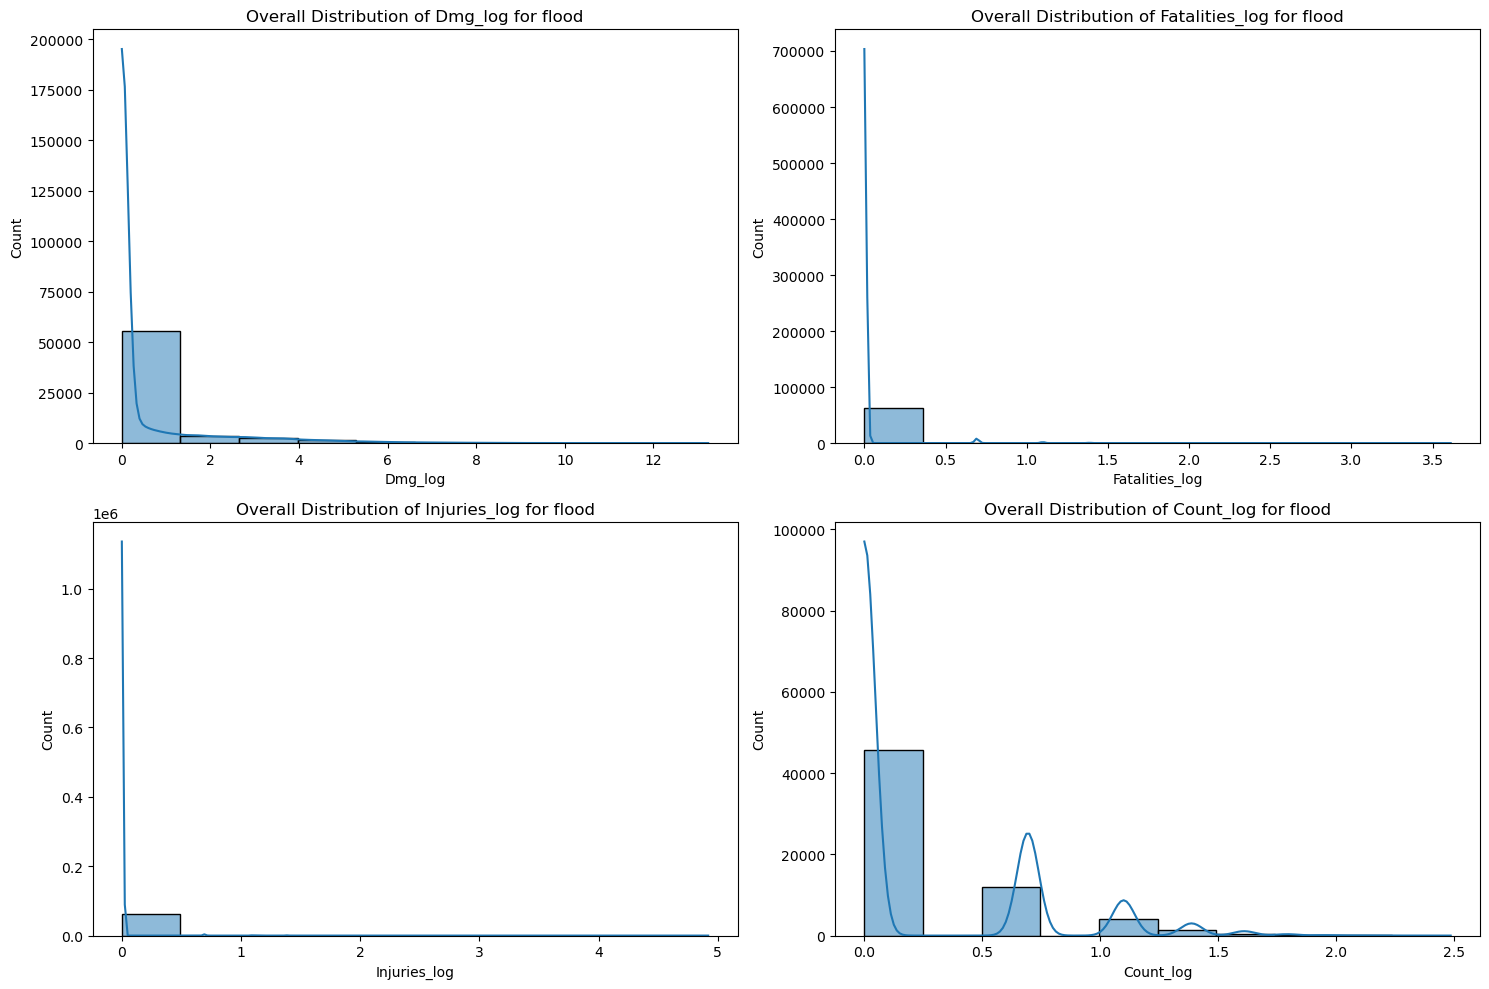

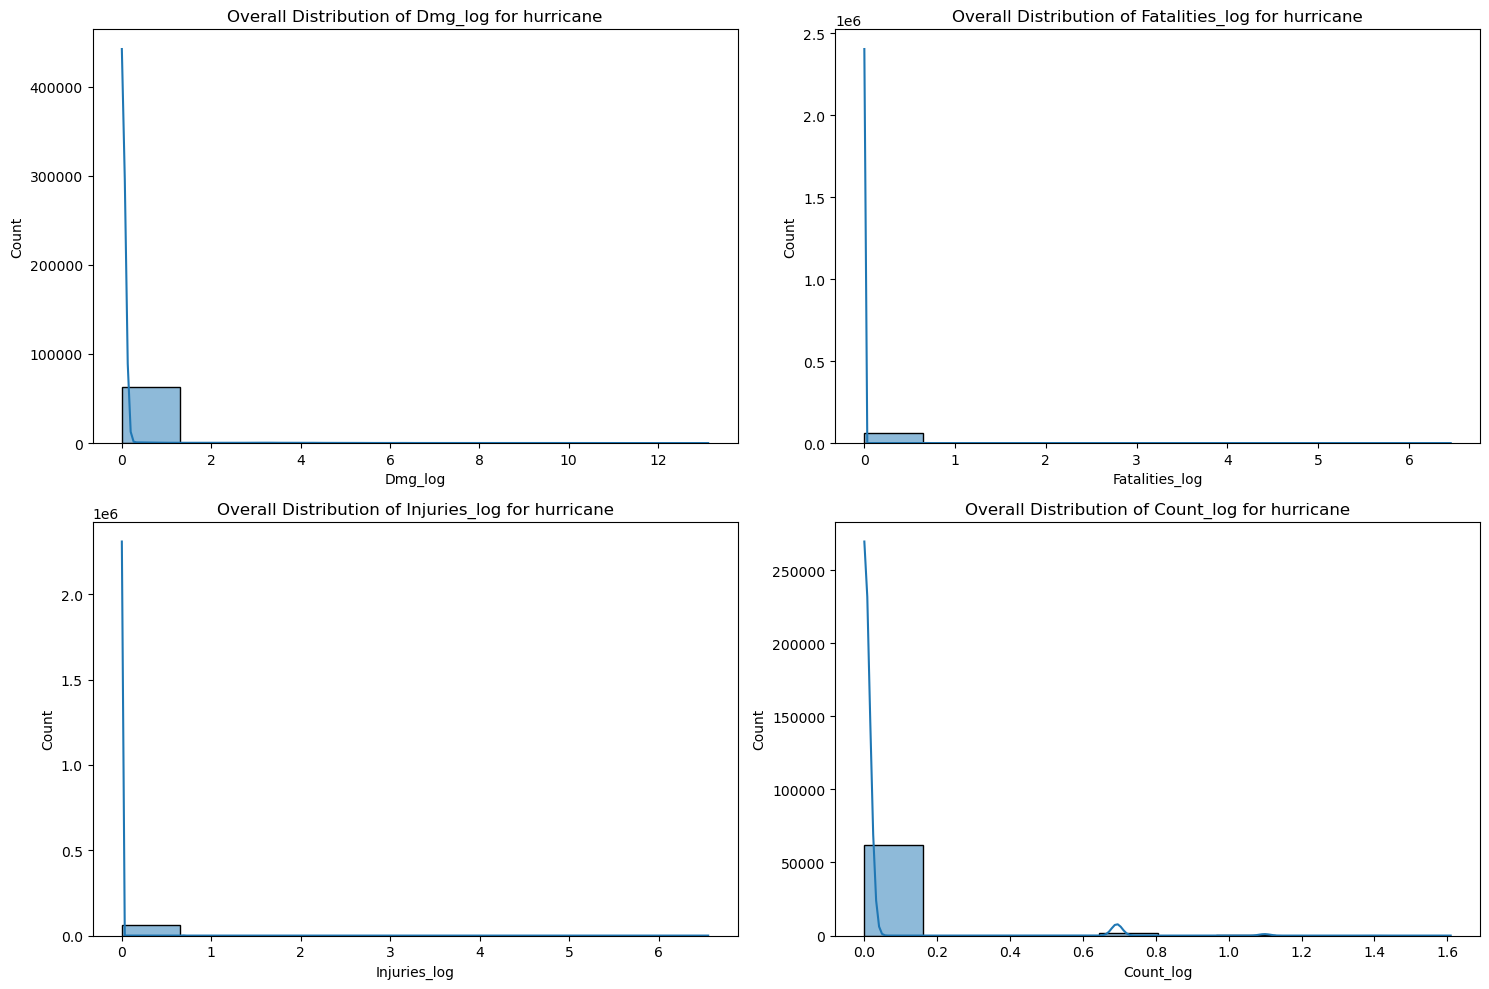

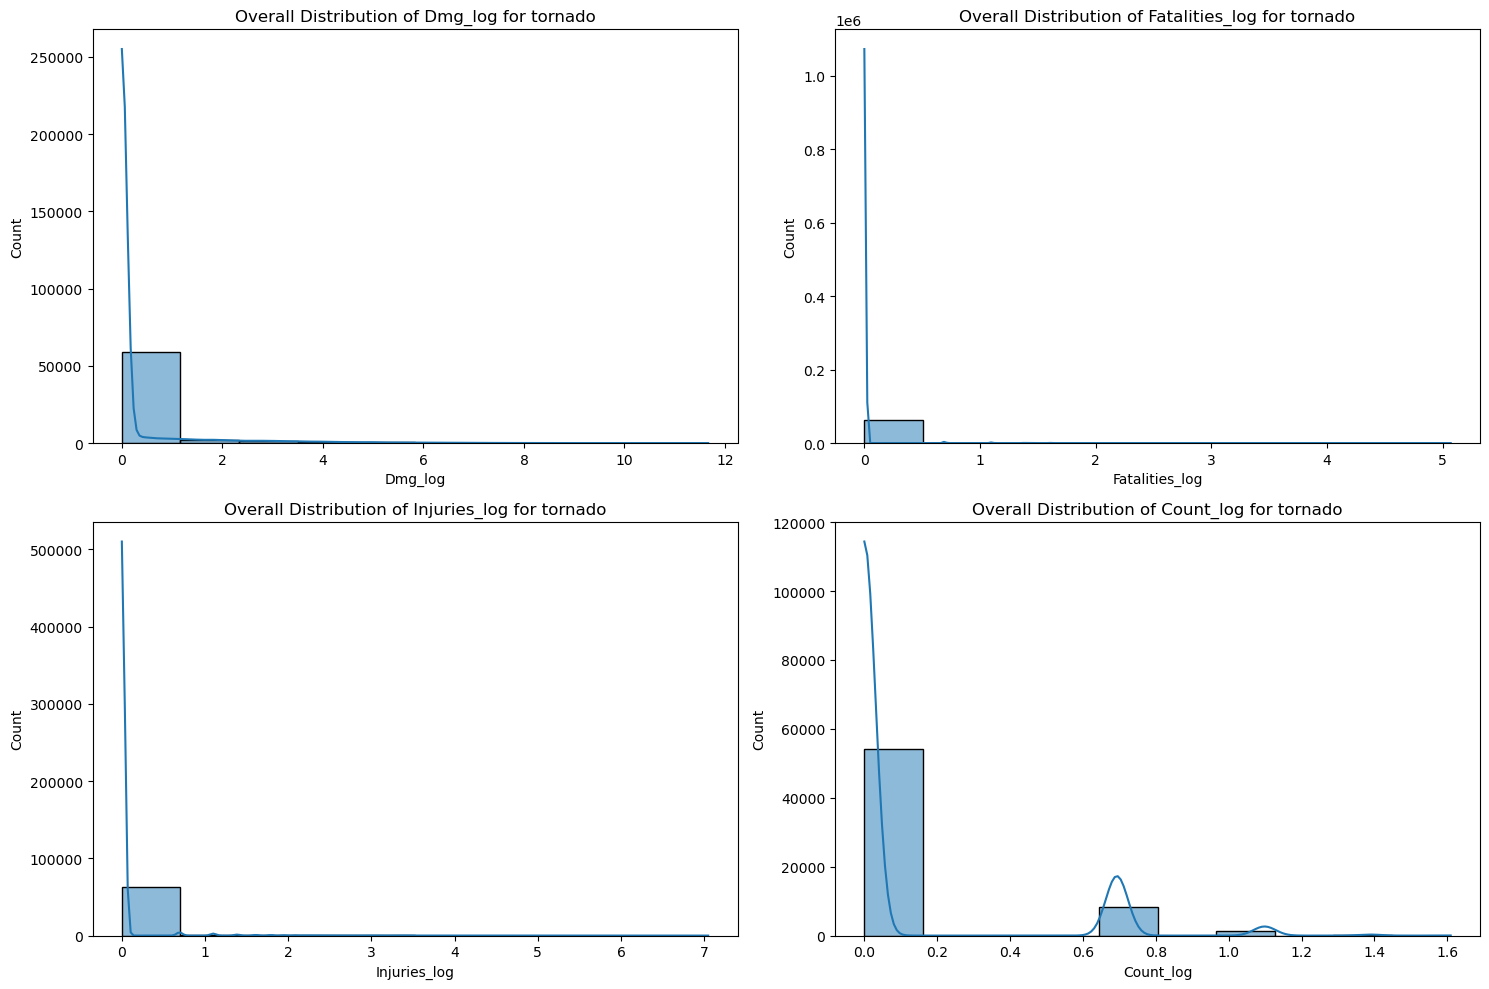

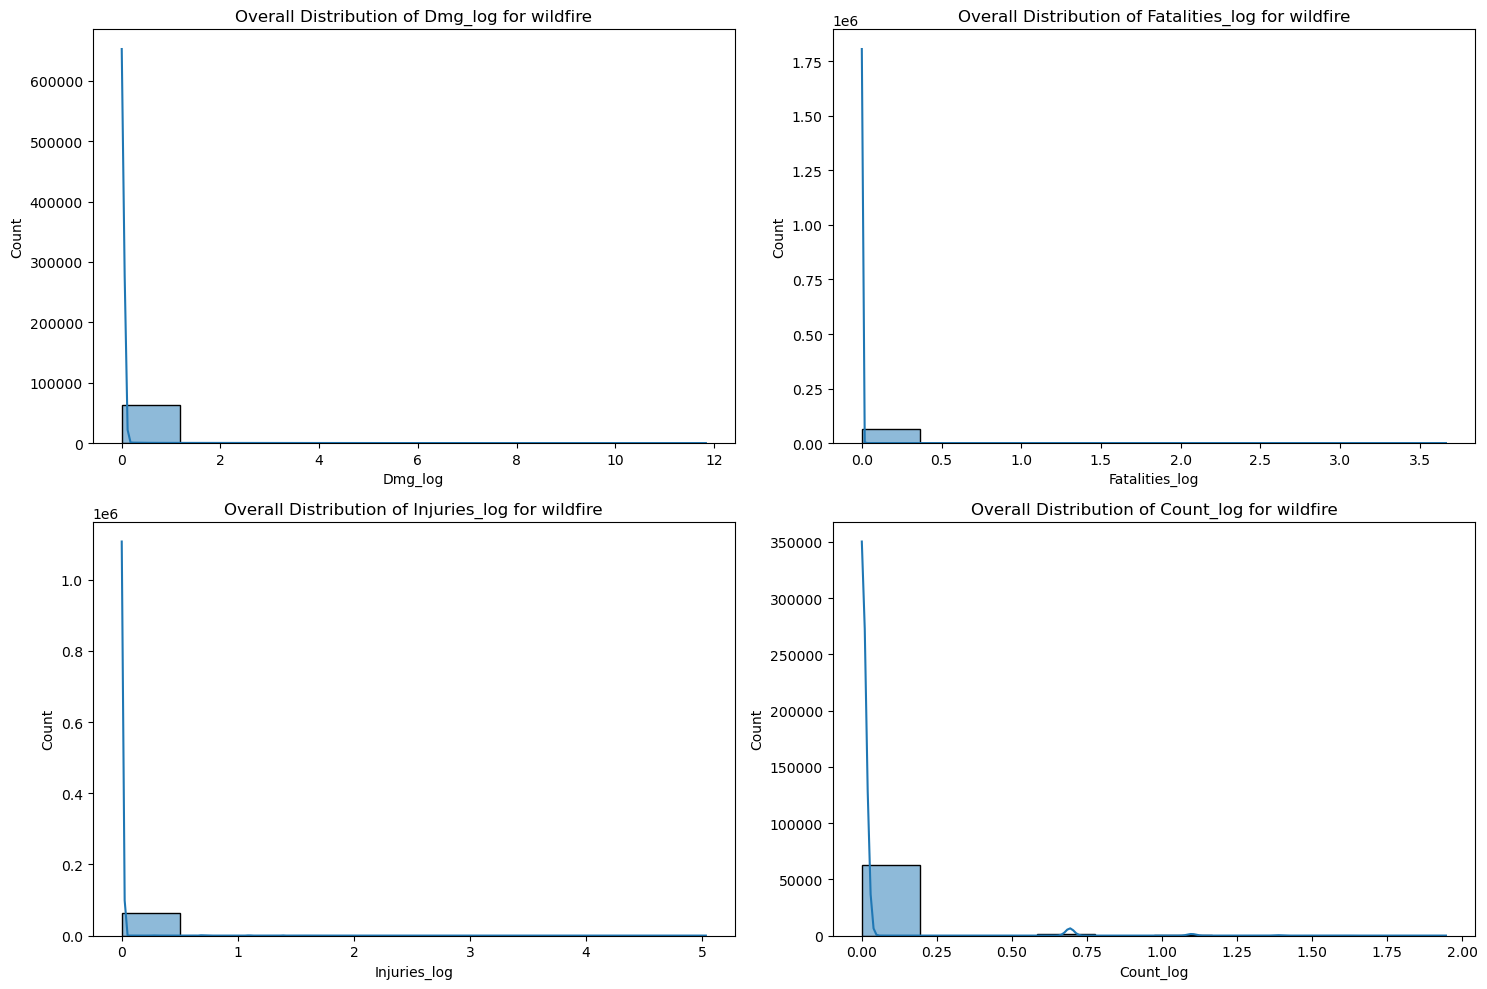

In [28]:
cols_to_plot = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
disaster_list = [df_year_nmr_flood,df_year_nmr_hurricane,df_year_nmr_tornado,df_year_nmr_wildfire]
name_list = ["flood","hurricane","tornado","wildfire"]
for i in range(len(disaster_list)):
    plt.figure(figsize=(15, 10))
    for j, col in enumerate(cols_to_plot):
        plt.subplot(2, 2, j + 1)
        sns.histplot(data=disaster_list[i], x=col, kde=True, bins=10)
        plt.title(f'Overall Distribution of {col} for {name_list[i]}')
    plt.tight_layout()
    plt.show()


## Distribution after transformation (50bins)

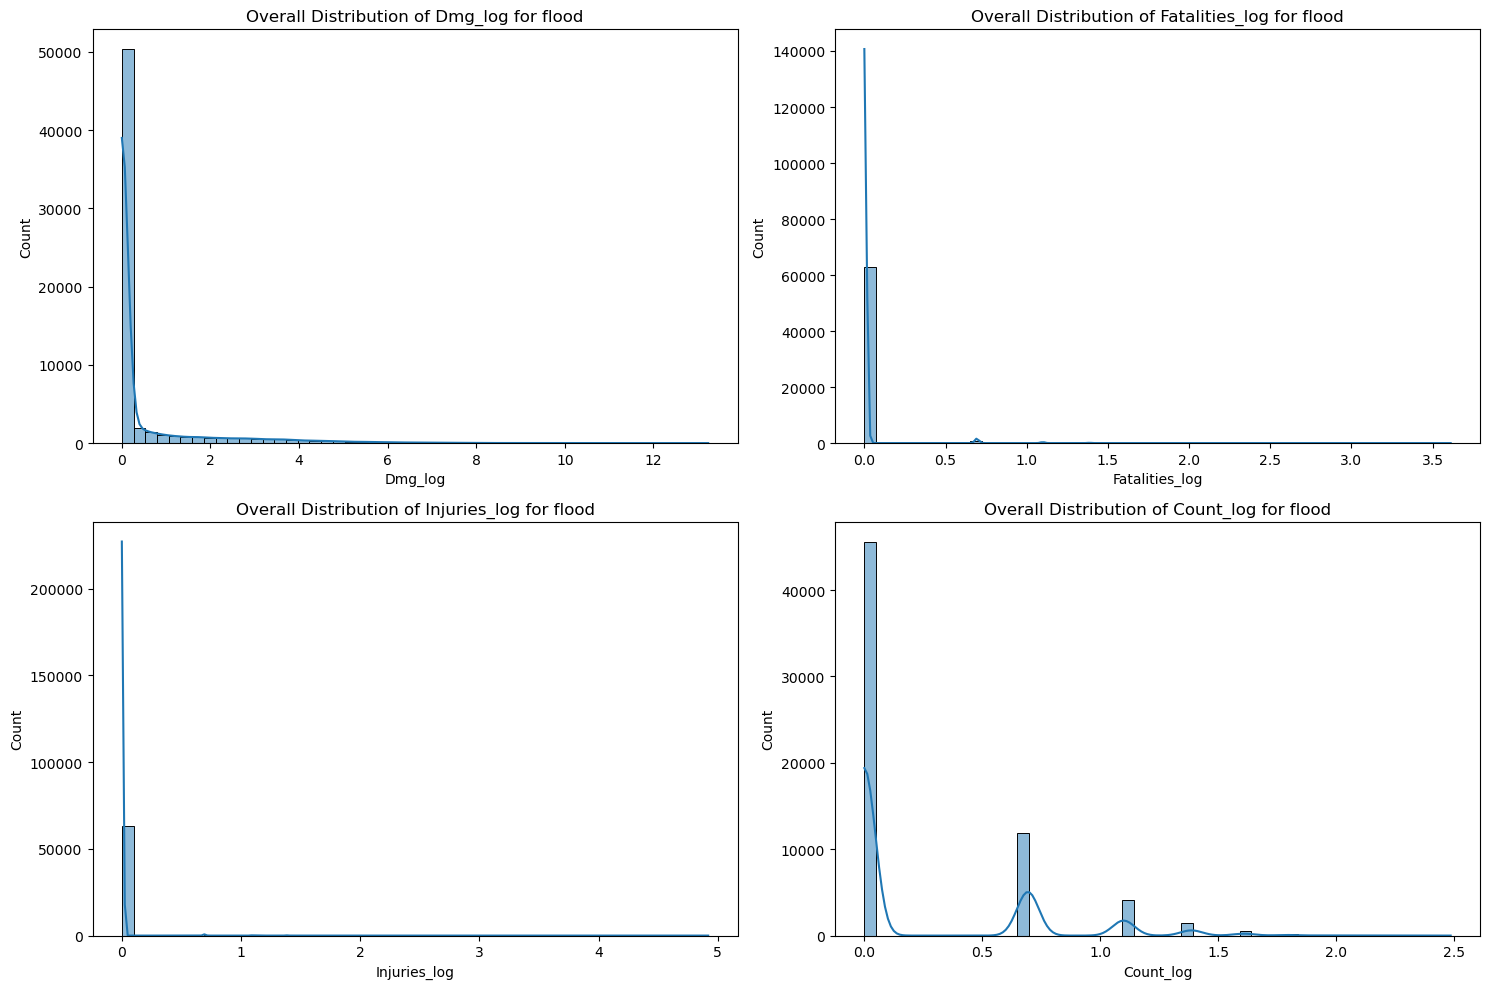

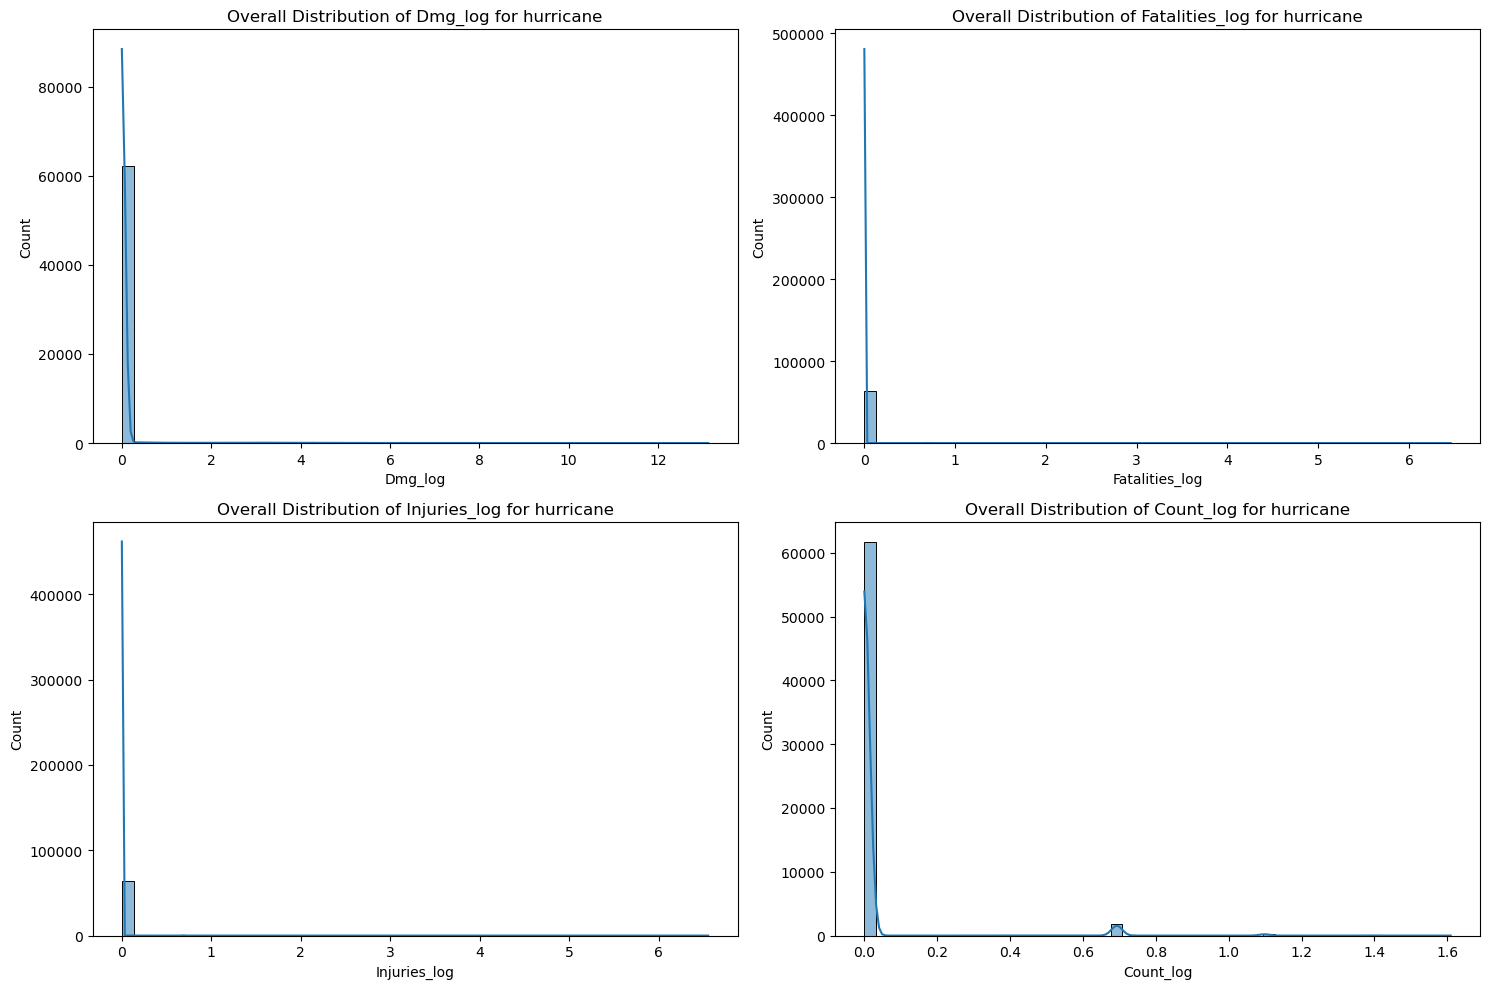

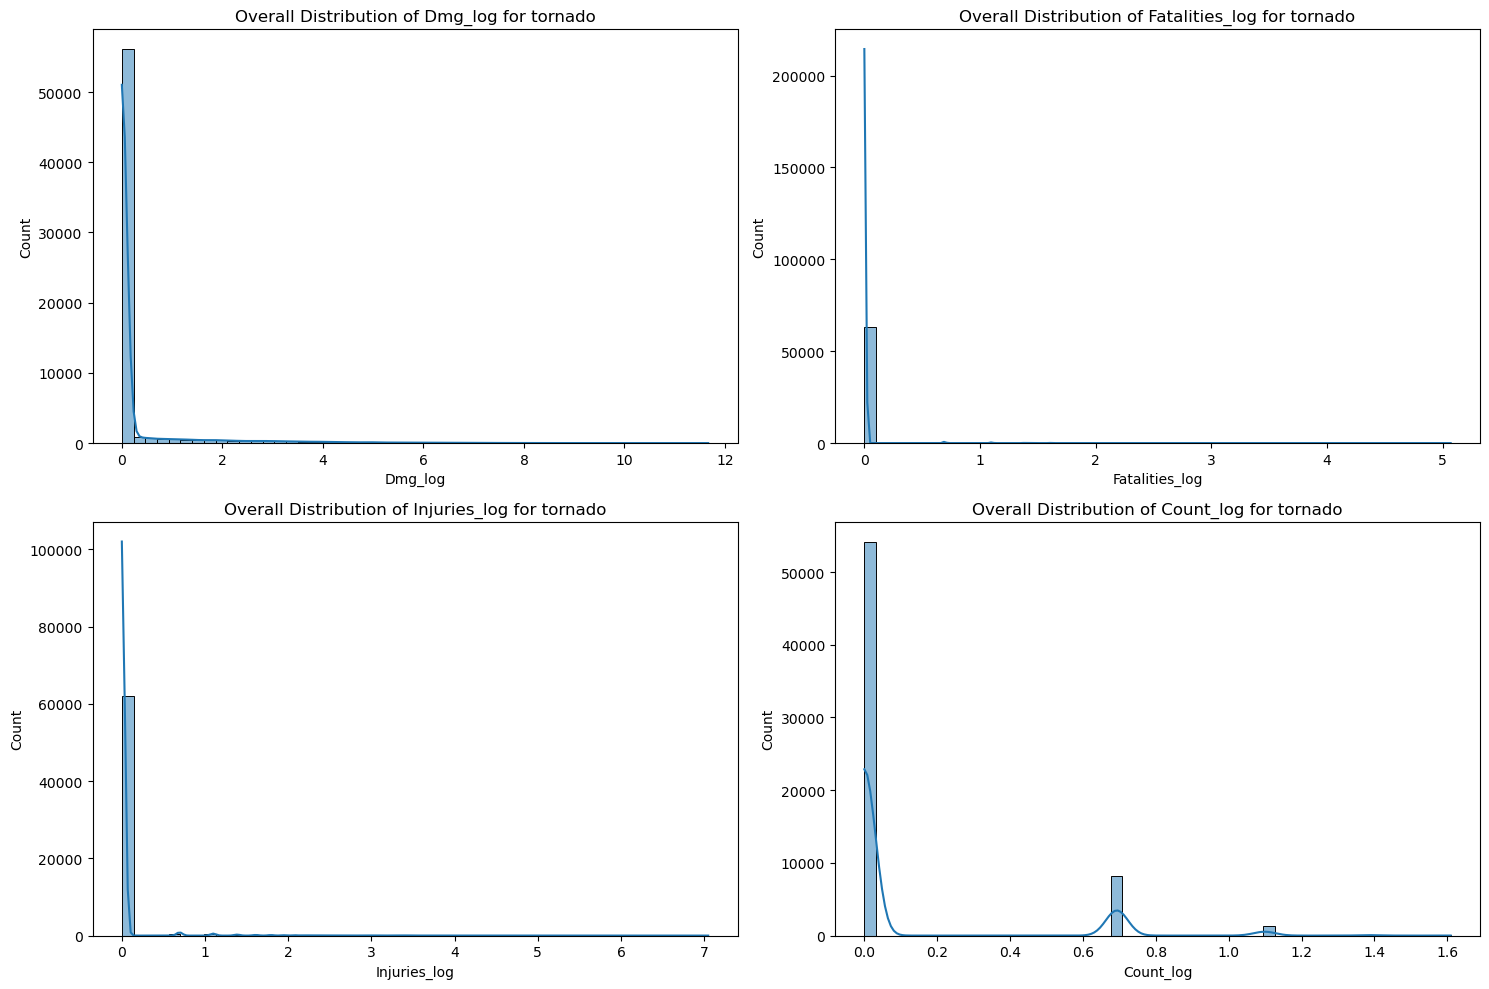

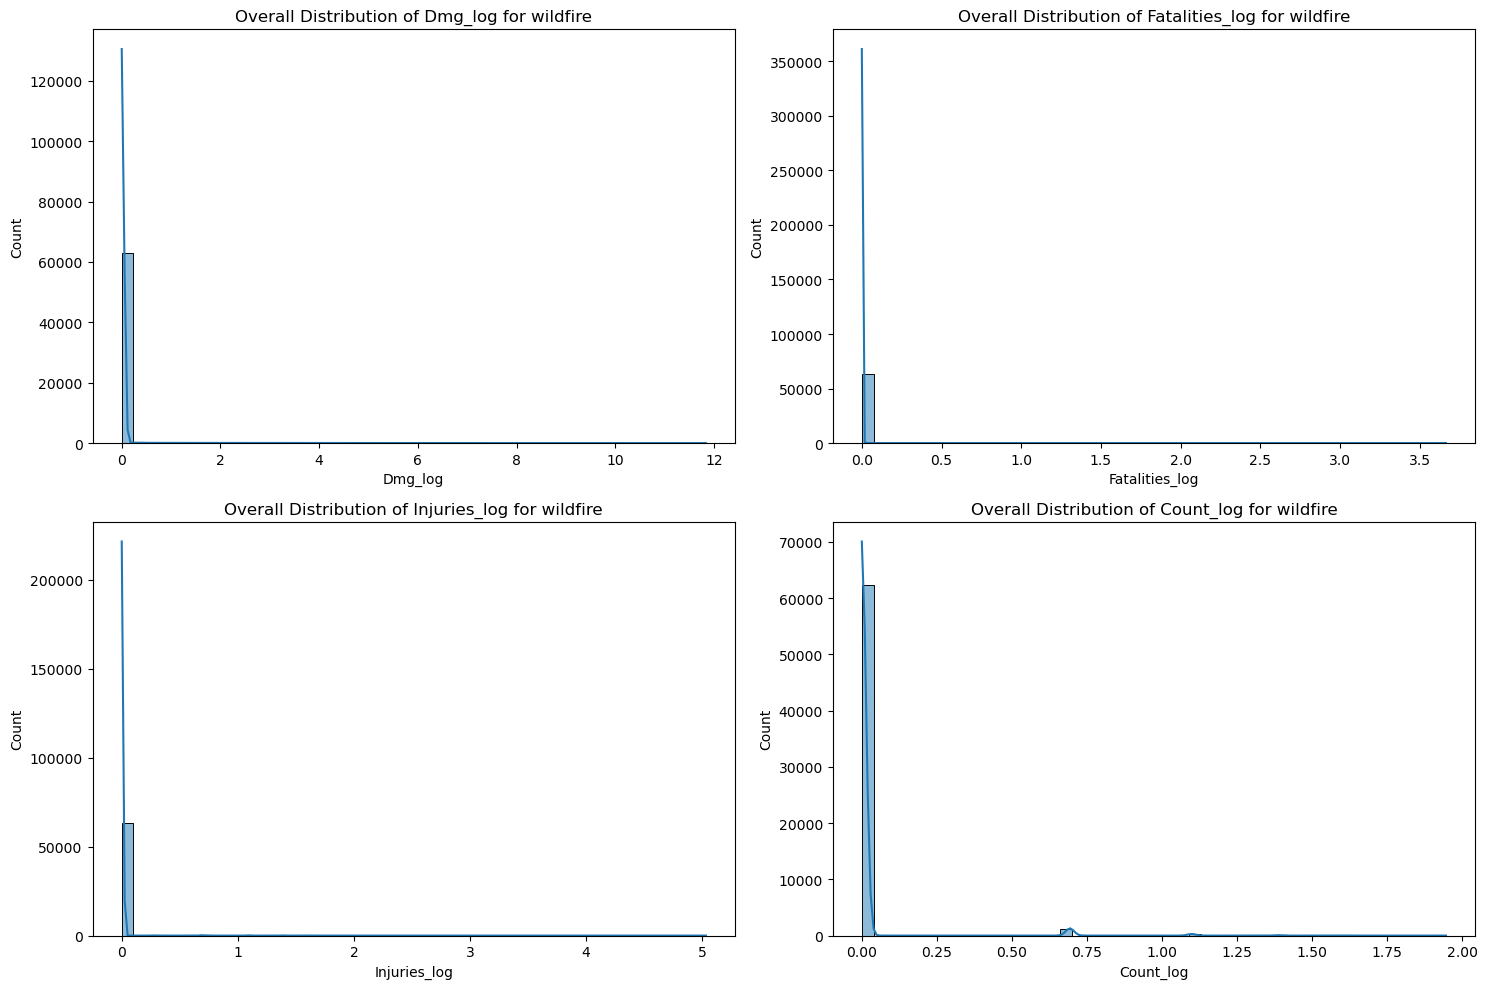

In [29]:
cols_to_plot = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
disaster_list = [df_year_nmr_flood,df_year_nmr_hurricane,df_year_nmr_tornado,df_year_nmr_wildfire]
name_list = ["flood","hurricane","tornado","wildfire"]
for i in range(len(disaster_list)):
    plt.figure(figsize=(15, 10))
    for j, col in enumerate(cols_to_plot):
        plt.subplot(2, 2, j + 1)
        sns.histplot(data=disaster_list[i], x=col, kde=True, bins=50)
        plt.title(f'Overall Distribution of {col} for {name_list[i]}')
    plt.tight_layout()
    plt.show()


### In four disaster dataframe, NMR data is the same. Hence, here I only use the flood data to represent
### (Original distribution, log transformation, and cubic root transformation in 50 bins)

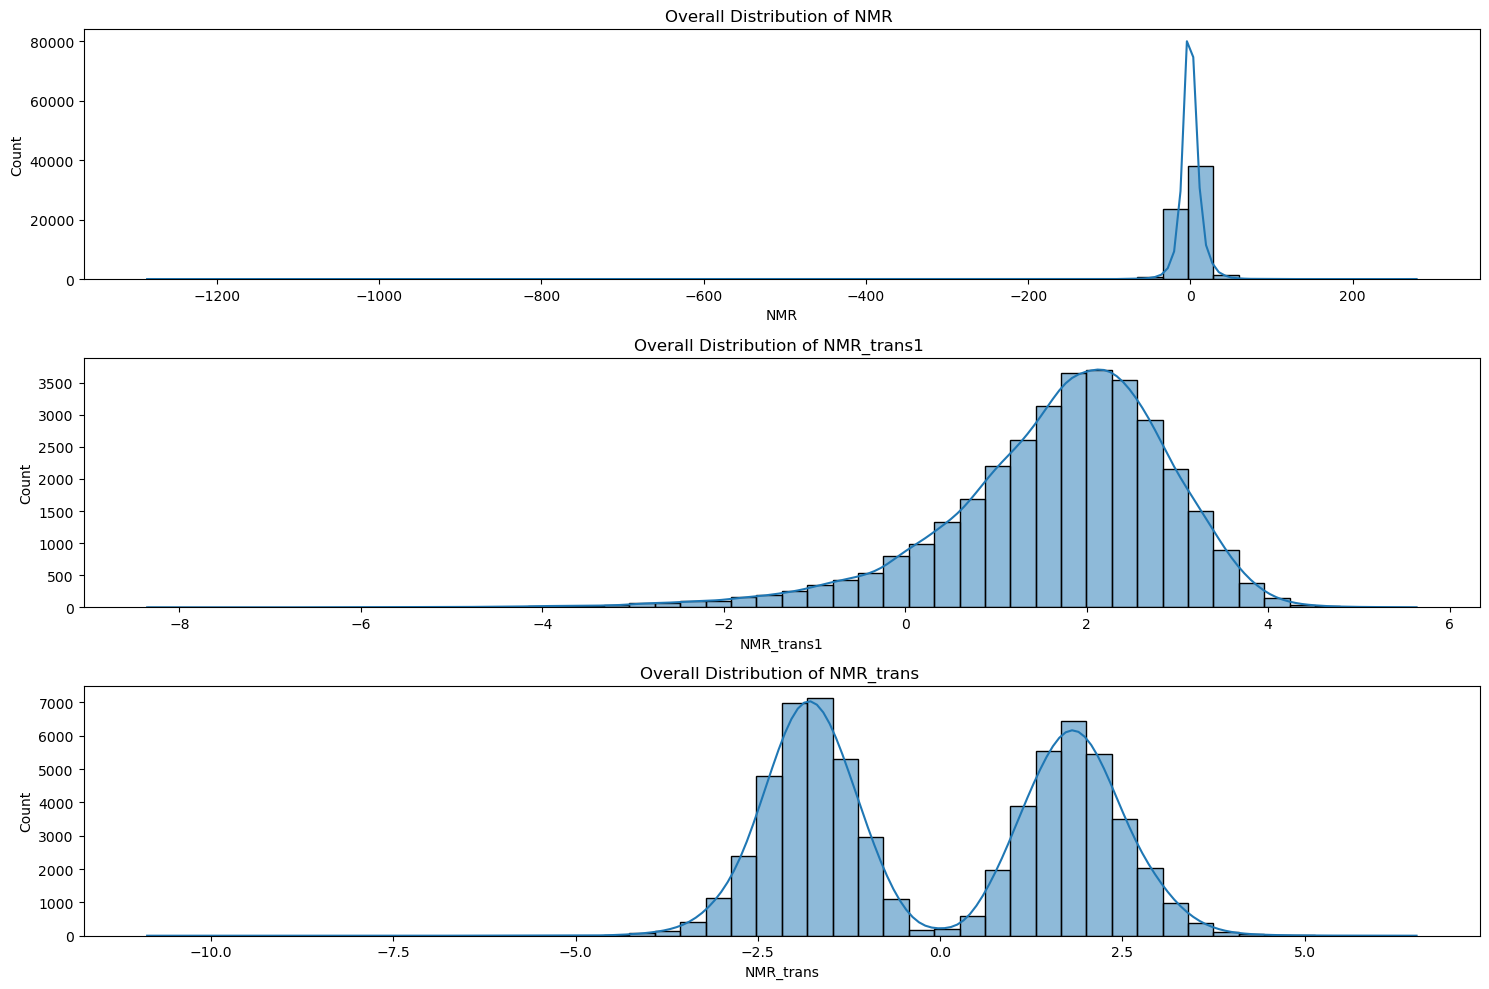

In [30]:
cols_to_plot = ['NMR', 'NMR_trans1', 'NMR_trans']
plt.figure(figsize=(15, 10))
for j, col in enumerate(cols_to_plot):
    plt.subplot(3, 1, j + 1)
    sns.histplot(data=df_year_nmr_flood, x=col, kde=True, bins=50)
    plt.title(f'Overall Distribution of {col} ')
plt.tight_layout()
plt.show()

### In four disaster dataframe, NMR data is the same. Hence, here I only use the flood data to represent
### (Original distribution, log transformation, and cubic root transformation in 20 bins)

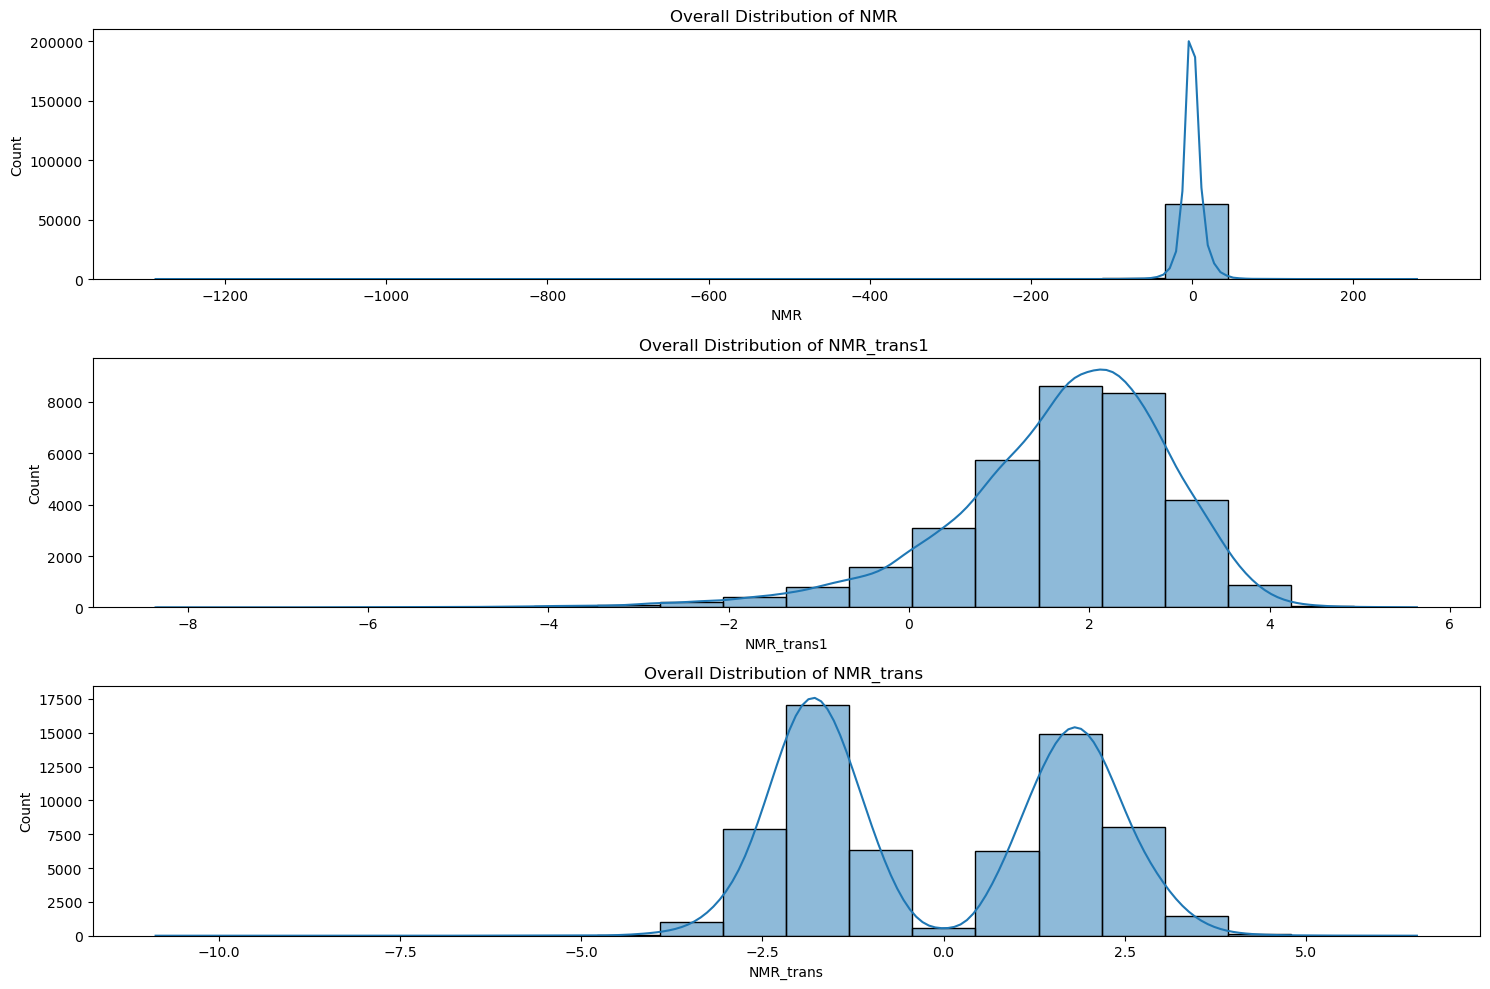

In [31]:
cols_to_plot = ['NMR', 'NMR_trans1', 'NMR_trans']
plt.figure(figsize=(15, 10))
for j, col in enumerate(cols_to_plot):
    plt.subplot(3, 1, j + 1)
    sns.histplot(data=df_year_nmr_flood, x=col, kde=True, bins=20)
    plt.title(f'Overall Distribution of {col} ')
plt.tight_layout()
plt.show()

## Fixed Effect Panel Regression

## Considerations for Entity Effects:
Entity Effects control for all time-invariant differences among the entities. This means any characteristic of an entity (like geographic, demographic, or other inherent traits that do not change over time) that might influence NMR will be controlled for.

Use entity effects if you believe that there are unobserved, constant characteristics within each entity (e.g., a specific county or region) that could affect both the likelihood of disasters and the NMR.

## Considerations for Time Effects:
Time Effects are useful when there are shocks or trends that affect all entities at the same time but may vary from one time period to another. This could include broader economic conditions, policy changes, or environmental shifts relevant to your study.

Include time effects if you think there are nationwide or widespread events occurring at specific times that would similarly affect all entities (all regions or counties in your study).

Scenario Analysis for Disaster and NMR Correlation:
## Entity Effects Only:

Use this model if your primary interest is in how differences between entities (such as different counties) affect the relationship between disasters and NMR, while assuming that all time-specific shocks affect all entities equally.

## Time Effects Only:

This is less common unless your focus is on how changes over time affect all entities in the same way, and there is less interest in the differences between the entities themselves.

## Both Entity and Time Effects: (I used this)

This is often the most comprehensive approach, especially if both the differences between entities and the changes over time are believed to impact the relationship between disasters and NMR.

This model can provide a clearer picture by isolating the effect of disasters on NMR from both entity-specific and time-specific confounders.

## When to Include Time Effects:
Common External Shocks: If your data could be influenced by factors that affect all regions or entities at the same time—such as national economic conditions, major policy changes, or environmental regulations—time effects can help control for these influences, allowing you to isolate the specific impact of the variables of interest like disaster metrics.

Yearly Variations: If there are variations specific to certain years that might affect the dependent variable across all entities, incorporating time effects can provide a more accurate analysis. This is especially relevant if these time-specific factors are not captured by other variables in your model.

Removing Time-Related Confounding: Including time effects can help ensure that the relationships you observe are not confounded by other macro-level changes occurring simultaneously.

## When You Might Not Need Time Effects:
Entity-Specific Focus: If the focus of your study is primarily on differences between entities (e.g., different regions or FIPS codes) rather than on changes over time, or if you believe that time-specific variations are minimal or irrelevant to your study, you may opt not to include time effects.

Limited Data: If your panel data covers only a short time span or the number of time periods is quite limited, adding time effects might consume too many degrees of freedom, leaving less room for the analysis of other more critical variables.

## Example Scenario:
Suppose you are examining how previous disasters impact current NMR, and you suspect that there might be nationwide economic or policy changes affecting NMR across all entities in some years. Including time effects in your model would help control for these widespread impacts, ensuring that the coefficients associated with your disaster variables more accurately reflect the isolated effects of those disasters.

## Flood

In [32]:
# Make sure multi-index is set
df_year_nmr_flood = df_year_nmr_flood.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars
for var in all_vars:
    df_year_nmr_flood[f'{var}_lag1'] = df_year_nmr_flood.groupby(level=0)[var].shift(1)
    df_year_nmr_flood[f'{var}_lag2'] = df_year_nmr_flood.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result

# Run current year model
exog_vars_current = log_vars 
fe_current = run_panel_regression(df_year_nmr_flood, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars]
fe_lag1 = run_panel_regression(df_year_nmr_flood, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars]
fe_lag2 = run_panel_regression(df_year_nmr_flood, exog_vars_lag2, "Lag 2 Years")

# Hausman Test
model_df = df_year_nmr_flood[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))



📘 Fixed Effects Results – Current Year
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0012
Estimator:                   PanelOLS   R-squared (Between):              0.0055
No. Observations:               63800   R-squared (Within):               0.0011
Date:                Fri, Apr 18 2025   R-squared (Overall):              0.0025
Time:                        03:48:28   Log-likelihood                -2.497e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      17.857
Entities:                        3190   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                 F(4,60587)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):        

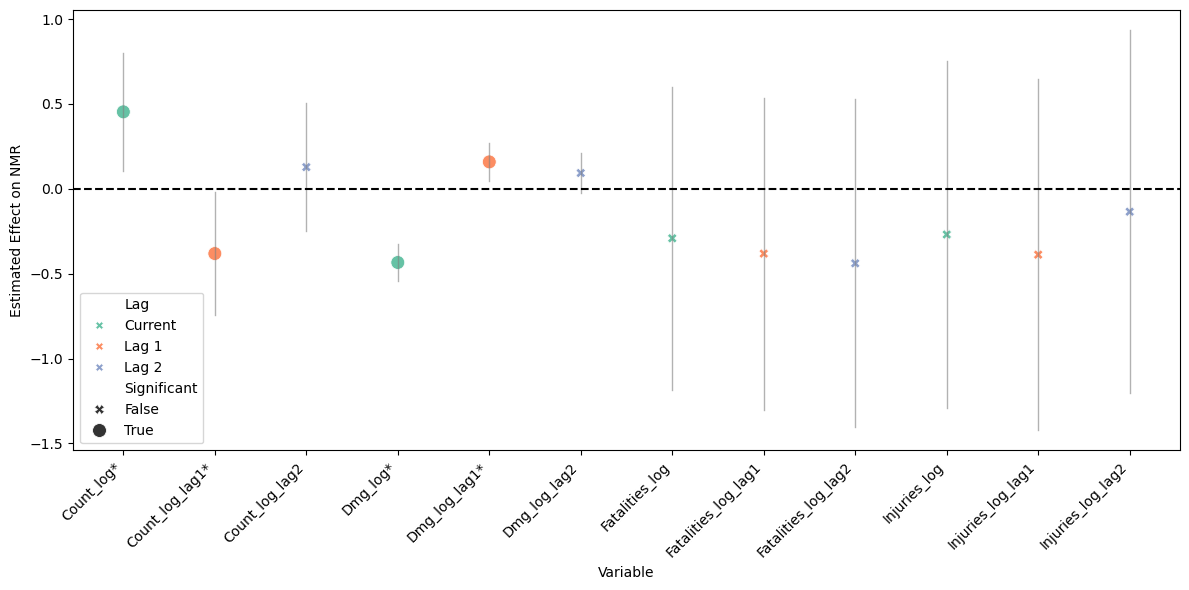

In [33]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df_flood = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df_flood['Significant'] = (coef_df_flood['CI_lower'] * coef_df_flood['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df_flood['Label'] = coef_df_flood.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df_flood['Label'] = pd.Categorical(coef_df_flood['Label'], categories=sorted(coef_df_flood['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df_flood,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df_flood.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
# plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,0.4538,0.0107,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,-0.3814,0.0381,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,0.1280,0.5043
3,Dmg_log,-0.4341,0.0000,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,0.1589,0.0061,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,0.0933,0.1240
6,Fatalities_log,-0.2914,0.5223,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,-0.3817,0.4155,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,-0.4390,0.3734
9,Injuries_log,-0.2691,0.6055,NaN,NaN,NaN,NaN


## Hurricane

In [35]:
# Make sure multi-index is set
df_year_nmr_hurricane = df_year_nmr_hurricane.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars 
for var in all_vars:
    df_year_nmr_hurricane[f'{var}_lag1'] = df_year_nmr_hurricane.groupby(level=0)[var].shift(1)
    df_year_nmr_hurricane[f'{var}_lag2'] = df_year_nmr_hurricane.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result

# Run current year model
exog_vars_current = log_vars 
fe_current = run_panel_regression(df_year_nmr_hurricane, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars ]
fe_lag1 = run_panel_regression(df_year_nmr_hurricane, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars ]
fe_lag2 = run_panel_regression(df_year_nmr_hurricane, exog_vars_lag2, "Lag 2 Years")

# Optionally: Run Random Effects and Hausman Test for current year model
model_df = df_year_nmr_hurricane[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))



📘 Fixed Effects Results – Current Year
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0814
Estimator:                   PanelOLS   R-squared (Between):             -0.0082
No. Observations:               63800   R-squared (Within):               0.0800
Date:                Fri, Apr 18 2025   R-squared (Overall):              0.0521
Time:                        03:48:30   Log-likelihood                -2.471e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1341.5
Entities:                        3190   P-value                           0.0000
Avg Obs:                       20.000   Distribution:                 F(4,60587)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):        

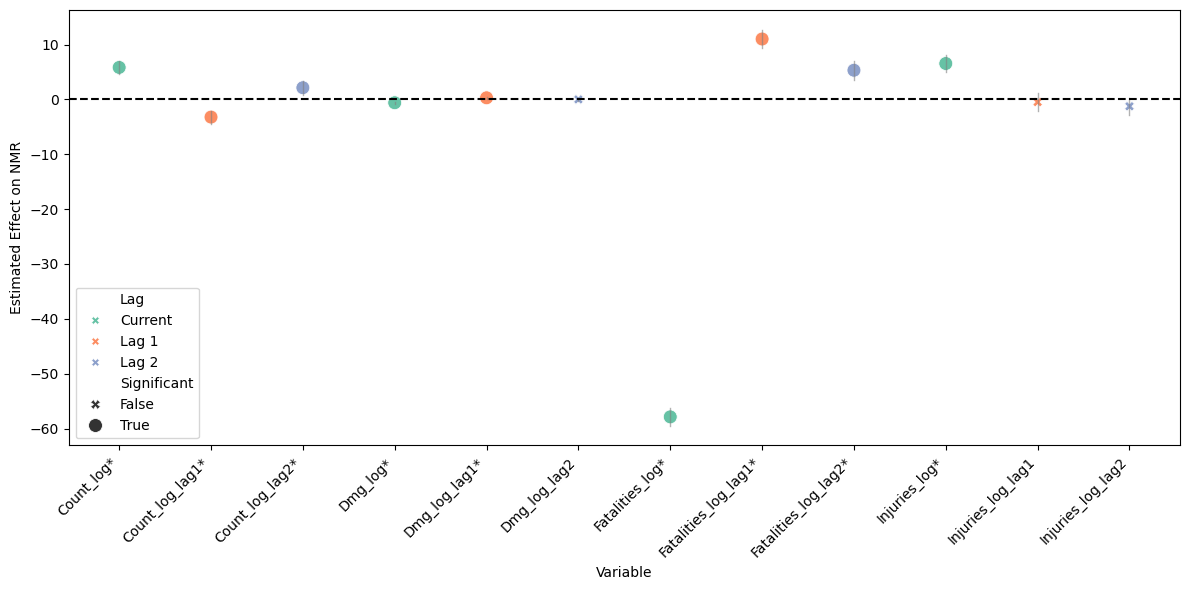

In [36]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df_hurricane = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df_hurricane['Significant'] = (coef_df_hurricane['CI_lower'] * coef_df_hurricane['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df_hurricane['Label'] = coef_df_hurricane.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df_hurricane['Label'] = pd.Categorical(coef_df_hurricane['Label'], categories=sorted(coef_df_hurricane['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df_hurricane,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df_hurricane.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
# plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [37]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,5.8347,0.0,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,-3.2152,0.0000,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,2.1357,0.0009
3,Dmg_log,-0.6040,0.0,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,0.2990,0.0131,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,0.0048,0.9707
6,Fatalities_log,-57.8698,0.0,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,11.0161,0.0000,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,5.3232,0.0000
9,Injuries_log,6.5488,0.0,NaN,NaN,NaN,NaN


## Tornado
### Note: For Tornado, fixed effect regression did not pass the housman test. But I asked chatGPT that even though it didn't pass, I can still use fixed effect regression to keep the consistency

In [38]:
# Make sure multi-index is set
df_year_nmr_tornado = df_year_nmr_tornado.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars
for var in all_vars:
    df_year_nmr_tornado[f'{var}_lag1'] = df_year_nmr_tornado.groupby(level=0)[var].shift(1)
    df_year_nmr_tornado[f'{var}_lag2'] = df_year_nmr_tornado.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
#     re_model = RandomEffects(endog, exog)
    fe_result = fe_model.fit()
#     re_result = re_model.fit()
    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result


# Run Random Effects and Hausman Test for current year model
model_df = df_year_nmr_tornado[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))

# Run current year model
exog_vars_current = log_vars
fe_current = run_panel_regression(df_year_nmr_tornado, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars ]
fe_lag1 = run_panel_regression(df_year_nmr_tornado, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars]
fe_lag2 = run_panel_regression(df_year_nmr_tornado, exog_vars_lag2, "Lag 2 Years")




🧪 Hausman Test
                    Model Comparison                    
                         Fixed Effects    Random Effects
--------------------------------------------------------
Dep. Variable                      NMR               NMR
Estimator                     PanelOLS     RandomEffects
No. Observations                 63800             63800
Cov. Est.                   Unadjusted        Unadjusted
R-squared                    6.971e-05            0.0001
R-Squared (Within)           7.547e-05         1.825e-06
R-Squared (Between)            -0.0001            0.0024
R-Squared (Overall)          1.176e-05            0.0008
F-statistic                     1.0559            2.1175
P-value (F-stat)                0.3766            0.0758
=====================     ============   ===============
const                           0.2274            0.2139
                              (4.1978)          (1.5024)
Dmg_log                        -0.0151           -0.1836
               

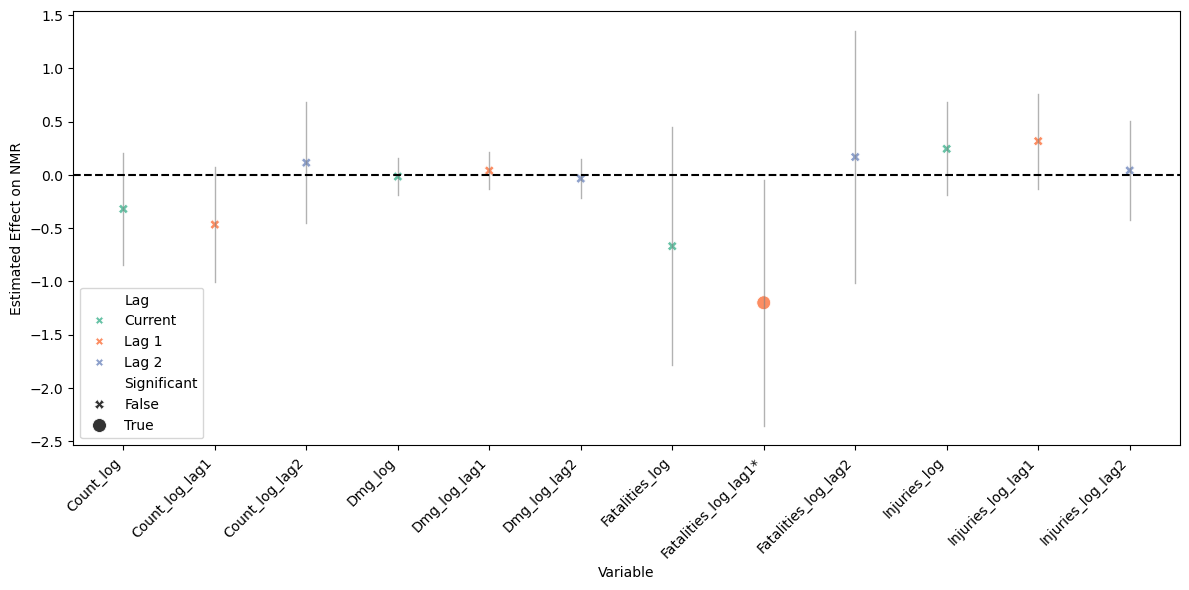

In [39]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df_tornado = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df_tornado['Significant'] = (coef_df_tornado['CI_lower'] * coef_df_tornado['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df_tornado['Label'] = coef_df_tornado.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df_tornado['Label'] = pd.Categorical(coef_df_tornado['Label'], categories=sorted(coef_df_tornado['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df_tornado,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df_tornado.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
# plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,-0.3198,0.2342,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,-0.4663,0.0929,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,0.1150,0.6925
3,Dmg_log,-0.0151,0.8617,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,0.0406,0.6489,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,-0.0343,0.7112
6,Fatalities_log,-0.6691,0.2408,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,-1.2005,0.0416,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,0.1684,0.7808
9,Injuries_log,0.2451,0.2708,NaN,NaN,NaN,NaN


## Wildfire

In [41]:
# Make sure multi-index is set
df_year_nmr_wildfire = df_year_nmr_wildfire.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars
for var in all_vars:
    df_year_nmr_wildfire[f'{var}_lag1'] = df_year_nmr_wildfire.groupby(level=0)[var].shift(1)
    df_year_nmr_wildfire[f'{var}_lag2'] = df_year_nmr_wildfire.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
#     re_model = RandomEffects(endog, exog)
    fe_result = fe_model.fit()
#     re_result = re_model.fit()
    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result


# Run Random Effects and Hausman Test for current year model
model_df = df_year_nmr_wildfire[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))

# Run current year model
exog_vars_current = log_vars
fe_current = run_panel_regression(df_year_nmr_wildfire, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars]
fe_lag1 = run_panel_regression(df_year_nmr_wildfire, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars]
fe_lag2 = run_panel_regression(df_year_nmr_wildfire, exog_vars_lag2, "Lag 2 Years")




🧪 Hausman Test
                    Model Comparison                    
                         Fixed Effects    Random Effects
--------------------------------------------------------
Dep. Variable                      NMR               NMR
Estimator                     PanelOLS     RandomEffects
No. Observations                 63800             63800
Cov. Est.                   Unadjusted        Unadjusted
R-squared                       0.0001            0.0001
R-Squared (Within)              0.0002            0.0002
R-Squared (Between)            -0.0019           -0.0015
R-Squared (Overall)            -0.0004           -0.0003
F-statistic                     2.2167            1.8535
P-value (F-stat)                0.0645            0.1156
=====================     ============   ===============
const                           0.2116            0.2100
                              (4.2318)          (1.4445)
Dmg_log                         0.0117           -0.0689
               

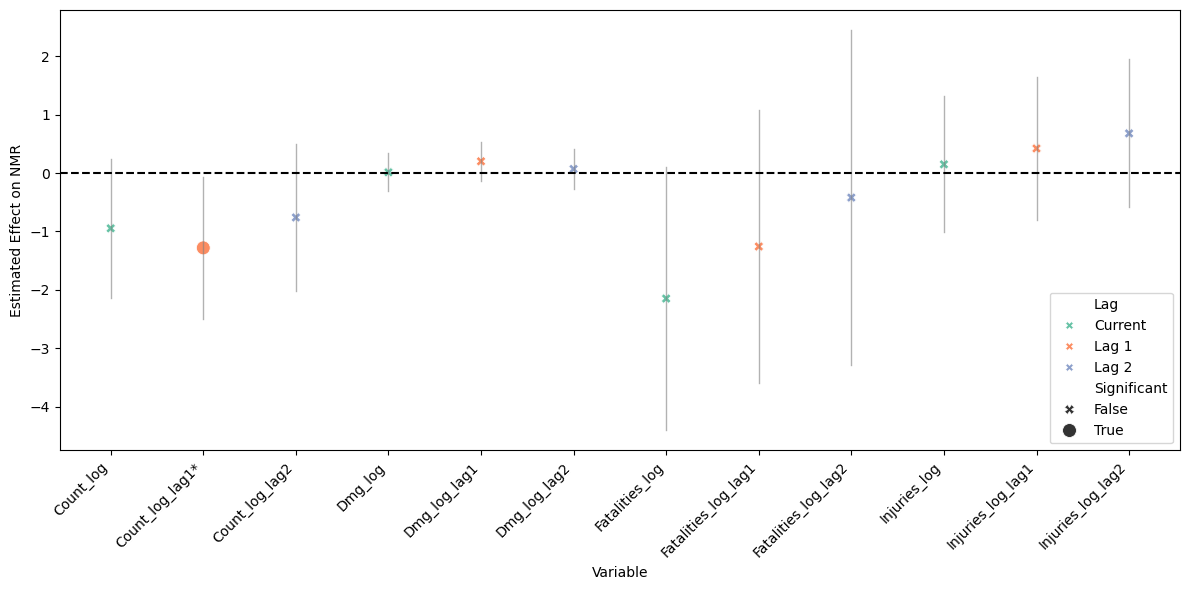

In [42]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df_wildfire = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df_wildfire['Significant'] = (coef_df_wildfire['CI_lower'] * coef_df_wildfire['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df_wildfire['Label'] = coef_df_wildfire.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df_wildfire['Label'] = pd.Categorical(coef_df_wildfire['Label'], categories=sorted(coef_df_wildfire['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df_wildfire,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df_wildfire.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
# plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [43]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,-0.9474,0.1187,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,-1.2823,0.0392,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,-0.7616,0.2367
3,Dmg_log,0.0117,0.9434,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,0.2009,0.2356,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,0.0695,0.6968
6,Fatalities_log,-2.1503,0.0620,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,-1.2588,0.2908,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,-0.4207,0.7739
9,Injuries_log,0.1487,0.8026,NaN,NaN,NaN,NaN


##  Fixed Effect Panel Regression 2
## Here, I set the rows where the disaster did not occur from 0 to NaN for damage, fatalities, and injuries.
## Flood

In [44]:
vars_use = ["Existance"]
for var in vars_use:
    df_year_nmr_flood[f'{var}_lag1'] = df_year_nmr_flood.groupby(level=0)[var].shift(1)
    df_year_nmr_flood[f'{var}_lag2'] = df_year_nmr_flood.groupby(level=0)[var].shift(2)
df_year_nmr_flood_nan = df_year_nmr_flood
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log']
for col in log_vars:
    df_year_nmr_flood_nan.loc[df_year_nmr_flood_nan['Existance'] == 0, col] = np.nan
for lag in ['', '_lag1', '_lag2']:
    for var in ['Dmg_log', 'Fatalities_log', 'Injuries_log']:
        col = f"{var}{lag}"
        flag_col = f"Existance{lag}" if lag else "Existance"
        df_year_nmr_flood_nan.loc[df_year_nmr_flood_nan[flag_col] == 0, col] = np.nan

In [45]:
# Make sure multi-index is set
# df_year_nmr_flood_nan = df_year_nmr_flood_nan.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars
for var in all_vars:
    df_year_nmr_flood_nan[f'{var}_lag1'] = df_year_nmr_flood_nan.groupby(level=0)[var].shift(1)
    df_year_nmr_flood_nan[f'{var}_lag2'] = df_year_nmr_flood_nan.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result

# Run current year model
exog_vars_current = log_vars
fe_current = run_panel_regression(df_year_nmr_flood_nan, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars ]
fe_lag1 = run_panel_regression(df_year_nmr_flood_nan, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars]
fe_lag2 = run_panel_regression(df_year_nmr_flood_nan, exog_vars_lag2, "Lag 2 Years")

# Optionally: Run Random Effects and Hausman Test for current year model
model_df = df_year_nmr_flood_nan[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))



📘 Fixed Effects Results – Current Year
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0048
Estimator:                   PanelOLS   R-squared (Between):             -0.0052
No. Observations:               18174   R-squared (Within):               0.0042
Date:                Fri, Apr 18 2025   R-squared (Overall):              0.0012
Time:                        03:48:36   Log-likelihood                -7.265e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      18.315
Entities:                        2937   P-value                           0.0000
Avg Obs:                       6.1879   Distribution:                 F(4,15214)
Min Obs:                       1.0000                                           
Max Obs:                       20.000   F-statistic (robust):        

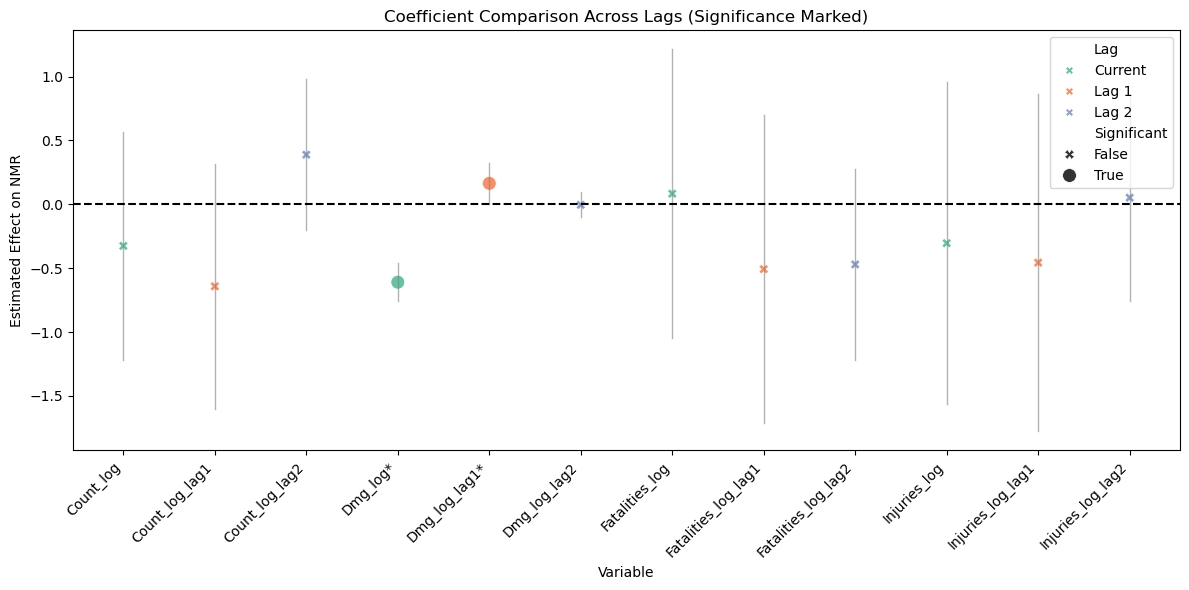

In [46]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df['Significant'] = (coef_df['CI_lower'] * coef_df['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df['Label'] = coef_df.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df['Label'] = pd.Categorical(coef_df['Label'], categories=sorted(coef_df['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [47]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,-0.3251,0.4754,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,-0.6419,0.1887,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,0.3888,0.1976
3,Dmg_log,-0.6097,0.0000,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,0.1643,0.0427,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,-0.0039,0.9370
6,Fatalities_log,0.0837,0.8846,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,-0.5076,0.4087,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,-0.4707,0.2163
9,Injuries_log,-0.3044,0.6356,NaN,NaN,NaN,NaN


## Hurricane

In [48]:
vars_use = ["Existance"]
for var in vars_use:
    df_year_nmr_hurricane[f'{var}_lag1'] = df_year_nmr_hurricane.groupby(level=0)[var].shift(1)
    df_year_nmr_hurricane[f'{var}_lag2'] = df_year_nmr_hurricane.groupby(level=0)[var].shift(2)
df_year_nmr_hurricane_nan = df_year_nmr_hurricane
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log']
for col in log_vars:
    df_year_nmr_hurricane_nan.loc[df_year_nmr_hurricane_nan['Existance'] == 0, col] = np.nan
for lag in ['', '_lag1', '_lag2']:
    for var in ['Dmg_log', 'Fatalities_log', 'Injuries_log']:
        col = f"{var}{lag}"
        flag_col = f"Existance{lag}" if lag else "Existance"
        df_year_nmr_hurricane_nan.loc[df_year_nmr_hurricane_nan[flag_col] == 0, col] = np.nan

In [49]:
# Make sure multi-index is set
# df_year_nmr_hurricane_nan = df_year_nmr_hurricane_nan.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars
for var in all_vars:
    df_year_nmr_hurricane_nan[f'{var}_lag1'] = df_year_nmr_hurricane_nan.groupby(level=0)[var].shift(1)
    df_year_nmr_hurricane_nan[f'{var}_lag2'] = df_year_nmr_hurricane_nan.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result

# Run current year model
exog_vars_current = log_vars 
fe_current = run_panel_regression(df_year_nmr_hurricane_nan, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars ]
fe_lag1 = run_panel_regression(df_year_nmr_hurricane_nan, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars ]
fe_lag2 = run_panel_regression(df_year_nmr_hurricane_nan, exog_vars_lag2, "Lag 2 Years")

# Optionally: Run Random Effects and Hausman Test for current year model
model_df = df_year_nmr_hurricane_nan[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))



📘 Fixed Effects Results – Current Year
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.3304
Estimator:                   PanelOLS   R-squared (Between):             -0.5228
No. Observations:                2049   R-squared (Within):               0.3307
Date:                Fri, Apr 18 2025   R-squared (Overall):              0.2210
Time:                        03:48:37   Log-likelihood                   -9676.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      146.44
Entities:                         840   P-value                           0.0000
Avg Obs:                       2.4393   Distribution:                  F(4,1187)
Min Obs:                       1.0000                                           
Max Obs:                       11.000   F-statistic (robust):        

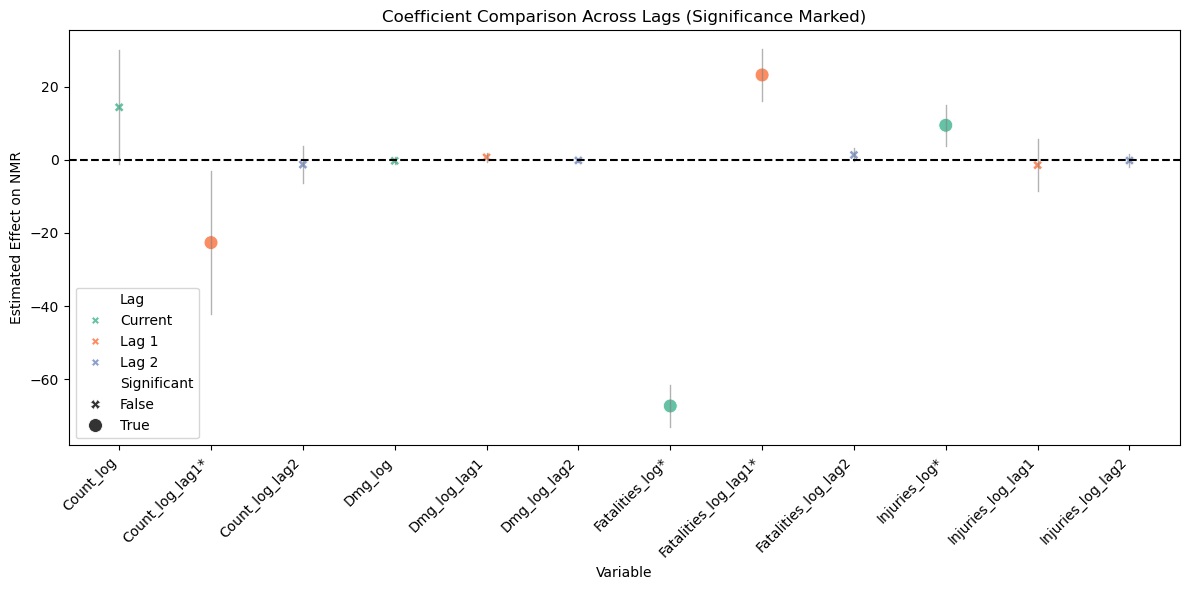

In [50]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df['Significant'] = (coef_df['CI_lower'] * coef_df['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df['Label'] = coef_df.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df['Label'] = pd.Categorical(coef_df['Label'], categories=sorted(coef_df['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,14.3570,0.0713,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,-22.6468,0.0239,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,-1.3094,0.6171
3,Dmg_log,-0.2840,0.5561,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,0.6762,0.2681,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,-0.1764,0.2873
6,Fatalities_log,-67.3145,0.0000,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,23.1957,0.0000,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,1.3338,0.1400
9,Injuries_log,9.4364,0.0011,NaN,NaN,NaN,NaN


## Tornado

In [52]:
vars_use = ["Existance"]
for var in vars_use:
    df_year_nmr_tornado[f'{var}_lag1'] = df_year_nmr_tornado.groupby(level=0)[var].shift(1)
    df_year_nmr_tornado[f'{var}_lag2'] = df_year_nmr_tornado.groupby(level=0)[var].shift(2)
df_year_nmr_tornado_nan = df_year_nmr_tornado
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log']
for col in log_vars:
    df_year_nmr_tornado_nan.loc[df_year_nmr_tornado_nan['Existance'] == 0, col] = np.nan
for lag in ['', '_lag1', '_lag2']:
    for var in ['Dmg_log', 'Fatalities_log', 'Injuries_log']:
        col = f"{var}{lag}"
        flag_col = f"Existance{lag}" if lag else "Existance"
        df_year_nmr_tornado_nan.loc[df_year_nmr_tornado_nan[flag_col] == 0, col] = np.nan

In [53]:
# Make sure multi-index is set
# df_year_nmr_tornado_nan = df_year_nmr_tornado_nan.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars 
for var in all_vars:
    df_year_nmr_tornado_nan[f'{var}_lag1'] = df_year_nmr_tornado_nan.groupby(level=0)[var].shift(1)
    df_year_nmr_tornado_nan[f'{var}_lag2'] = df_year_nmr_tornado_nan.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result

# Run current year model
exog_vars_current = log_vars
fe_current = run_panel_regression(df_year_nmr_tornado_nan, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars ]
fe_lag1 = run_panel_regression(df_year_nmr_tornado_nan, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars ]
fe_lag2 = run_panel_regression(df_year_nmr_tornado_nan, exog_vars_lag2, "Lag 2 Years")

# Optionally: Run Random Effects and Hausman Test for current year model
model_df = df_year_nmr_tornado_nan[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))



📘 Fixed Effects Results – Current Year
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0003
Estimator:                   PanelOLS   R-squared (Between):              0.0003
No. Observations:                9605   R-squared (Within):               0.0004
Date:                Fri, Apr 18 2025   R-squared (Overall):              0.0029
Time:                        03:48:38   Log-likelihood                -3.604e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      0.5266
Entities:                        2505   P-value                           0.7162
Avg Obs:                       3.8343   Distribution:                  F(4,7077)
Min Obs:                       1.0000                                           
Max Obs:                       18.000   F-statistic (robust):        

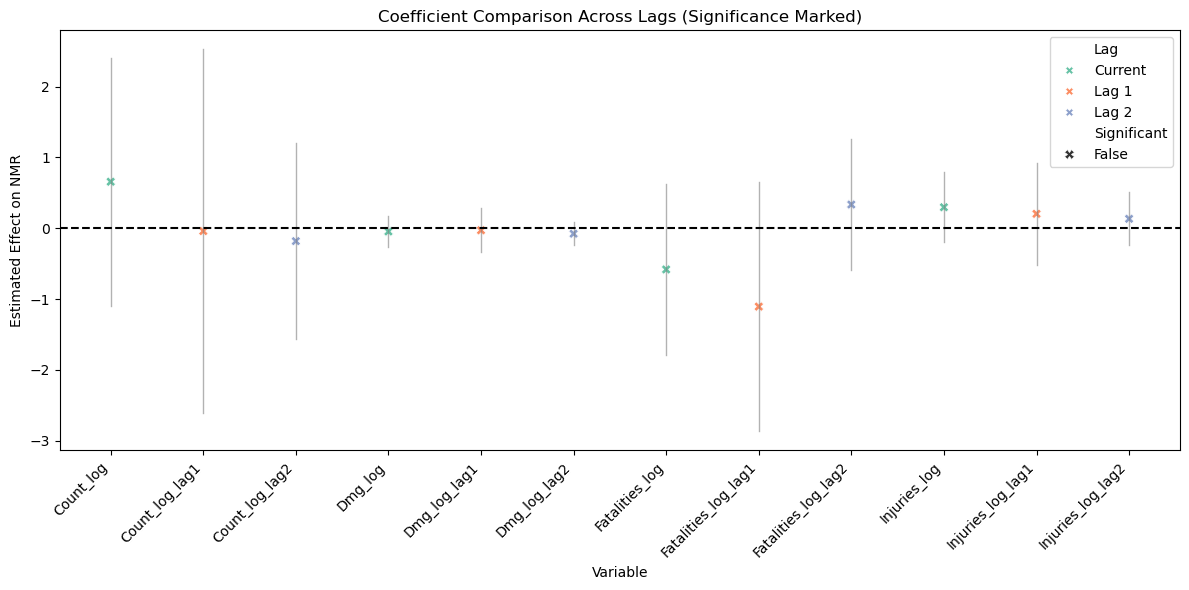

In [54]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df['Significant'] = (coef_df['CI_lower'] * coef_df['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df['Label'] = coef_df.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df['Label'] = pd.Categorical(coef_df['Label'], categories=sorted(coef_df['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,0.6567,0.4615,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,-0.0402,0.9755,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,-0.1816,0.7967
3,Dmg_log,-0.0459,0.6737,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,-0.0285,0.8579,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,-0.0769,0.3631
6,Fatalities_log,-0.5817,0.3435,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,-1.1060,0.2181,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,0.3347,0.4748
9,Injuries_log,0.2968,0.2370,NaN,NaN,NaN,NaN


## Wildfire

In [56]:
vars_use = ["Existance"]
for var in vars_use:
    df_year_nmr_wildfire[f'{var}_lag1'] = df_year_nmr_wildfire.groupby(level=0)[var].shift(1)
    df_year_nmr_wildfire[f'{var}_lag2'] = df_year_nmr_wildfire.groupby(level=0)[var].shift(2)
df_year_nmr_wildfire_nan = df_year_nmr_wildfire
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log']
for col in log_vars:
    df_year_nmr_wildfire_nan.loc[df_year_nmr_wildfire_nan['Existance'] == 0, col] = np.nan
for lag in ['', '_lag1', '_lag2']:
    for var in ['Dmg_log', 'Fatalities_log', 'Injuries_log']:
        col = f"{var}{lag}"
        flag_col = f"Existance{lag}" if lag else "Existance"
        df_year_nmr_wildfire_nan.loc[df_year_nmr_wildfire_nan[flag_col] == 0, col] = np.nan

In [57]:
# Make sure multi-index is set
# df_year_nmr_wildfire_nan = df_year_nmr_wildfire_nan.set_index(['FIPS', 'Year'])

# Define log variables (assumed already created) and corresponding flags
log_vars = ['Dmg_log', 'Fatalities_log', 'Injuries_log', 'Count_log']
# flag_vars = ['Existance']

# Generate lags for all selected variables
all_vars = log_vars
for var in all_vars:
    df_year_nmr_wildfire_nan[f'{var}_lag1'] = df_year_nmr_wildfire_nan.groupby(level=0)[var].shift(1)
    df_year_nmr_wildfire_nan[f'{var}_lag2'] = df_year_nmr_wildfire_nan.groupby(level=0)[var].shift(2)

# Regression runner
def run_panel_regression(df, exog_vars, name="Model"):
    # Drop rows with NaNs in any exog or endog
    model_df = df[exog_vars + ['NMR']].dropna()
    exog = model_df[exog_vars]
    endog = model_df['NMR']
    
    fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
    fe_result = fe_model.fit()

    print(f"\n📘 Fixed Effects Results – {name}")
    print(fe_result)

    return fe_result

# Run current year model
exog_vars_current = log_vars
fe_current = run_panel_regression(df_year_nmr_wildfire_nan, exog_vars_current, "Current Year")

# Run 1-year lag model
exog_vars_lag1 = [f'{v}_lag1' for v in log_vars ]
fe_lag1 = run_panel_regression(df_year_nmr_wildfire_nan, exog_vars_lag1, "Lag 1 Year")

# Run 2-year lag model
exog_vars_lag2 = [f'{v}_lag2' for v in log_vars ]
fe_lag2 = run_panel_regression(df_year_nmr_wildfire_nan, exog_vars_lag2, "Lag 2 Years")

# Optionally: Run Random Effects and Hausman Test for current year model
model_df = df_year_nmr_wildfire_nan[exog_vars_current + ['NMR']].dropna()
exog = sm.add_constant(model_df[exog_vars_current])
endog = model_df['NMR']

fe_model = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
re_model = RandomEffects(endog, exog)

fe_result = fe_model.fit()
re_result = re_model.fit()

print("\n🧪 Hausman Test")
print(compare({"Fixed Effects": fe_result, "Random Effects": re_result}, precision='tstats'))



📘 Fixed Effects Results – Current Year
                          PanelOLS Estimation Summary                           
Dep. Variable:                    NMR   R-squared:                        0.0073
Estimator:                   PanelOLS   R-squared (Between):             -0.0112
No. Observations:                1484   R-squared (Within):               0.0051
Date:                Fri, Apr 18 2025   R-squared (Overall):             -0.0064
Time:                        03:48:39   Log-likelihood                   -4996.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1.4673
Entities:                         661   P-value                           0.2102
Avg Obs:                       2.2451   Distribution:                   F(4,800)
Min Obs:                       1.0000                                           
Max Obs:                       19.000   F-statistic (robust):        

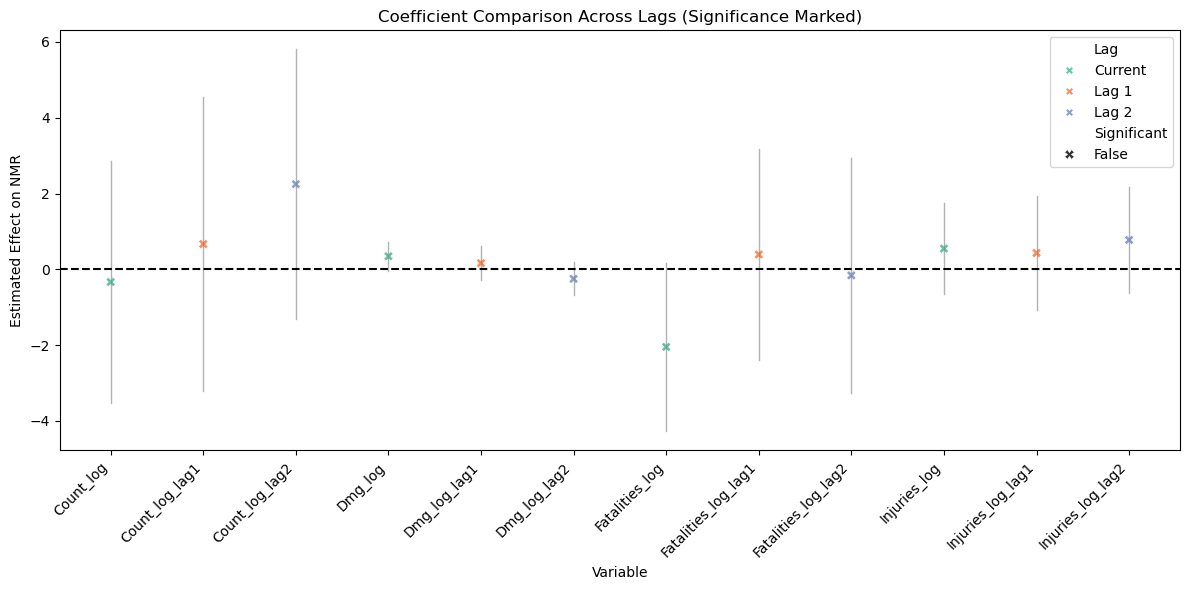

In [58]:
def extract_coeffs(result, label):
    coef = result.params
    lower = result.conf_int().iloc[:, 0]
    upper = result.conf_int().iloc[:, 1]
    return pd.DataFrame({
        'Variable': coef.index,
        'Coefficient': coef.values,
        'CI_lower': lower.values,
        'CI_upper': upper.values,
        'Lag': label
    })
df_current = extract_coeffs(fe_current, "Current")
df_lag1 = extract_coeffs(fe_lag1, "Lag 1")
df_lag2 = extract_coeffs(fe_lag2, "Lag 2")

coef_df = pd.concat([df_current, df_lag1, df_lag2], ignore_index=True)
coef_df['Significant'] = (coef_df['CI_lower'] * coef_df['CI_upper']) > 0

# Optional: Add stars to significant labels
coef_df['Label'] = coef_df.apply(
    lambda row: f"{row['Variable']}*" if row['Significant'] else row['Variable'],
    axis=1
)
coef_df['Label'] = pd.Categorical(coef_df['Label'], categories=sorted(coef_df['Label'].unique()), ordered=True)

# Step 2: Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=coef_df,
    x='Label',
    y='Coefficient',
    hue='Lag',
    style='Significant',
    size='Significant',
    sizes={True: 100, False: 50},
    markers={True: 'o', False: 'X'},
    palette='Set2',
)

# Step 3: Error bars
for _, row in coef_df.iterrows():
    plt.plot(
        [row['Label'], row['Label']],
        [row['CI_lower'], row['CI_upper']],
        color='gray',
        linewidth=1,
        alpha=0.6
    )

plt.axhline(0, linestyle='--', color='black')
plt.title("Coefficient Comparison Across Lags (Significance Marked)")
plt.ylabel("Estimated Effect on NMR")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [59]:
def summarize_model(result, label):
    return pd.DataFrame({
        'Variable': result.params.index,
        f'{label}_coef': result.params.values,
        f'{label}_pval': result.pvalues.values
    })

summary_current = summarize_model(fe_current, 'Current')
summary_lag1 = summarize_model(fe_lag1, 'Lag1')
summary_lag2 = summarize_model(fe_lag2, 'Lag2')

# Merge them together
from functools import reduce
comparison_table = reduce(lambda left, right: pd.merge(left, right, on='Variable', how='outer'),
                          [summary_current, summary_lag1, summary_lag2])

# Clean display
comparison_table = comparison_table.round(4)
comparison_table['BaseVar'] = comparison_table['Variable'].str.replace('_lag1', '', regex=False).str.replace('_lag2', '', regex=False)
comparison_table = comparison_table.sort_values(by=['BaseVar', 'Variable'])
comparison_table.drop(columns='BaseVar', inplace=True)
comparison_table

,Variable,Current_coef,Current_pval,Lag1_coef,Lag1_pval,Lag2_coef,Lag2_pval
0,Count_log,-0.3344,0.8373,NaN,NaN,NaN,NaN
1,Count_log_lag1,NaN,NaN,0.6681,0.7349,NaN,NaN
2,Count_log_lag2,NaN,NaN,NaN,NaN,2.2484,0.2147
3,Dmg_log,0.3449,0.0738,NaN,NaN,NaN,NaN
4,Dmg_log_lag1,NaN,NaN,0.1644,0.4810,NaN,NaN
5,Dmg_log_lag2,NaN,NaN,NaN,NaN,-0.2497,0.2617
6,Fatalities_log,-2.0467,0.0716,NaN,NaN,NaN,NaN
7,Fatalities_log_lag1,NaN,NaN,0.3916,0.7833,NaN,NaN
8,Fatalities_log_lag2,NaN,NaN,NaN,NaN,-0.1590,0.9196
9,Injuries_log,0.5485,0.3680,NaN,NaN,NaN,NaN


## Preprocessing for Time Series Analysis, XGBOOST, and regression analysis

In [60]:
SHELDUS_0020_hurricane = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Hurricane/Tropical Storm"].reset_index()
SHELDUS_0020_flooding  = SHELDUS_0020_sel[SHELDUS_0020_sel["Hazard"]=="Flooding"].reset_index()

In [61]:
hurricane_induced_floods = pd.merge(
    SHELDUS_0020_flooding, 
    SHELDUS_0020_hurricane, 
    on=['County FIPS', 'Year', 'Month'],
    suffixes=('_flood', '_hurricane')
)
flood_indices = hurricane_induced_floods['index_flood']

In [62]:
SHELDUS_0020_sel.loc[flood_indices, 'Hazard'] = 'Hurricane/Tropical Storm'

In [63]:
SHELDUS_0020_use = SHELDUS_0020_sel[(SHELDUS_0020_sel["Fatalities"]!=0)|(SHELDUS_0020_sel["Injuries"]!=0)|(SHELDUS_0020_sel["PropertyDmgPerCapita(ADJ 2020)"]>1)]
SHELDUS_0020_use_group = SHELDUS_0020_use.groupby(["County FIPS","Hazard","Year"]).agg({"Month":"count",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        
                                                                                        
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean",
                                                                                       "CropDmg(ADJ 2020)":"sum",
                                                                                       "CropDmgPerCapita(ADJ 2020)":"mean"}).reset_index()
SHELDUS_0020_use_group = SHELDUS_0020_use_group.rename(columns={"Month":"count"})

SHELDUS_0020_use_group["Loss"] = SHELDUS_0020_use_group["Fatalities"] * 11600000 + SHELDUS_0020_use_group["Injuries"] / 10 * 11600000 + SHELDUS_0020_use_group["PropertyDmg(ADJ 2020)"]

df_20_years_by_county = SHELDUS_0020_use_group.groupby(['County FIPS',"Hazard"]).agg({"count":"sum",
                                                                                        "Fatalities":"sum",
                                                                                        "Injuries":"sum",
                                                                                        "PropertyDmg(ADJ 2020)":"sum",
                                                                                        "PropertyDmgPerCapita(ADJ 2020)":"mean",
                                                                                        "CropDmg(ADJ 2020)":"sum",
                                                                                        "CropDmgPerCapita(ADJ 2020)":"mean",
                                                                                        "Loss":"sum"}).reset_index()


In [64]:
df_20_years_by_county = df_20_years_by_county.rename(columns={"count":"frequency"})

In [65]:
def classify_impact(data, value_column):
    Q1 = data[value_column].quantile(0.25)
    Q3 = data[value_column].quantile(0.75)
    
    def classification(value):
        if value <= Q1:
            return 'Low Impact'
        elif (value > Q1) & (value < Q3):
            return 'Moderate Impact'
        elif value >= Q3:
            return 'High Impact'
    
    return data[value_column].apply(classification)

In [66]:
def classify_combined_impact(data, column1, column2, new_column):
    def determine_impact(impact1, impact2):
        if impact1 == 'High Impact' and impact2 == 'High Impact':
            return 'High Impact'
        elif impact1 == 'Low Impact' and impact2 == 'Low Impact':
            return 'Low Impact'
        else:
            return 'Moderate Impact'

    data[new_column] = data.apply(lambda row: determine_impact(row[column1], row[column2]), axis=1)
    return data

In [67]:
disaster_list = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
SHELDUS_20_use_flooding  = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Flooding"]
SHELDUS_20_use_hurricane = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Hurricane/Tropical Storm"]
SHELDUS_20_use_wildfire  = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Wildfire"]
# SHELDUS_20_use_heat      = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Heat"]
SHELDUS_20_use_tornado   = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Tornado"]


SHELDUS_20_use_flooding['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_flooding, "PropertyDmgPerCapita(ADJ 2020)")
SHELDUS_20_use_hurricane['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_hurricane, "PropertyDmgPerCapita(ADJ 2020)")
SHELDUS_20_use_wildfire['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_wildfire, "PropertyDmgPerCapita(ADJ 2020)")
# SHELDUS_20_use_heat['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_heat, "Loss")
SHELDUS_20_use_tornado['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_tornado, "PropertyDmgPerCapita(ADJ 2020)")

SHELDUS_20_use_flooding['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_flooding, "frequency")
SHELDUS_20_use_hurricane['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_hurricane,"frequency")
SHELDUS_20_use_wildfire['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_wildfire, "frequency")
# SHELDUS_20_use_heat['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_heat, "frequency")
SHELDUS_20_use_tornado['ImpactLevel_2'] = classify_impact(SHELDUS_20_use_tornado, "frequency")

SHELDUS_20_use_flooding = classify_combined_impact(SHELDUS_20_use_flooding, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_hurricane = classify_combined_impact(SHELDUS_20_use_hurricane, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_wildfire = classify_combined_impact(SHELDUS_20_use_wildfire, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
# SHELDUS_20_use_heat = classify_combined_impact(SHELDUS_20_use_heat, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')
SHELDUS_20_use_tornado = classify_combined_impact(SHELDUS_20_use_tornado, 'ImpactLevel_1', 'ImpactLevel_2', 'ImpactLevel')

C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\4100627513.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_20_use_flooding['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_flooding, "PropertyDmgPerCapita(ADJ 2020)")
C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\4100627513.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SHELDUS_20_use_hurricane['ImpactLevel_1'] = classify_impact(SHELDUS_20_use_hurricane, "PropertyDmgPerCapita(ADJ 2020)")
C:\Users\xiang11\AppData\Local\Temp\ipykern

In [68]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [69]:
flooding_list = list(SHELDUS_20_use_flooding["County FIPS"])
flooding_high_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "High Impact"]["County FIPS"])
flooding_low_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "Low Impact"]["County FIPS"])
flooding_med_list = list(SHELDUS_20_use_flooding[SHELDUS_20_use_flooding["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

hurricane_list = list(SHELDUS_20_use_hurricane["County FIPS"])
hurricane_high_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "High Impact"]["County FIPS"])
hurricane_low_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "Low Impact"]["County FIPS"])
hurricane_med_list = list(SHELDUS_20_use_hurricane[SHELDUS_20_use_hurricane["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

wildfire_list = list(SHELDUS_20_use_wildfire["County FIPS"])
wildfire_high_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "High Impact"]["County FIPS"])
wildfire_low_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "Low Impact"]["County FIPS"])
wildfire_med_list = list(SHELDUS_20_use_wildfire[SHELDUS_20_use_wildfire["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

# heat_list = list(SHELDUS_20_use_heat["County FIPS"])
# heat_high_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "High Impact"]["County FIPS"])
# heat_low_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "Low Impact"]["County FIPS"])
# heat_med_list = list(SHELDUS_20_use_heat[SHELDUS_20_use_heat["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

tornado_list = list(SHELDUS_20_use_tornado["County FIPS"])
tornado_high_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "High Impact"]["County FIPS"])
tornado_low_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "Low Impact"]["County FIPS"])
tornado_med_list = list(SHELDUS_20_use_tornado[SHELDUS_20_use_tornado["ImpactLevel"] == "Moderate Impact"]["County FIPS"])

In [70]:
yearly_flooding_all      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_list)]
yearly_flooding_all_mean = yearly_flooding_all[correct_netmig_columns].mean()
yearly_flooding_high     = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_high_list)] 
yearly_flooding_high_mean= yearly_flooding_high[correct_netmig_columns].mean()
yearly_flooding_low      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_low_list)] 
yearly_flooding_low_mean = yearly_flooding_low[correct_netmig_columns].mean()
yearly_flooding_med      = df_pep_0120[df_pep_0120["FIPS"].isin(flooding_med_list)] 
yearly_flooding_med_mean = yearly_flooding_med[correct_netmig_columns].mean()

yearly_hurricane_all      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_list)]
yearly_hurricane_all_mean = yearly_hurricane_all[correct_netmig_columns].mean()
yearly_hurricane_high     = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_high_list)] 
yearly_hurricane_high_mean= yearly_hurricane_high[correct_netmig_columns].mean()
yearly_hurricane_low      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_low_list)] 
yearly_hurricane_low_mean = yearly_hurricane_low[correct_netmig_columns].mean()
yearly_hurricane_med      = df_pep_0120[df_pep_0120["FIPS"].isin(hurricane_med_list)] 
yearly_hurricane_med_mean = yearly_hurricane_med[correct_netmig_columns].mean()

yearly_wildfire_all      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_list)]
yearly_wildfire_all_mean = yearly_wildfire_all[correct_netmig_columns].mean()
yearly_wildfire_high     = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_high_list)] 
yearly_wildfire_high_mean= yearly_wildfire_high[correct_netmig_columns].mean()
yearly_wildfire_low      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_low_list)] 
yearly_wildfire_low_mean = yearly_wildfire_low[correct_netmig_columns].mean()
yearly_wildfire_med      = df_pep_0120[df_pep_0120["FIPS"].isin(wildfire_med_list)] 
yearly_wildfire_med_mean = yearly_wildfire_med[correct_netmig_columns].mean()

# yearly_heat_all      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_list)]
# yearly_heat_all_mean = yearly_heat_all[correct_netmig_columns].mean()
# yearly_heat_high     = df_pep_0120[df_pep_0120["FIPS"].isin(heat_high_list)] 
# yearly_heat_high_mean= yearly_heat_high[correct_netmig_columns].mean()
# yearly_heat_low      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_low_list)] 
# yearly_heat_low_mean = yearly_heat_low[correct_netmig_columns].mean()
# yearly_heat_med      = df_pep_0120[df_pep_0120["FIPS"].isin(heat_med_list)] 
# yearly_heat_med_mean = yearly_heat_med[correct_netmig_columns].mean()

yearly_tornado_all      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_list)]
yearly_tornado_all_mean = yearly_tornado_all[correct_netmig_columns].mean()
yearly_tornado_high     = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_high_list)] 
yearly_tornado_high_mean= yearly_tornado_high[correct_netmig_columns].mean()
yearly_tornado_low      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_low_list)] 
yearly_tornado_low_mean = yearly_tornado_low[correct_netmig_columns].mean()
yearly_tornado_med      = df_pep_0120[df_pep_0120["FIPS"].isin(tornado_med_list)] 
yearly_tornado_med_mean = yearly_tornado_med[correct_netmig_columns].mean()

## Time Series Analysis Result

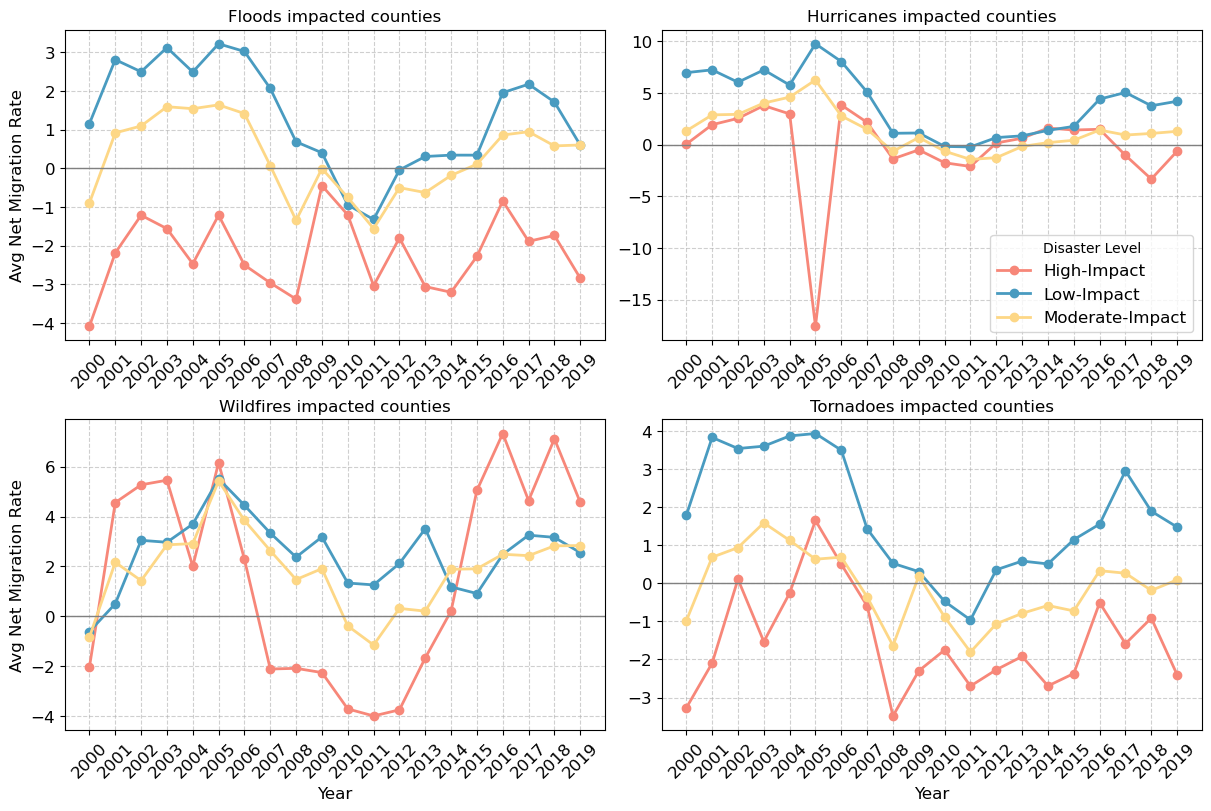

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()
years = list(range(2000, 2020))
fontsize = 12  # Slightly larger font for better readability

# Improved color palette for visual distinction
colors = ['#499BC0', '#FDD786', '#F78779']

# Plotting data for floods
axes[0].plot(years, yearly_flooding_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[0].plot(years, yearly_flooding_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[0].plot(years, yearly_flooding_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
axes[0].set_title("Floods impacted counties", fontsize=fontsize)
# axes[0].set_xlabel("Year", fontsize=fontsize)
axes[0].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[0].set_xticks(years)
axes[0].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[0].tick_params(axis='y', labelsize=fontsize)
# axes[0].legend(title="Disaster Level", fontsize=fontsize)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].axhline(0, color='gray', linewidth=1)

# Plotting data for hurricanes
axes[1].plot(years, yearly_hurricane_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High-Impact', linewidth=2)
axes[1].plot(years, yearly_hurricane_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low-Impact', linewidth=2)
axes[1].plot(years, yearly_hurricane_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Moderate-Impact', linewidth=2)
axes[1].set_title("Hurricanes impacted counties", fontsize=fontsize)
# axes[1].set_xlabel("Year", fontsize=fontsize)
# axes[1].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[1].set_xticks(years)
axes[1].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[1].legend(title="Disaster Level",fontsize=fontsize,loc='lower right')
axes[1].tick_params(axis='y', labelsize=fontsize)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axhline(0, color='gray', linewidth=1)

# Plotting data for wildfires
axes[2].plot(years, yearly_wildfire_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[2].plot(years, yearly_wildfire_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[2].plot(years, yearly_wildfire_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
axes[2].set_title("Wildfires impacted counties", fontsize=fontsize)
axes[2].set_xlabel("Year", fontsize=fontsize)
axes[2].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[2].set_xticks(years)
axes[2].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[2].tick_params(axis='y', labelsize=fontsize)
# axes[2].legend(title="Disaster Level", fontsize=fontsize)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].axhline(0, color='gray', linewidth=1)

# Plotting data for tornadoes
axes[3].plot(years, yearly_tornado_high_mean.values, marker='o', linestyle='-', color=colors[2], label='High', linewidth=2)
axes[3].plot(years, yearly_tornado_low_mean.values, marker='o', linestyle='-', color=colors[0], label='Low', linewidth=2)
axes[3].plot(years, yearly_tornado_med_mean.values, marker='o', linestyle='-', color=colors[1], label='Medium', linewidth=2)
axes[3].set_title("Tornadoes impacted counties", fontsize=fontsize)
axes[3].set_xlabel("Year", fontsize=fontsize)
# axes[3].set_ylabel("Avg Net Migration Rate", fontsize=fontsize)
axes[3].set_xticks(years)
axes[3].set_xticklabels(years, rotation=45, fontsize=fontsize)
axes[3].tick_params(axis='y', labelsize=fontsize)
# axes[3].legend(title="Disaster Level", fontsize=fontsize)
axes[3].grid(True, linestyle='--', alpha=0.6)
axes[3].axhline(0, color='gray', linewidth=1)

# fig.savefig(r"F:\LongMig2025\results\maps\plot2\NMR_0402.png", dpi=300, bbox_inches="tight")


In [72]:
Floods = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Flooding"]
Floods = Floods.rename(columns={"frequency":"Flood_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Flood_Loss","Fatalities":"Flood_Fatalities","Injuries":"Flood_Injuries"})
Hurricane = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Hurricane/Tropical Storm"]
Hurricane = Hurricane.rename(columns={"frequency":"Hurricane_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Hurricane_Loss","Fatalities":"Hurricane_Fatalities","Injuries":"Hurricane_Injuries"})
Wildfire = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Wildfire"]
Wildfire = Wildfire.rename(columns={"frequency":"Wildfire_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Wildfire_Loss","Fatalities":"Wildfire_Fatalities","Injuries":"Wildfire_Injuries"})
Tornado = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Tornado"]
Tornado = Tornado.rename(columns={"frequency":"Tornado_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Tornado_Loss","Fatalities":"Tornado_Fatalities","Injuries":"Tornado_Injuries"})
# Heat = df_20_years_by_county[df_20_years_by_county["Hazard"]=="Heat"]
# Heat = Heat.rename(columns={"frequency":"Heat_Frequency","PropertyDmgPerCapita(ADJ 2020)":"Heat_Loss","Fatalities":"Heat_Fatalities","Injuries":"Heat_Injuries"})
Floods["Flood_Occur"] = 1
Hurricane["Hurricane_Occur"] = 1
Wildfire["Wildfire_Occur"] = 1
Tornado["Tornado_Occur"] = 1
# Heat["Heat_Occur"] = 1
Floods = Floods[["County FIPS","Flood_Frequency","Flood_Loss","Flood_Occur","Flood_Fatalities","Flood_Injuries"]]
Hurricane = Hurricane[["County FIPS","Hurricane_Frequency","Hurricane_Loss","Hurricane_Occur","Hurricane_Fatalities","Hurricane_Injuries"]]
Wildfire = Wildfire[["County FIPS","Wildfire_Frequency","Wildfire_Loss","Wildfire_Occur","Wildfire_Fatalities","Wildfire_Injuries"]]
Tornado = Tornado[["County FIPS","Tornado_Frequency","Tornado_Loss","Tornado_Occur","Tornado_Fatalities","Tornado_Injuries"]]
# Heat = Heat[["County FIPS","Heat_Frequency","Heat_Loss","Heat_Occur","Heat_Fatalities","Heat_Injuries"]]

In [73]:
Disaster = pd.merge(Floods,Hurricane,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Wildfire,on="County FIPS",how='outer')
Disaster = pd.merge(Disaster,Tornado,on="County FIPS",how='outer')
# Disaster = pd.merge(Disaster,Heat,on="County FIPS",how='outer')
Disaster = Disaster.fillna(0)

In [74]:
Disaster.head()

,County FIPS,Flood_Frequency,Flood_Loss,Flood_Occur,Flood_Fatalities,Flood_Injuries,Hurricane_Frequency,Hurricane_Loss,Hurricane_Occur,Hurricane_Fatalities,...,Wildfire_Frequency,Wildfire_Loss,Wildfire_Occur,Wildfire_Fatalities,Wildfire_Injuries,Tornado_Frequency,Tornado_Loss,Tornado_Occur,Tornado_Fatalities,Tornado_Injuries
0,01001,5.0,5.155596,1.0,0.0,0.0,2.0,3.644830,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,49.857632,1.0,3.0,57.0
1,01003,6.0,18.341990,1.0,2.0,1.0,4.0,18.590288,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,2.931754,1.0,0.0,7.0
2,01005,2.0,1.249390,1.0,0.0,0.0,2.0,1.754460,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,6.0,5.448765,1.0,0.0,4.0
3,01007,1.0,9.961340,1.0,0.0,0.0,2.0,8.162715,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,736.519440,1.0,1.0,10.0
4,01009,2.0,2.889540,1.0,0.0,0.0,1.0,1.463220,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,8.0,74.229791,1.0,0.0,40.0


### Compute Net Migration Rate (NMR)

In [75]:
correct_netmig_columns = []
for year in range(2001, 2021):
    column_name_x = f'RNETMIG{year}_x'
    column_name_y = f'RNETMIG{year}_y'
    column_name = f'RNETMIG{year}'
    if column_name in df_pep_0120.columns:
        correct_netmig_columns.append(column_name)
    elif column_name_x in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_x)
    elif column_name_y in df_pep_0120.columns:
        correct_netmig_columns.append(column_name_y)

In [76]:
df_pep_0120["NetMigrationRateTotal"] = df_pep_0120[correct_netmig_columns].mean(axis=1)
df_pep_0120_used = df_pep_0120[['FIPS','STNAME_x', 'CTYNAME_x', 'NetMigrationRateTotal']]

In [77]:
# df_pep_0120.to_csv(data_path+"pep.csv")

In [78]:
df_NMR = pd.merge(df_pep_0120_used,county,on="FIPS",how="inner")
gdf_NMR = gpd.GeoDataFrame(df_NMR,geometry="geometry")

## NMR Map

<Figure size 1000x800 with 0 Axes>

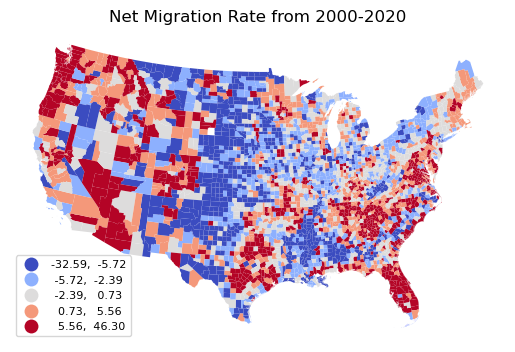

In [79]:
plt.figure(figsize=(10, 8))
gdf_NMR.plot(column="NetMigrationRateTotal",cmap="coolwarm",
             scheme="quantiles",
#              scheme='userdefined',classification_kwds={'bins':[-500,-100,-50,-25,-10,-0.1,0,0.1,10,25,50,100,500]},
             legend=True,legend_kwds={
        "fontsize": 8,  # Adjust font size for smaller text
        "loc": "lower left",  # Position the legend
    })
plt.title("Net Migration Rate from 2000-2020")
plt.axis('off')
plt.show()

## Disaster Map
### Map the frequency and loss

In [80]:
df_disaster = pd.merge(df_20_years_by_county,county,left_on="County FIPS",right_on="FIPS",how="inner")
gdf_disaster = gpd.GeoDataFrame(df_disaster,geometry="geometry")

C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)
C:\Users\xiang11\AppData\Local\ESRI\conda\envs\arcgispro_geo\geo1\Lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


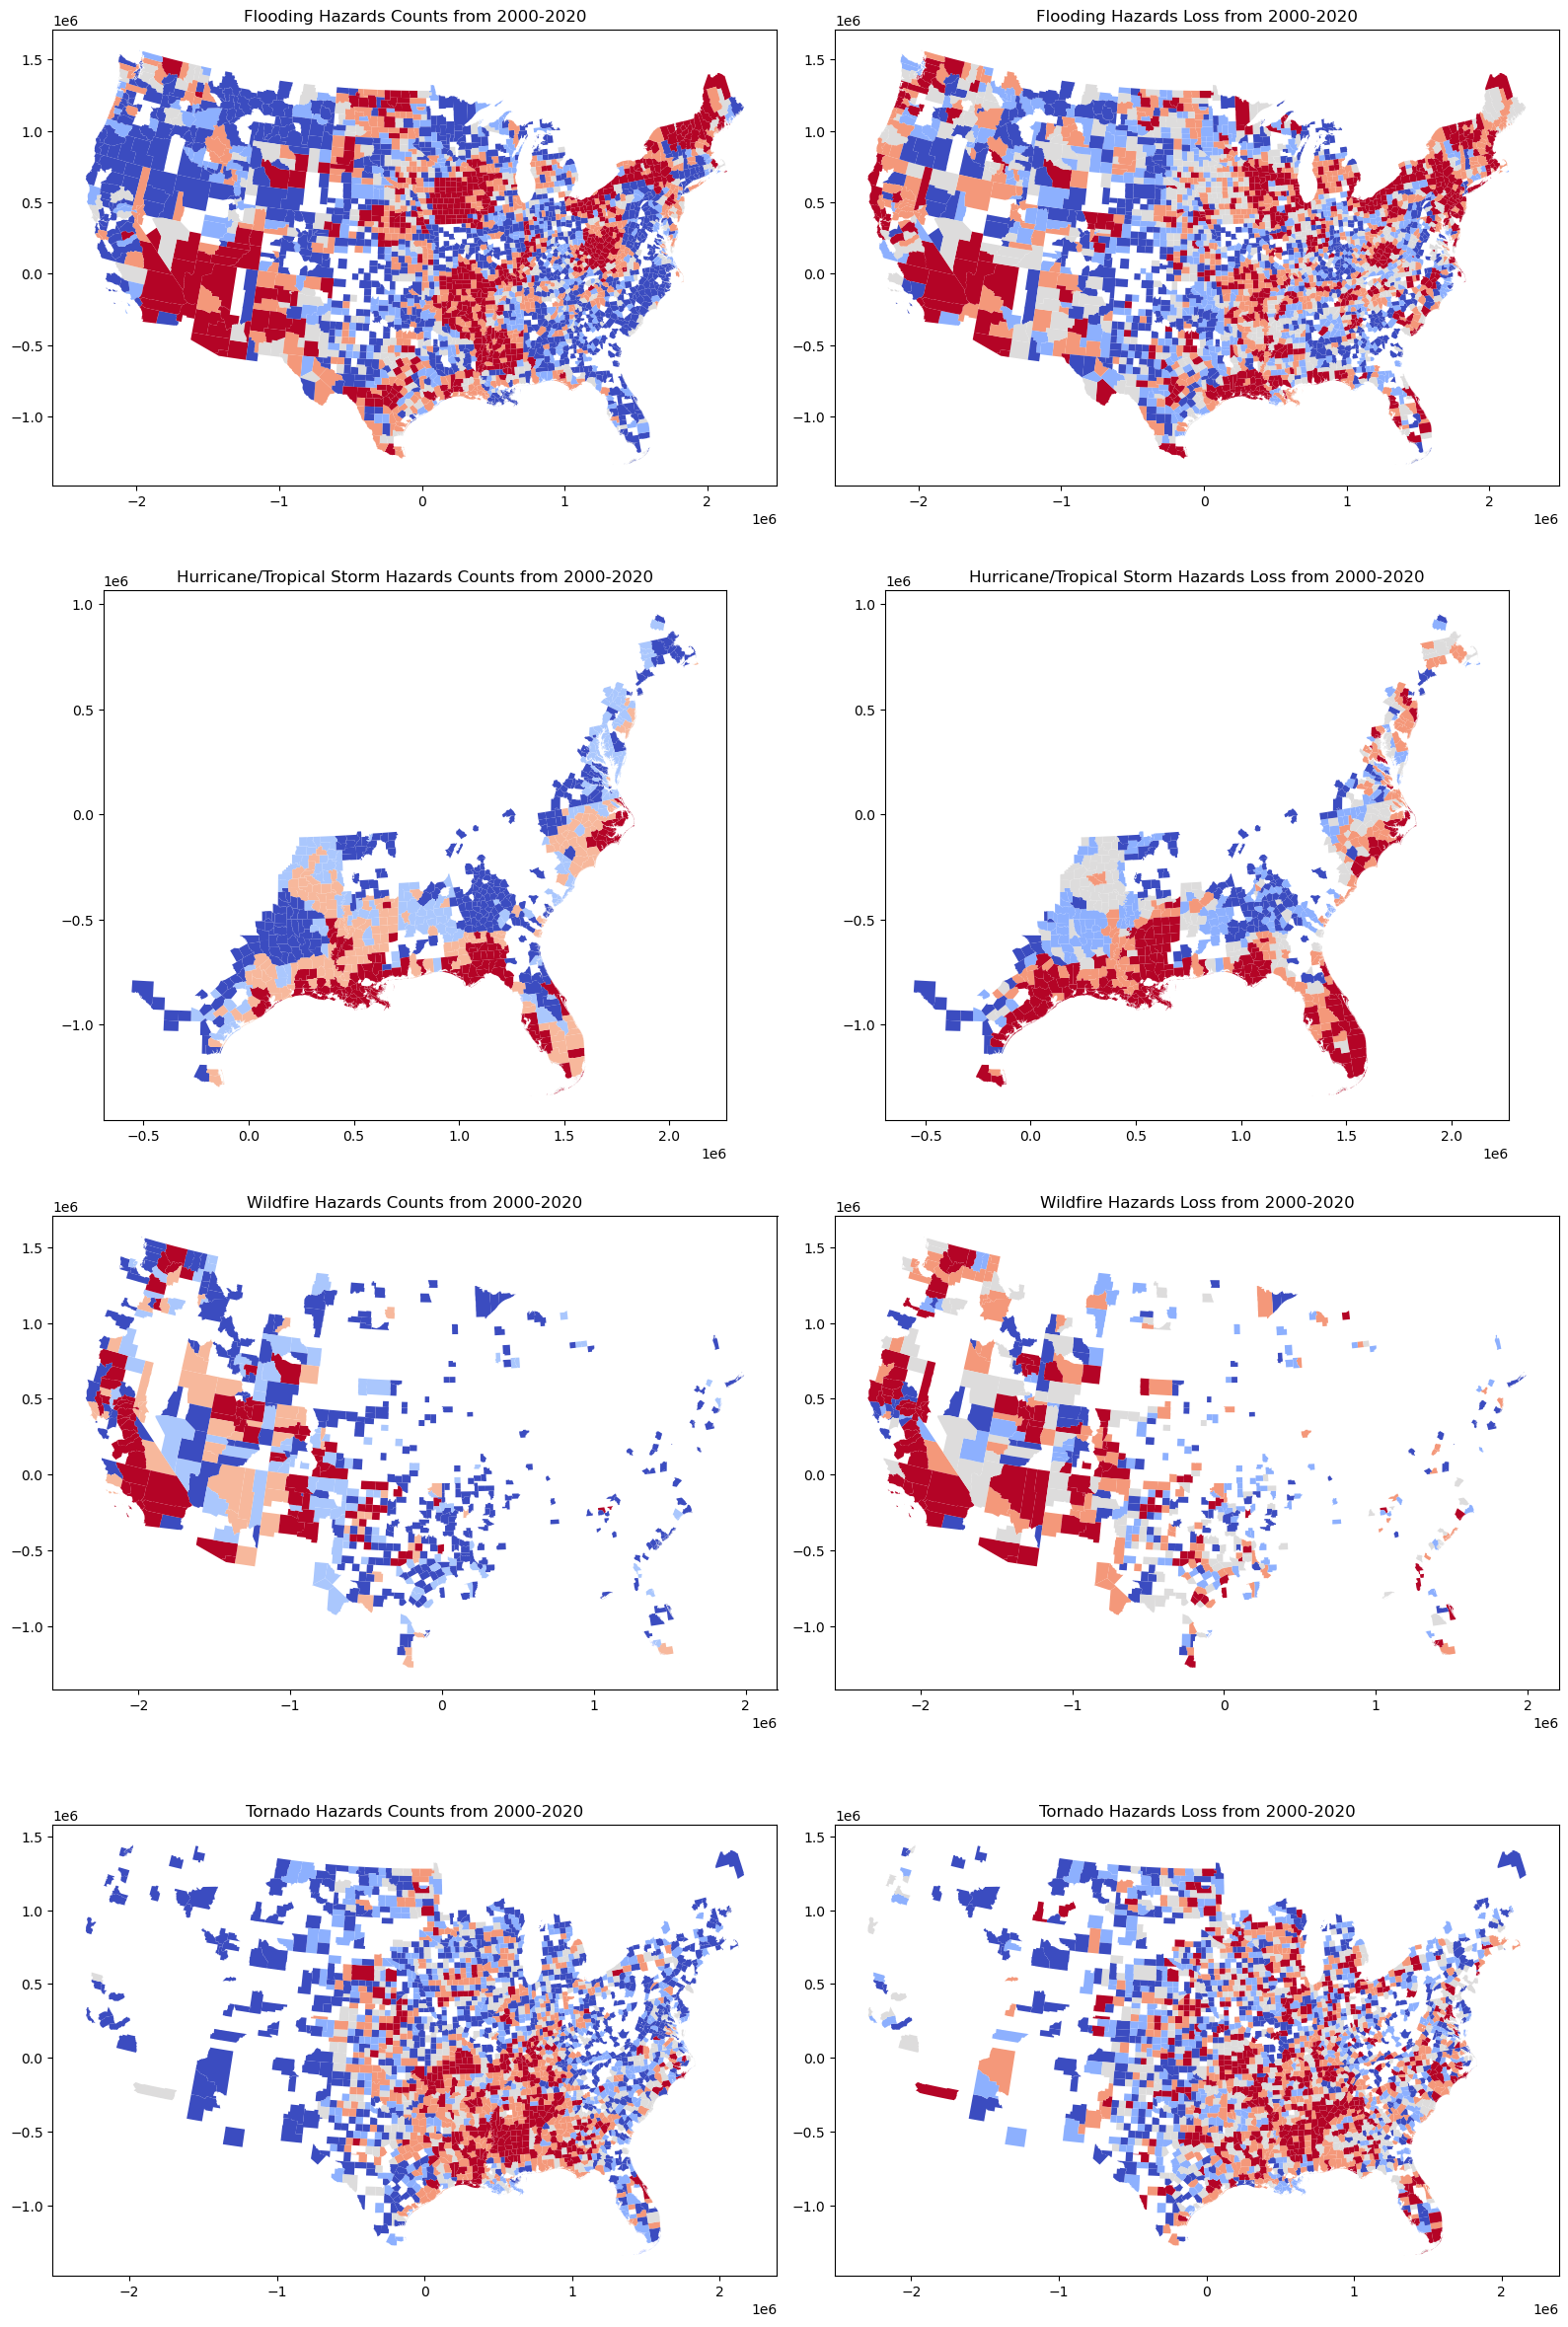

In [81]:
fig, axes = plt.subplots(4,2,figsize=(16,24))
list_disaster = ['Flooding','Hurricane/Tropical Storm','Wildfire','Tornado']
for i in range(4):
    use_df_disaster = gdf_disaster[gdf_disaster["Hazard"] == str(list_disaster[i])]
#     print(use_df_disaster.head())
    use_df_disaster.plot(column="frequency",cmap="coolwarm",scheme='quantiles',
#                          classification_kwds={'bins':[1,3,5,10,20,50]},
                         ax=axes[i,0])
    use_df_disaster.plot(column="PropertyDmg(ADJ 2020)",cmap="coolwarm",scheme="quantiles",
#                          ,legend=True,
                         ax=axes[i,1])
    axes[i,0].set_title(f"{list_disaster[i]} Hazards Counts from 2000-2020")
    axes[i,1].set_title(f"{list_disaster[i]} Hazards Loss from 2000-2020")
plt.tight_layout()
plt.show()

## XGBoost
### Combine each dataset

In [82]:
Regression_data = pd.DataFrame()
Regression_data = df_pep_0120
Regression_data = pd.merge(Regression_data,Disaster,left_on="FIPS",right_on="County FIPS",how="outer")
Regression_data = pd.merge(Regression_data,HAI,left_on="FIPS",right_on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,Hurricane,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Wildfire,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Tornado,left_on="FIPS",right_on="County FIPS",how="outer")
# Regression_data = pd.merge(Regression_data,Heat,left_on="FIPS",right_on="County FIPS",how="outer")
Regression_data = pd.merge(Regression_data,SVI_10,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,NRI_CONUS,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,unemployment_rate_pivot,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,PopDensity_CONUS_sel,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,conus_annual_prices,on="FIPS",how="inner")
# Regression_data = pd.merge(Regression_data,GDP_final_data,on="FIPS",how="inner")
Regression_data = pd.merge(Regression_data,T_sel,on="FIPS",how="inner")

In [83]:
Regression_data = Regression_data.fillna(0)

In [84]:
used_list = [
    "FIPS","NetMigrationRateTotal",#PEP
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
#     "Heat_Frequency","Heat_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "ratio_HP",#House Price
    'TJAN', 'TJULY' #Amenity
]
standard_list = [
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
#     "Heat_Frequency","Heat_Loss",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","P_SNGPRNT",
    "P_MINORITY","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "ratio_HP",#House Price
    'TJAN', 'TJULY']

name_list = [
    "FIPS","NMR",
    "Flood_Frequency","Flood_Loss",
    "Hurricane_Frequency","Hurricane_Loss",
    "Wildfire_Frequency","Wildfire_Loss",
    "Tornado_Frequency","Tornado_Loss",
#     "Heat_Frequency","Heat_Loss",
    "%BelowPoverty","%Unemployed","PerCapitaIncome","%NoHighSchoolDiploma25+","%Age65+",
    "%Age18-","%Single-parent household","%Minority","%Age5+LessThanWellEnglish",
    "%Multi-Unit House","%MobileHome","%HousePop>Room","%NoVehicleHousehold","%GroupQuarters",
    "Pop Density",
    "HouseUnaffordability",
    "%Change of House Price",
    "Jan Temp","July Temp"
]

In [85]:
from sklearn.preprocessing import RobustScaler
Regression_data_used = Regression_data[used_list]
scaler = RobustScaler()
Regression_data_used[standard_list] = scaler.fit_transform(Regression_data_used[standard_list])
Regression_data_used.columns = name_list

C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\3681464180.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Regression_data_used[standard_list] = scaler.fit_transform(Regression_data_used[standard_list])


In [86]:
# Regression_data_used = Regression_data[used_list]
# Regression_data_used[zscore_list] = (Regression_data_used[zscore_list] - Regression_data_used[zscore_list].mean()) / Regression_data_used[zscore_list].std()
# Regression_data_used.columns = name_list

### XGBOOST with all factors in Hurricane, Flood, Wildfire, Tornado

## Test for the best parameters

In [87]:
X = Regression_data_used.drop(columns=['NMR', 'FIPS',"%Single-parent household","%Minority"])
y = Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(xgb.XGBRegressor(objective="reg:squarederror"), param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}


## Summary Plot of XGBoost

Mean Squared Error: 21.279218125518156


 99%|===================| 754/763 [00:29<00:00]        

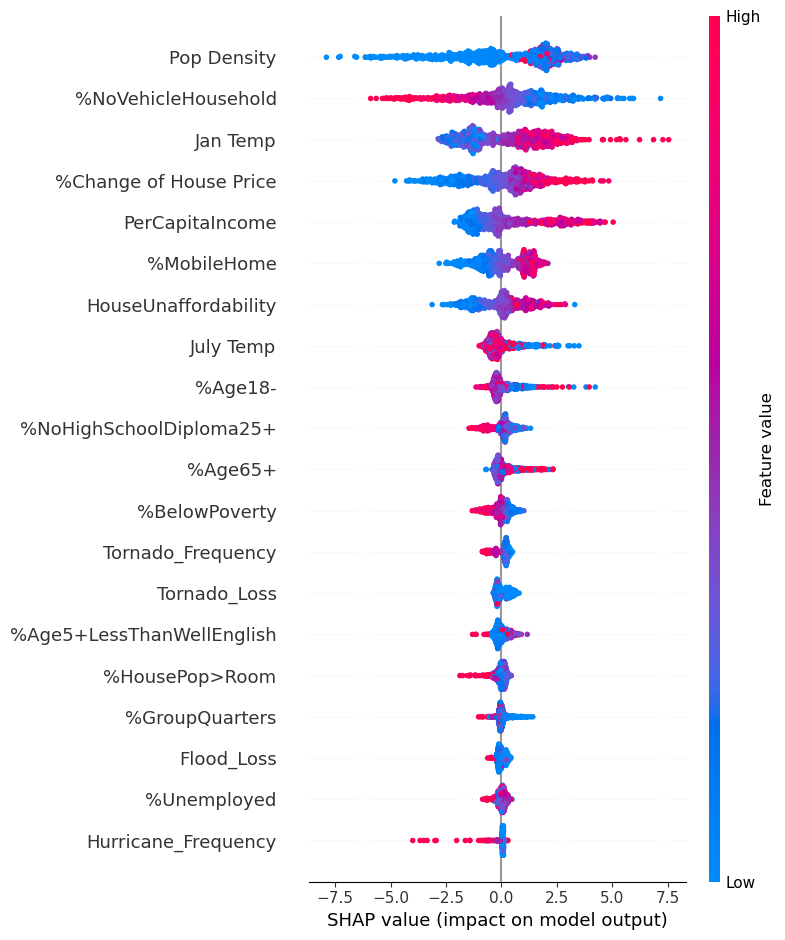

In [88]:
X = Regression_data_used.drop(columns=['NMR', 'FIPS',"%Single-parent household","%Minority"])
y = Regression_data_used['NMR']

# # Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Train an XGBoost regression model
model = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=1000,  
    learning_rate=0.01,
    max_depth=6,  
    subsample=0.8,  
    colsample_bytree=0.8,
    reg_lambda=1,  
    reg_alpha=0,  
    missing=0)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
# plt.savefig(r'F:\LongMig2025\results\maps\xgboost\summary.png', dpi=600, bbox_inches='tight')
fig.clf()

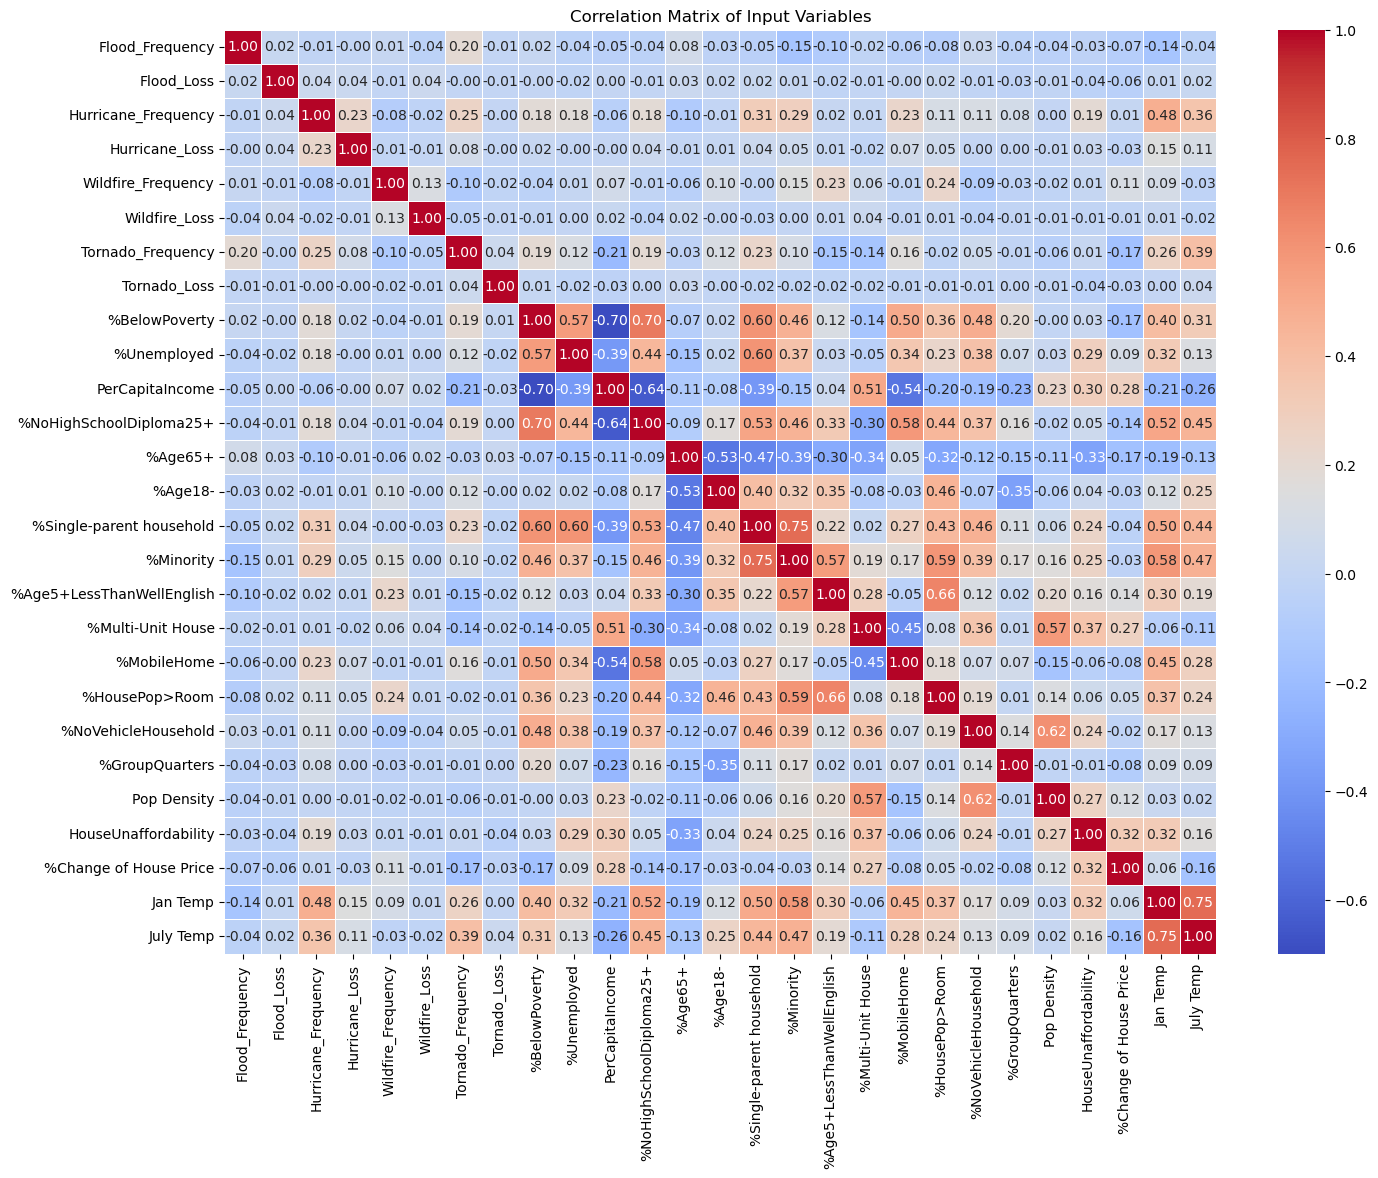

In [89]:
correlation_matrix = Regression_data_used.drop(columns=['NMR', 'FIPS']).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Input Variables")
plt.show()

## VIF to exclude some factors

In [90]:
# Exclude specified columns
excluded_columns = ["NMR", "FIPS"]
df_vif = Regression_data_used.drop(columns=excluded_columns, errors="ignore")

# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.207099
1,Flood_Loss,1.040743
2,Hurricane_Frequency,1.614205
3,Hurricane_Loss,1.079431
4,Wildfire_Frequency,1.255070
5,Wildfire_Loss,1.039103
6,Tornado_Frequency,1.402079
7,Tornado_Loss,1.010598
8,%BelowPoverty,4.218834
9,%Unemployed,2.315385


## VIF again

In [91]:
excluded_columns = ["NMR", "FIPS","%Single-parent household","%Minority"]
df_vif = Regression_data_used.drop(columns=excluded_columns, errors="ignore")

# Recalculate VIF for remaining variables
vif_data_filtered = pd.DataFrame()
vif_data_filtered["Feature"] = df_vif.columns
vif_data_filtered["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data_filtered

,Feature,VIF
0,Flood_Frequency,1.191182
1,Flood_Loss,1.037683
2,Hurricane_Frequency,1.572863
3,Hurricane_Loss,1.077974
4,Wildfire_Frequency,1.239709
5,Wildfire_Loss,1.038726
6,Tornado_Frequency,1.400246
7,Tornado_Loss,1.009989
8,%BelowPoverty,3.997572
9,%Unemployed,1.931432


In [92]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 21.279218125518156
RMSE: 4.612940290695096
R2: 0.6745983492169711


## F-value plot

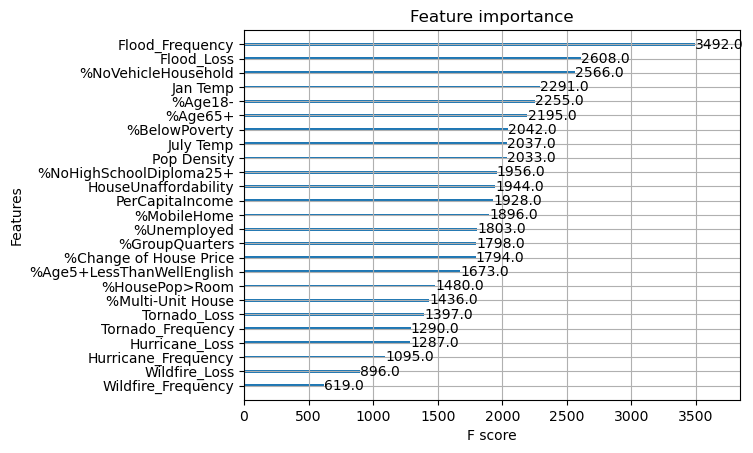

In [93]:
xgb.plot_importance(model)
plt.show()

## Cross Validation to test the stability

In [94]:
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation R^2 Scores:", scores)
print("Mean R^2:", scores.mean())

Cross-Validation R^2 Scores: [0.55163084 0.45388501 0.55656608 0.55393955 0.57543237]
Mean R^2: 0.5382907711084212


## Dependence Plot of XGBoost

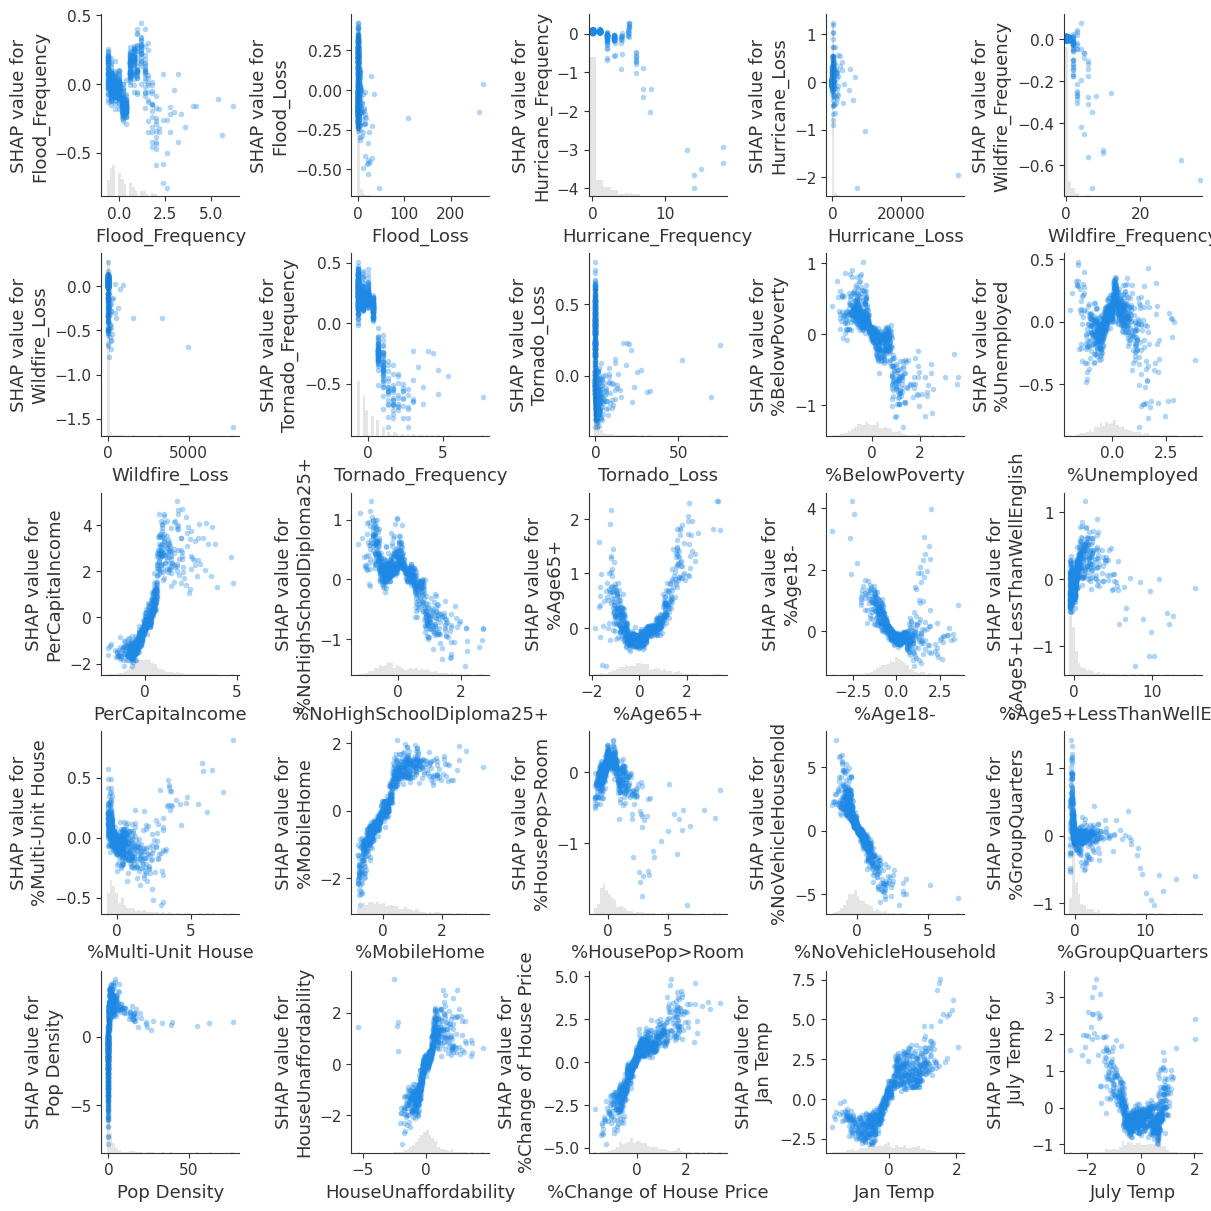

In [95]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     sns.regplot(x=X_test[feature], y=shap_values[:, feature], ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")
plt.savefig(r'F:\LongMig2025\results\maps\xgboost\dependence.png', dpi=600, bbox_inches='tight')  # Specify the path and file name here

# Show the final figure
plt.show()


## Lasso test. The use of Lasso test is similar as VIF.

In [96]:
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

Lasso(alpha=0.01)

In [97]:
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
lasso_coef = lasso_coef.sort_values(key=abs, ascending=False)
print(lasso_coef)

Jan Temp                     4.451718
%Change of House Price       2.482465
%NoVehicleHousehold         -2.477294
%MobileHome                  1.652618
HouseUnaffordability         1.531772
%BelowPoverty               -1.458303
%NoHighSchoolDiploma25+     -1.036185
July Temp                   -0.937276
%Multi-Unit House            0.604387
PerCapitaIncome              0.574919
%Age5+LessThanWellEnglish   -0.520816
%Age65+                     -0.514665
%Age18-                     -0.404998
Hurricane_Frequency         -0.394734
Tornado_Frequency           -0.314053
%Unemployed                  0.281194
%GroupQuarters              -0.122389
Wildfire_Frequency          -0.080113
Flood_Frequency             -0.063157
Pop Density                  0.036371
%HousePop>Room              -0.021093
Flood_Loss                  -0.019782
Tornado_Loss                -0.010203
Wildfire_Loss               -0.000417
Hurricane_Loss              -0.000205
dtype: float64


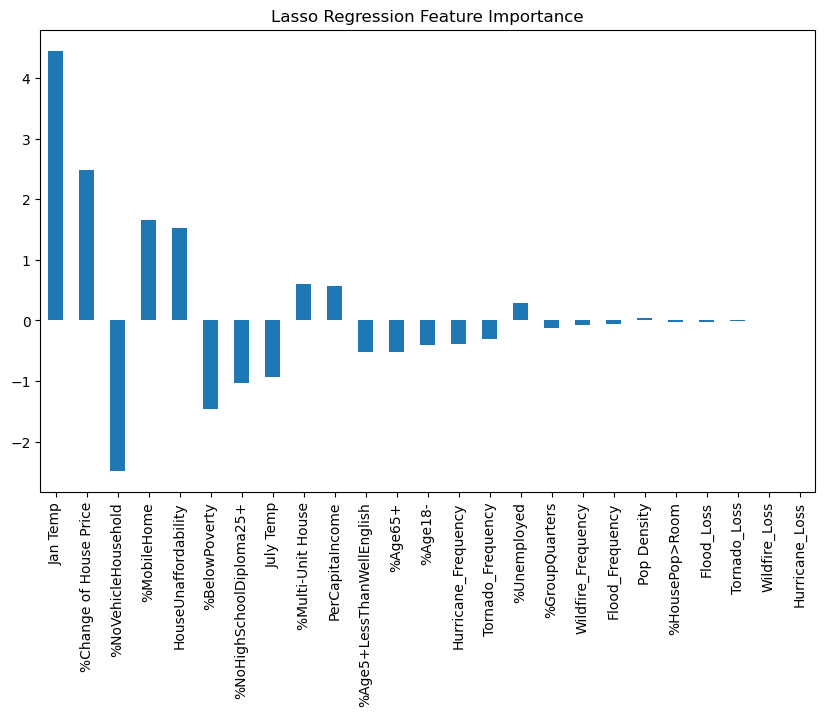

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
lasso_coef.plot(kind="bar")
plt.title("Lasso Regression Feature Importance")
plt.show()

## Summary Plot of XGBoost for Disaster Variables Only

 XGBoost R² Score: -0.1063
Mean Squared Error: 72.34638317715012


 97%|=================== | 738/763 [00:16<00:00]       

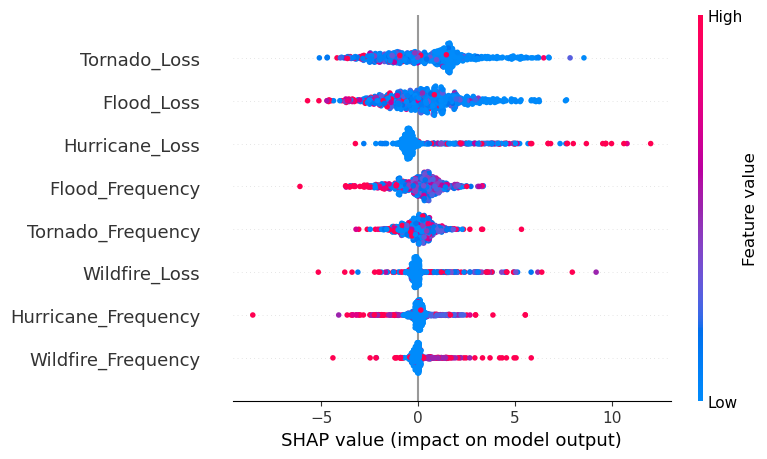

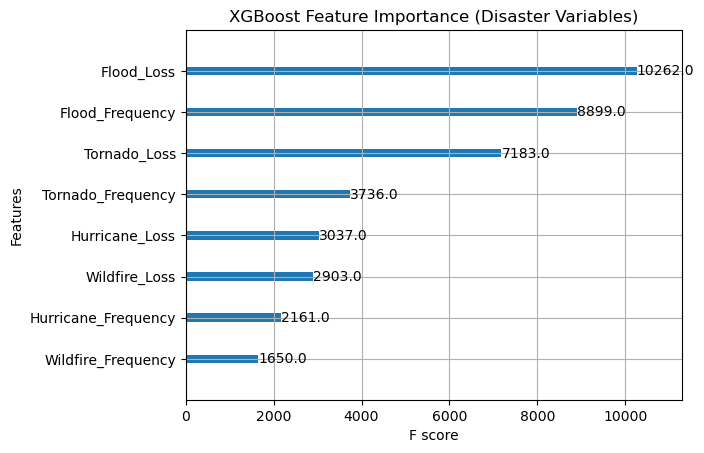

In [99]:
y = Regression_data_used['NMR']
disaster_vars = [col for col in Regression_data_used.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]
X_disaster = Regression_data_used[disaster_vars]

# XGBoost
X_train, X_test, y_train, y_test = train_test_split(X_disaster, y, test_size=0.25, random_state=42)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
xgb_r2 = r2_score(y_test, y_pred)
print(f" XGBoost R² Score: {xgb_r2:.4f}")

# Evaluate the model
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Explain the model with SHAP
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

# Summary plot of feature importance
shap.summary_plot(shap_values, X_test)

xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance (Disaster Variables)")
plt.show()

In [100]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 72.34638317715012
RMSE: 8.505667709072
R2: -0.10632037207208023


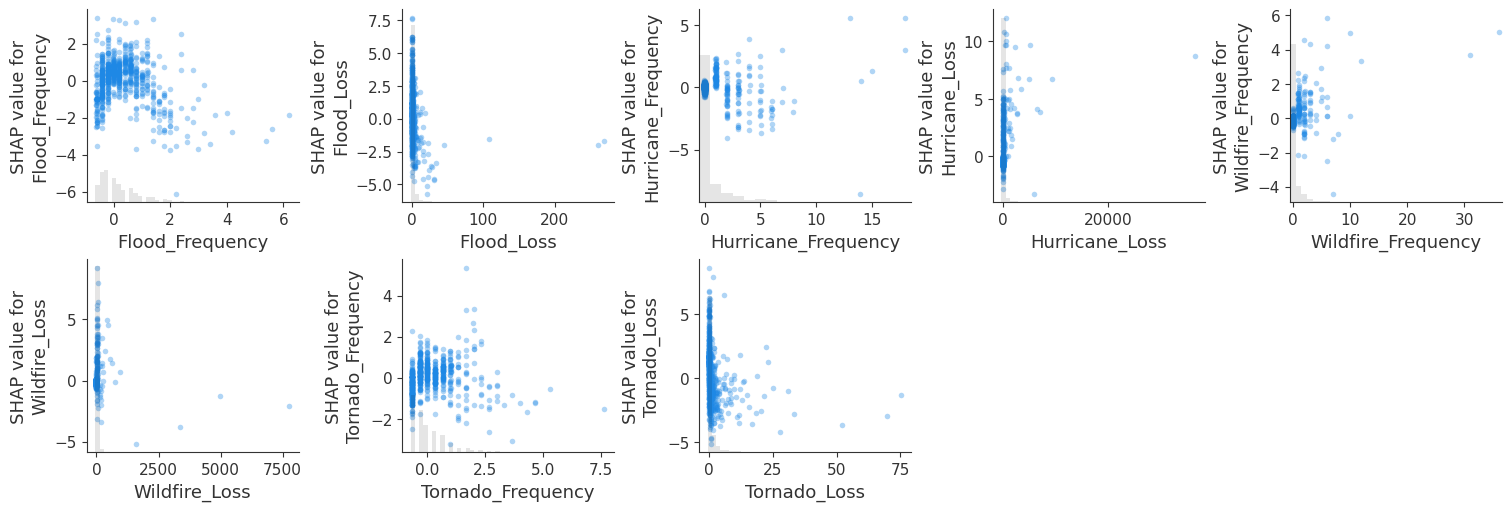

In [101]:
# Define all the features in your dataset
all_features = X_test.columns  # Replace with the features from your test set

# Set up the number of rows and columns for subplots
num_features = len(all_features)
cols = 5  # Number of columns in the subplot grid
rows = (num_features + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Generate SHAP dependence plots for each feature
for i, feature in enumerate(all_features):
    shap.plots.scatter(shap_values[:, feature],ax=axes[i], show=False, alpha=0.35)
#     shap.dependence_plot(
#         feature, shap_values.values, X_test, ax=axes[i], show=False
#     )
#     axes[i].set_title(f"SHAP Dependence for {feature}", fontsize=10)
    

# Turn off unused subplots if the number of features is less than total subplots
for j in range(len(all_features), len(axes)):
    axes[j].axis("off")

# Show the final figure
plt.show()


## Hierarchical Regression
## Hierarchical Regression of All Variables

In [102]:
Regression_data_used_ols = Regression_data_used.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (All Variables)")
print(model_ols.summary())

# 2 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF")
print(vif_data)

# OLS (Removed)
high_vif_features = vif_data[vif_data["VIF"] > 5]["Feature"].tolist()
X_filtered = X.drop(columns=high_vif_features)  
X_filtered = sm.add_constant(X_filtered)  

model_ols_filtered = sm.OLS(y, X_filtered).fit()
print("\nOLS（No Collinear Variables）：")
print(model_ols_filtered.summary())

OLS (All Variables)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     92.09
Date:                Fri, 18 Apr 2025   Prob (F-statistic):               0.00
Time:                        03:52:16   Log-Likelihood:                -9840.4
No. Observations:                3052   AIC:                         1.974e+04
Df Residuals:                    3024   BIC:                         1.991e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
co

In [103]:
X_ols = sm.add_constant(X_disaster)
model_ols = sm.OLS(y, X_ols).fit()
print("OLS Regression（Only Disaster Variables）：")
print(model_ols.summary())

OLS Regression（Only Disaster Variables）：
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     11.56
Date:                Fri, 18 Apr 2025   Prob (F-statistic):           2.67e-16
Time:                        03:52:16   Log-Likelihood:                -10710.
No. Observations:                3052   AIC:                         2.144e+04
Df Residuals:                    3043   BIC:                         2.149e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [104]:
used_list1 = [
    "FIPS","NetMigrationRateTotal",#PEP
    "Flood_Frequency","Flood_Loss","Flood_Fatalities","Flood_Injuries",
    "Hurricane_Frequency","Hurricane_Loss","Hurricane_Fatalities","Hurricane_Injuries",
    "Wildfire_Frequency","Wildfire_Loss","Wildfire_Fatalities","Wildfire_Injuries",
    "Tornado_Frequency","Tornado_Loss","Tornado_Fatalities","Tornado_Injuries",
#     "Heat_Frequency","Heat_Loss","Heat_Fatalities","Heat_Injuries",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17",
    "E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "ratio_HP",#House Price
    'TJAN', 'TJULY' #Amenity
]
standard_list1 = [
    "Flood_Frequency","Flood_Loss","Flood_Fatalities","Flood_Injuries",
    "Hurricane_Frequency","Hurricane_Loss","Hurricane_Fatalities","Hurricane_Injuries",
    "Wildfire_Frequency","Wildfire_Loss","Wildfire_Fatalities","Wildfire_Injuries",
    "Tornado_Frequency","Tornado_Loss","Tornado_Fatalities","Tornado_Injuries",
#     "Heat_Frequency","Heat_Loss","Heat_Fatalities","Heat_Injuries",
    "E_P_POV","E_P_UNEMP","E_P_PCI","E_P_NOHSDIP","P_AGE65","P_AGE17","E_P_LIMENG","E_P_MUNIT","E_P_MOBILE","E_P_CROWD","E_P_NOVEH","P_GROUPQ", #SVI
    "POPDENS10",#POP DENSITY
    "W_HT_HAI",#HAI
    "ratio_HP",#House Price
    'TJAN', 'TJULY']

name_list1 = [
    "FIPS","NMR",
    "Flood_Frequency","Flood_Loss","Flood_Fatalities","Flood_Injuries",
    "Hurricane_Frequency","Hurricane_Loss","Hurricane_Fatalities","Hurricane_Injuries",
    "Wildfire_Frequency","Wildfire_Loss","Wildfire_Fatalities","Wildfire_Injuries",
    "Tornado_Frequency","Tornado_Loss","Tornado_Fatalities","Tornado_Injuries",
#     "Heat_Frequency","Heat_Loss","Heat_Fatalities","Heat_Injuries",
    "%BelowPoverty","%Unemployed","PerCapitaIncome","%NoHighSchoolDiploma25+","%Age65+",
    "%Age18-","%Age5+LessThanWellEnglish",
    "%Multi-Unit House","%MobileHome","%HousePop>Room","%NoVehicleHousehold","%GroupQuarters",
    "Pop Density",
    "Affordability",
    "%Change of House Price",
    "Jan Temp","July Temp"
]

In [105]:
Regression_data_used1 = Regression_data[used_list1]
scaler = StandardScaler()
Regression_data_used1[standard_list1] = scaler.fit_transform(Regression_data_used1[standard_list1])
Regression_data_used1.columns = name_list1

C:\Users\xiang11\AppData\Local\Temp\ipykernel_29308\2935102092.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Regression_data_used1[standard_list1] = scaler.fit_transform(Regression_data_used1[standard_list1])


In [106]:
Regression_data_used1.head()

,FIPS,NMR,Flood_Frequency,Flood_Loss,Flood_Fatalities,Flood_Injuries,Hurricane_Frequency,Hurricane_Loss,Hurricane_Fatalities,Hurricane_Injuries,...,%Multi-Unit House,%MobileHome,%HousePop>Room,%NoVehicleHousehold,%GroupQuarters,Pop Density,Affordability,%Change of House Price,Jan Temp,July Temp
0,01001,5.813354,0.160435,-0.199271,-0.306448,-0.115550,0.702938,-0.088193,-0.03564,-0.032324,...,-0.458350,0.881678,-0.478487,-0.236761,-0.604390,-0.096631,0.751353,-0.154784,1.168664,0.949426
1,01003,22.393108,0.396523,-0.164445,0.909898,0.140556,1.781012,-0.080239,-0.03564,-0.032324,...,1.982691,0.108183,-0.076845,-0.807435,-0.499808,-0.083535,0.436385,0.967559,1.546954,1.092091
2,01005,-7.284080,-0.547829,-0.209587,-0.306448,-0.115550,0.702938,-0.089199,-0.03564,-0.032324,...,-0.591969,1.808857,-0.122490,1.249173,1.962634,-0.131552,0.457310,-0.871142,1.286873,0.959401
3,01007,1.336304,-0.783918,-0.186579,-0.306448,-0.115550,0.702938,-0.085789,-0.03564,-0.032324,...,-0.484669,1.810641,-0.543124,-0.224507,1.506274,-0.128221,-0.408065,-0.631814,1.029530,0.948255
4,01009,5.568893,-0.547829,-0.205256,-0.306448,-0.115550,0.163901,-0.089354,-0.03564,-0.032324,...,-0.693765,0.994135,0.370783,-0.776493,-0.599637,-0.098296,0.291211,0.487986,0.770589,0.604719


In [107]:
flooding_list
flooding_low_list
flooding_medhigh_list = list(set(flooding_list)-set(flooding_low_list))

hurricane_list
hurricane_low_list
hurricane_medhigh_list = list(set(hurricane_list)-set(hurricane_low_list))

wildfire_list
wildfire_low_list
wildfire_medhigh_list = list(set(wildfire_list)-set(wildfire_low_list))

tornado_list
tornado_low_list
tornado_medhigh_list = list(set(tornado_list)-set(tornado_low_list))


## Hierarchical Regression of Flood
## Six summary tables are:
### 1) Total counties with socio-economic variables only
### 2) Total counties with all variables (disaster+socio-economic)
### 3) Low impacted counties with socio-economic variables only
### 4) Low impacted counties with all variables (disaster+socio-economic)
### 5) Moderate and high impacted counties with socio-economic variables only
### 6) Moderate and high impacted counties with all variables (disaster+socio-economic)

In [108]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_flood = Regression_data_used1[Regression_data_used1["FIPS"].isin(flooding_list)]

Regression_data_used_ols = total_flood.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_flood.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_flood = Regression_data_used1[Regression_data_used1["FIPS"].isin(flooding_low_list)]

Regression_data_used_ols = low_flood.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_flood.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_flood = Regression_data_used1[Regression_data_used1["FIPS"].isin(flooding_medhigh_list)]

Regression_data_used_ols = high_flood.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_flood.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     113.9
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          1.76e-301
Time:                        03:52:16   Log-Likelihood:                -8828.1
No. Observations:                2729   AIC:                         1.769e+04
Df Residuals:                    2711   BIC:                         1.780e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------


## Hierarchical Regression of Hurricane

In [109]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_hurricane = Regression_data_used1[Regression_data_used1["FIPS"].isin(hurricane_list)]

Regression_data_used_ols = total_hurricane.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_hurricane.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_hurricane = Regression_data_used1[Regression_data_used1["FIPS"].isin(hurricane_low_list)]

Regression_data_used_ols = low_hurricane.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_hurricane.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_hurricane = Regression_data_used1[Regression_data_used1["FIPS"].isin(hurricane_medhigh_list)]

Regression_data_used_ols = high_hurricane.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_hurricane.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     43.18
Date:                Fri, 18 Apr 2025   Prob (F-statistic):           6.75e-97
Time:                        03:52:16   Log-Likelihood:                -2412.2
No. Observations:                 717   AIC:                             4860.
Df Residuals:                     699   BIC:                             4943.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------


## Hierarchical Regression of Wildfire

In [110]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Hurricane' in col or 'Tornado' in col or 'Flood' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_wildfire = Regression_data_used1[Regression_data_used1["FIPS"].isin(wildfire_list)]

Regression_data_used_ols = total_wildfire.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_wildfire.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_wildfire = Regression_data_used1[Regression_data_used1["FIPS"].isin(wildfire_low_list)]

Regression_data_used_ols = low_wildfire.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_wildfire.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_wildfire = Regression_data_used1[Regression_data_used1["FIPS"].isin(wildfire_medhigh_list)]

Regression_data_used_ols = high_wildfire.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_wildfire.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     27.73
Date:                Fri, 18 Apr 2025   Prob (F-statistic):           6.65e-62
Time:                        03:52:16   Log-Likelihood:                -1793.0
No. Observations:                 536   AIC:                             3622.
Df Residuals:                     518   BIC:                             3699.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------


## Hierarchical Regression of Tornado

In [111]:
disaster_vars = [col for col in Regression_data_used1.columns if 'Hurricane' in col or 'Flood' in col or 'Wildfire' in col or 'Heat' in col]
disaster_vars1 = [col for col in Regression_data_used1.columns if 'Flood' in col or 'Hurricane' in col or 'Tornado' in col or 'Wildfire' in col or 'Heat' in col]

total_tornado = Regression_data_used1[Regression_data_used1["FIPS"].isin(tornado_list)]

Regression_data_used_ols = total_tornado.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco)")
print(model_ols.summary())

Regression_data_used_ols = total_tornado.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables)")
print(model_ols.summary())

low_tornado = Regression_data_used1[Regression_data_used1["FIPS"].isin(tornado_low_list)]

Regression_data_used_ols = low_tornado.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco LOW)")
print(model_ols.summary())

Regression_data_used_ols = low_tornado.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables LOW)")
print(model_ols.summary())


high_tornado = Regression_data_used1[Regression_data_used1["FIPS"].isin(tornado_medhigh_list)]

Regression_data_used_ols = high_tornado.drop(columns=disaster_vars1)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total Socio-eco HIGH)")
print(model_ols.summary())

Regression_data_used_ols = high_tornado.drop(columns=disaster_vars)
Regression_data_used_ols = Regression_data_used_ols.drop(columns=['FIPS'])

y = Regression_data_used_ols['NMR']
X = Regression_data_used_ols.drop(columns=['NMR'])

# 1 OLS Regression
X_ols = sm.add_constant(X) 
model_ols = sm.OLS(y, X_ols).fit()
print("OLS (Total All Variables HIGH)")
print(model_ols.summary())

OLS (Total Socio-eco)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     117.5
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          9.84e-294
Time:                        03:52:16   Log-Likelihood:                -7208.5
No. Observations:                2236   AIC:                         1.445e+04
Df Residuals:                    2218   BIC:                         1.456e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------


OLS (Total All Variables HIGH)
                            OLS Regression Results                            
Dep. Variable:                    NMR   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     89.02
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          1.31e-264
Time:                        03:52:16   Log-Likelihood:                -6210.1
No. Observations:                1937   AIC:                         1.246e+04
Df Residuals:                    1915   BIC:                         1.259e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------